In [1]:
#basics
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

#sklearn
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
#from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
#from sklearn.preprocessing import PolynomialFeatures
#from sklearn import set_config
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.base import clone

# feature engine
from feature_engine.timeseries.forecasting import LagFeatures
from feature_engine.timeseries.forecasting import WindowFeatures
from feature_engine.timeseries.forecasting import ExpandingWindowFeatures
from feature_engine.datetime import DatetimeFeatures
from feature_engine.selection import DropFeatures
from feature_engine.imputation import DropMissingData


# sktime
from sktime.transformations.series.time_since import TimeSince


# statsmodels
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.tsa.stattools import pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import ccf
from statsmodels.tsa.seasonal import STL

In [2]:
import sys
sys.path.append("src")   # VERY IMPORTANT

In [3]:
# helper function imports & Class
from basic_helper_functions import seperate_target_plot
from basic_helper_functions import seperate_predictor_plot
from basic_helper_functions import plot_clean_plot

from Feature_Engineering import GOR_WCUT_Transformer
from Feature_Engineering import plot_ccf,lag_plot 
from Feature_Engineering import LassoSelectedLagFeatureAdder
from Feature_Engineering import TrendFeatureAdder
from Feature_Engineering import AddSelectedCalendarFourierFeatures
from Feature_Engineering import AddSpecificLag1Features



# Load data

In [7]:
# load the data
df = pd.read_csv('processed_inputs/df1.csv',index_col='DATEPRD', parse_dates=True)
#explicitly sets the time frequency of  DatetimeIndex to "Daily" (D).
df.asfreq('D')
# drop ,'GOR_MSCF/STB', 'WCUT. I calculated this before in my helper function. But i need to calculate as part of a pipeline. so i will need to drop it
df = df.drop(columns=['GOR_MSCF/STB', 'WCUT'])

In [8]:
# Split data

In [9]:
(df.columns,len(df.columns))

(Index(['WELL_BORE_CODE', 'NPD_WELL_BORE_CODE', 'NPD_WELL_BORE_NAME',
        'NPD_FIELD_CODE', 'NPD_FIELD_NAME', 'NPD_FACILITY_CODE',
        'NPD_FACILITY_NAME', 'ON_STREAM_HRS', 'AVG_CHOKE_SIZE_P',
        'AVG_CHOKE_UOM', 'FLOW_KIND', 'WELL_TYPE', 'AVG_DOWNHOLE_PRESSURE_PSI',
        'AVG_DOWNHOLE_TEMPERATURE_F', 'AVG_DP_TUBING_PSI',
        'AVG_ANNULUS_PRESS_PSI', 'DP_CHOKE_SIZE_PSI', 'AVG_WHP_P_PSI',
        'BORE_WI_VOL_STB_D', 'AVG_WHT_P', 'BORE_OIL_VOL_STB_D',
        'BORE_GAS_VOL_MSCF_D', 'BORE_WAT_VOL_STB_D'],
       dtype='object'),
 23)

In [10]:
#target_col=['BORE_OIL_VOL_STB_D', 'BORE_GAS_VOL_MSCF_D','BORE_WAT_VOL_STB_D']
#predictor_num_col=['ON_STREAM_HRS', 'AVG_CHOKE_SIZE_P',
       #'DP_CHOKE_SIZE_PSI',
      #'AVG_DOWNHOLE_PRESSURE_PSI', 'AVG_DOWNHOLE_TEMPERATURE_F',
       #'AVG_DP_TUBING_PSI', 'AVG_ANNULUS_PRESS_PSI', 'AVG_WHP_P_PSI',
       #'BORE_WI_VOL_STB_D', 'AVG_WHT_P']
#predictor_cat_cols=['FLOW_KIND', 'WELL_TYPE']
#starting_total_features=len(target_col)+len(predictor_num_col)+len(predictor_cat_cols)
#starting_total_features

# Preprocessing

In the preprocessing I am going to:
1. Remove all columns that have zeros or nan greater than 50% of the data
2. Make negative values zero
3. Then if any columns have nan, prints the column and the nan and then does linear interpolation

how many nans before cleaning
WELL_BORE_CODE                  0
NPD_WELL_BORE_CODE              0
NPD_WELL_BORE_NAME              0
NPD_FIELD_CODE                  0
NPD_FIELD_NAME                  0
NPD_FACILITY_CODE               0
NPD_FACILITY_NAME               0
ON_STREAM_HRS                   0
AVG_CHOKE_SIZE_P                0
AVG_CHOKE_UOM                   0
FLOW_KIND                       0
WELL_TYPE                       0
AVG_DOWNHOLE_PRESSURE_PSI       3
AVG_DOWNHOLE_TEMPERATURE_F      3
AVG_DP_TUBING_PSI               3
AVG_ANNULUS_PRESS_PSI         729
DP_CHOKE_SIZE_PSI               0
AVG_WHP_P_PSI                   0
BORE_WI_VOL_STB_D             746
AVG_WHT_P                       0
BORE_OIL_VOL_STB_D              0
BORE_GAS_VOL_MSCF_D             0
BORE_WAT_VOL_STB_D              0
dtype: int64
Plot before cleaning


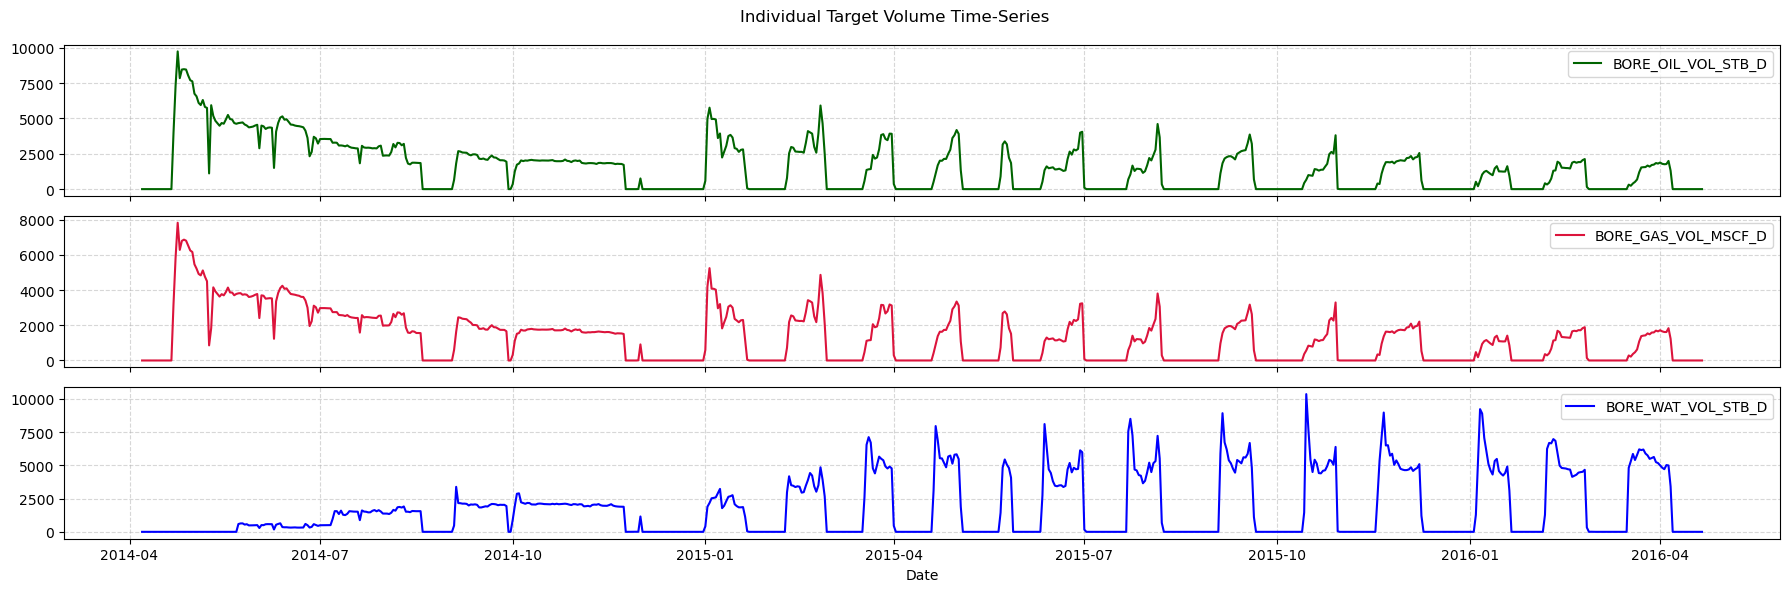

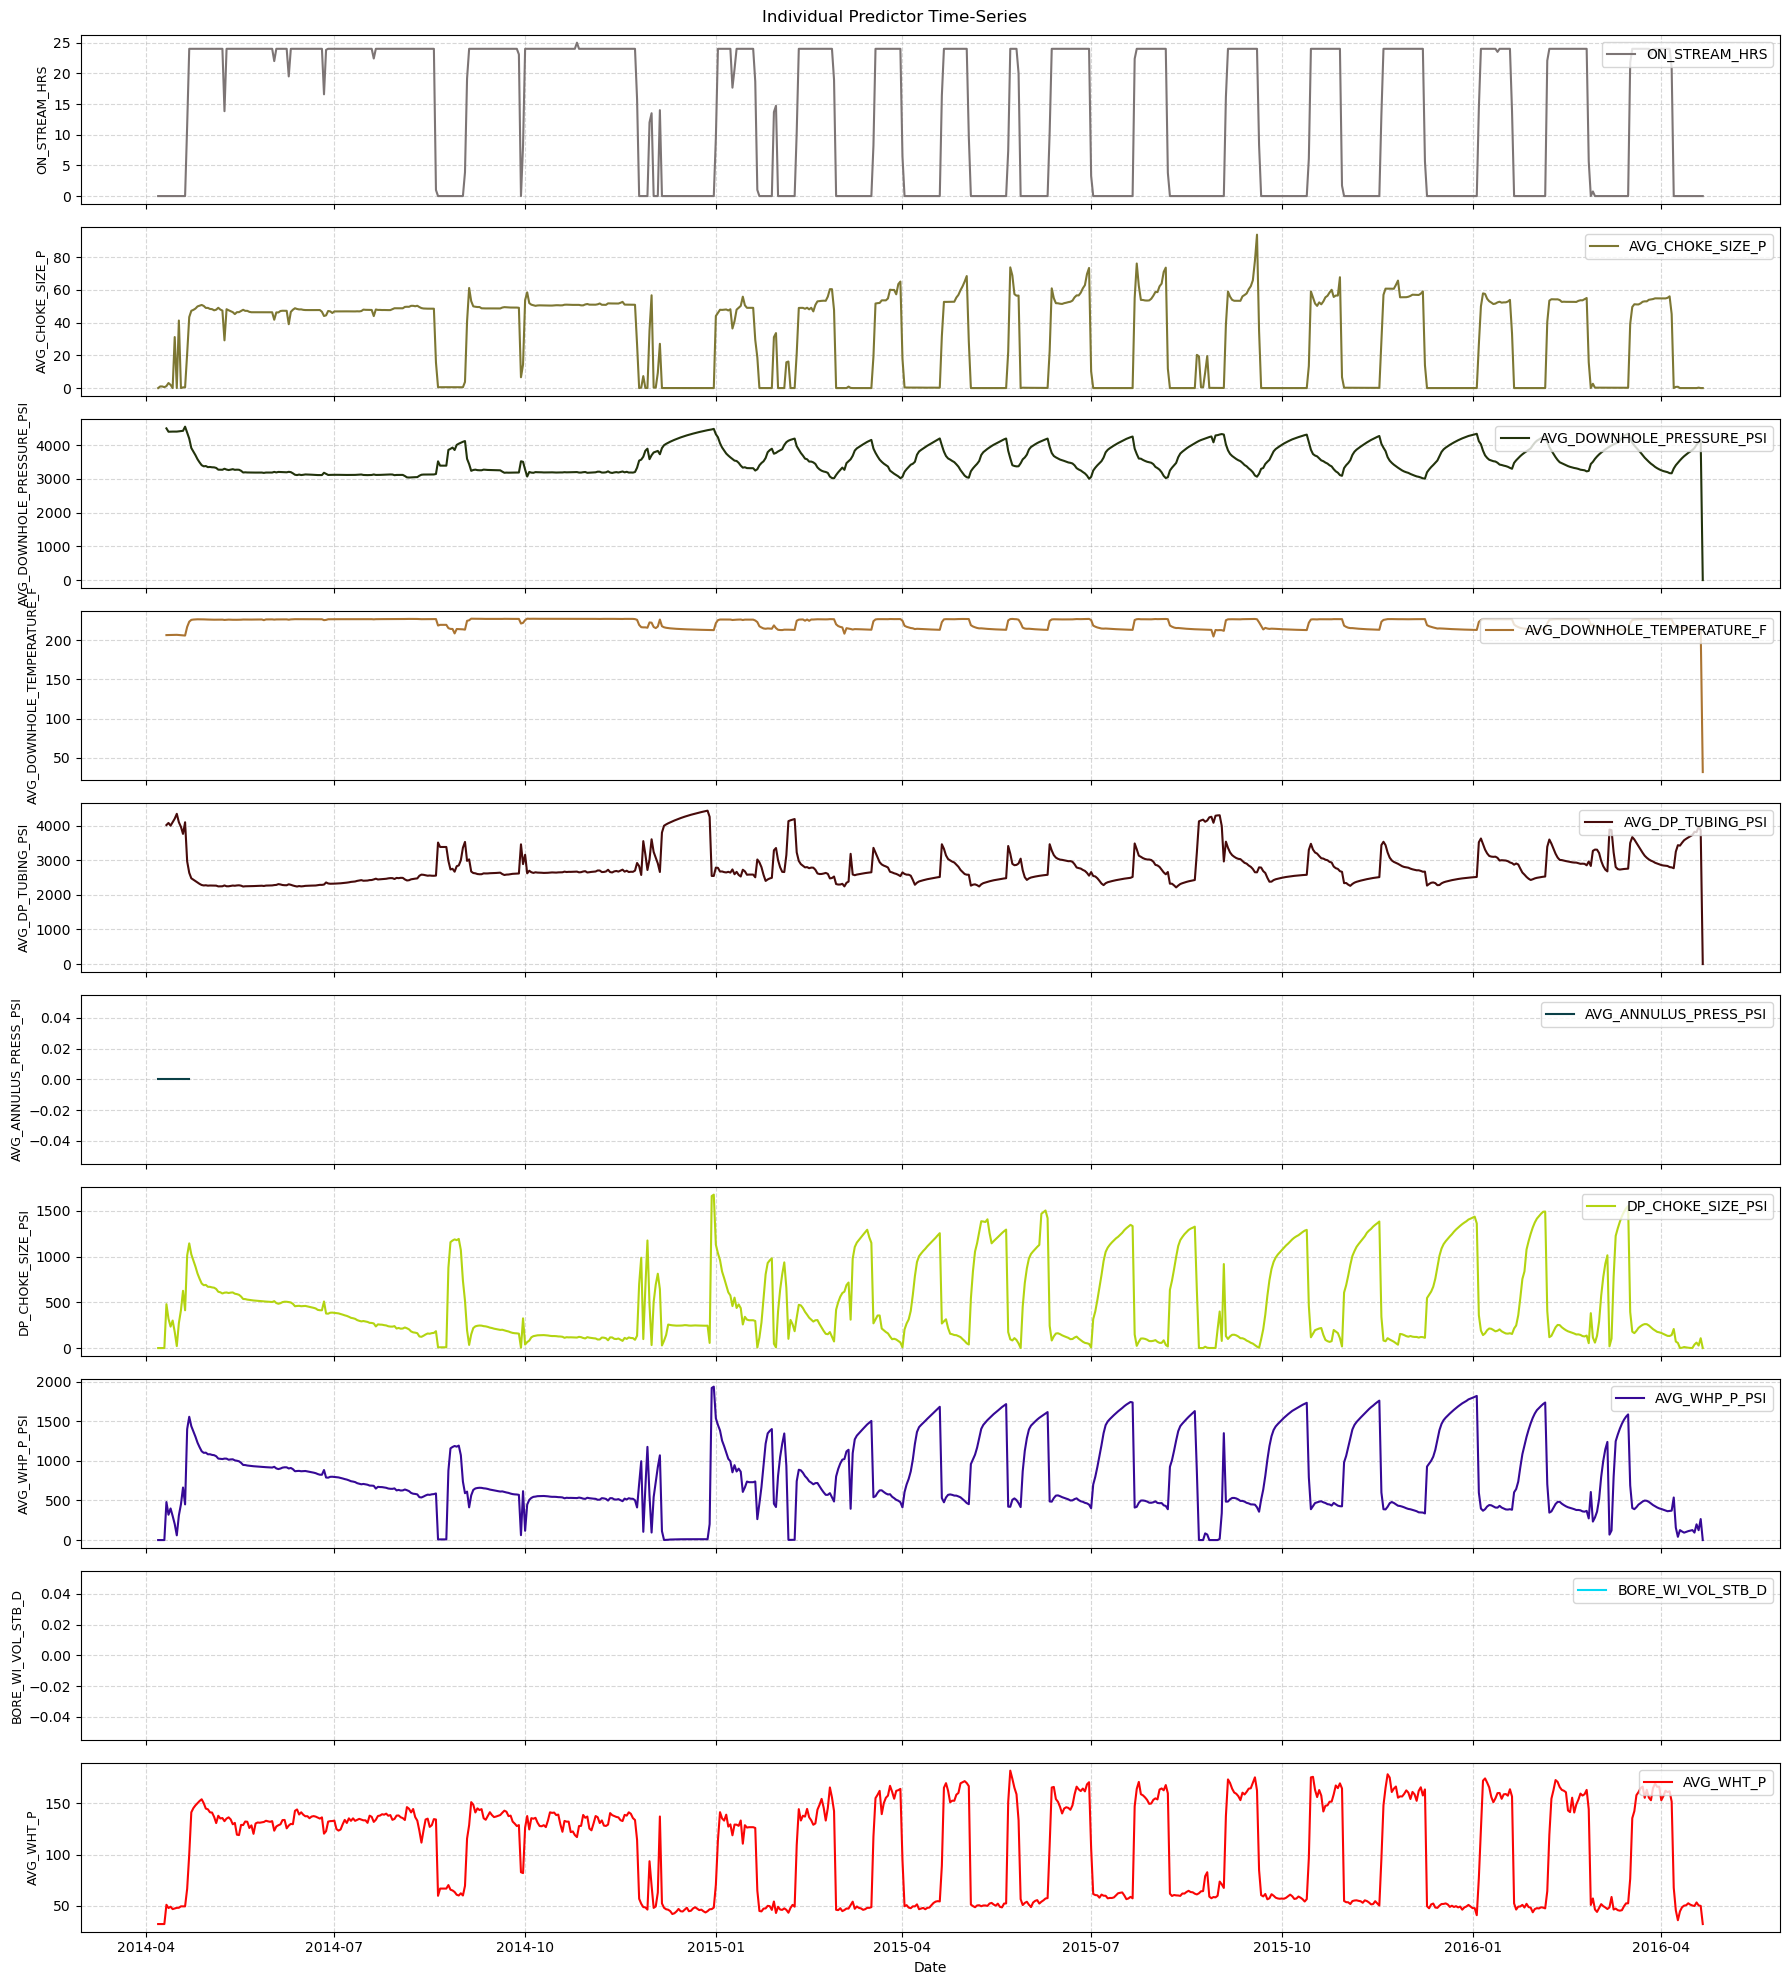

Cleaning data
The length of the dataframe before cleaning is 746
Deleted columns with nan greater than 50% of the total data: ['AVG_ANNULUS_PRESS_PSI', 'BORE_WI_VOL_STB_D']
Deleted columns with zero greater than 50% of the total data: []
Before cleaning, AVG_DOWNHOLE_PRESSURE_PSI has 3 NaNs
Before cleaning, AVG_DOWNHOLE_TEMPERATURE_F has 3 NaNs
Before cleaning, AVG_DP_TUBING_PSI has 3 NaNs
how many nans after cleaning
WELL_BORE_CODE                            0
NPD_WELL_BORE_CODE                        0
NPD_WELL_BORE_NAME                        0
NPD_FIELD_CODE                            0
NPD_FIELD_NAME                            0
NPD_FACILITY_CODE                         0
NPD_FACILITY_NAME                         0
ON_STREAM_HRS                             0
AVG_CHOKE_SIZE_P                          0
AVG_CHOKE_UOM                             0
FLOW_KIND                                 0
WELL_TYPE                                 0
AVG_DOWNHOLE_PRESSURE_PSI                 0
AVG_DO

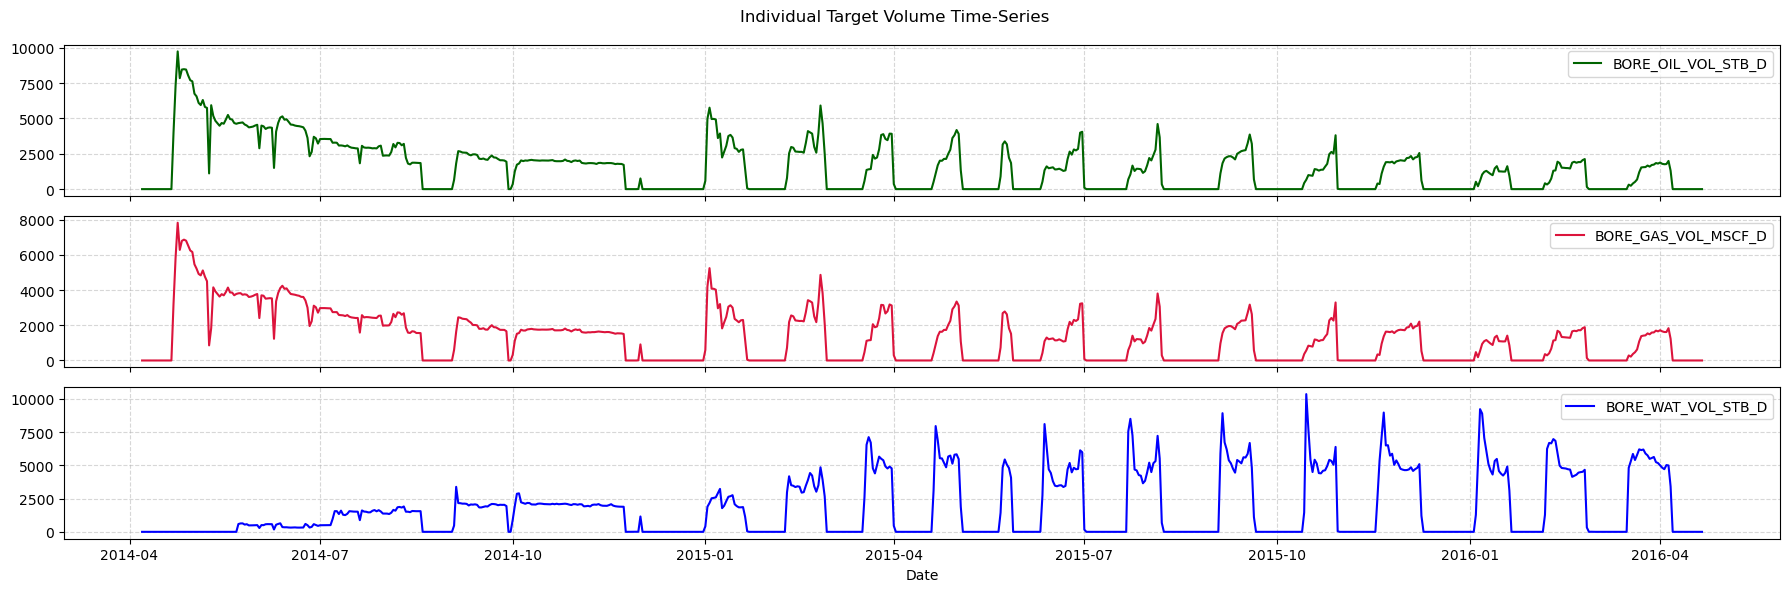

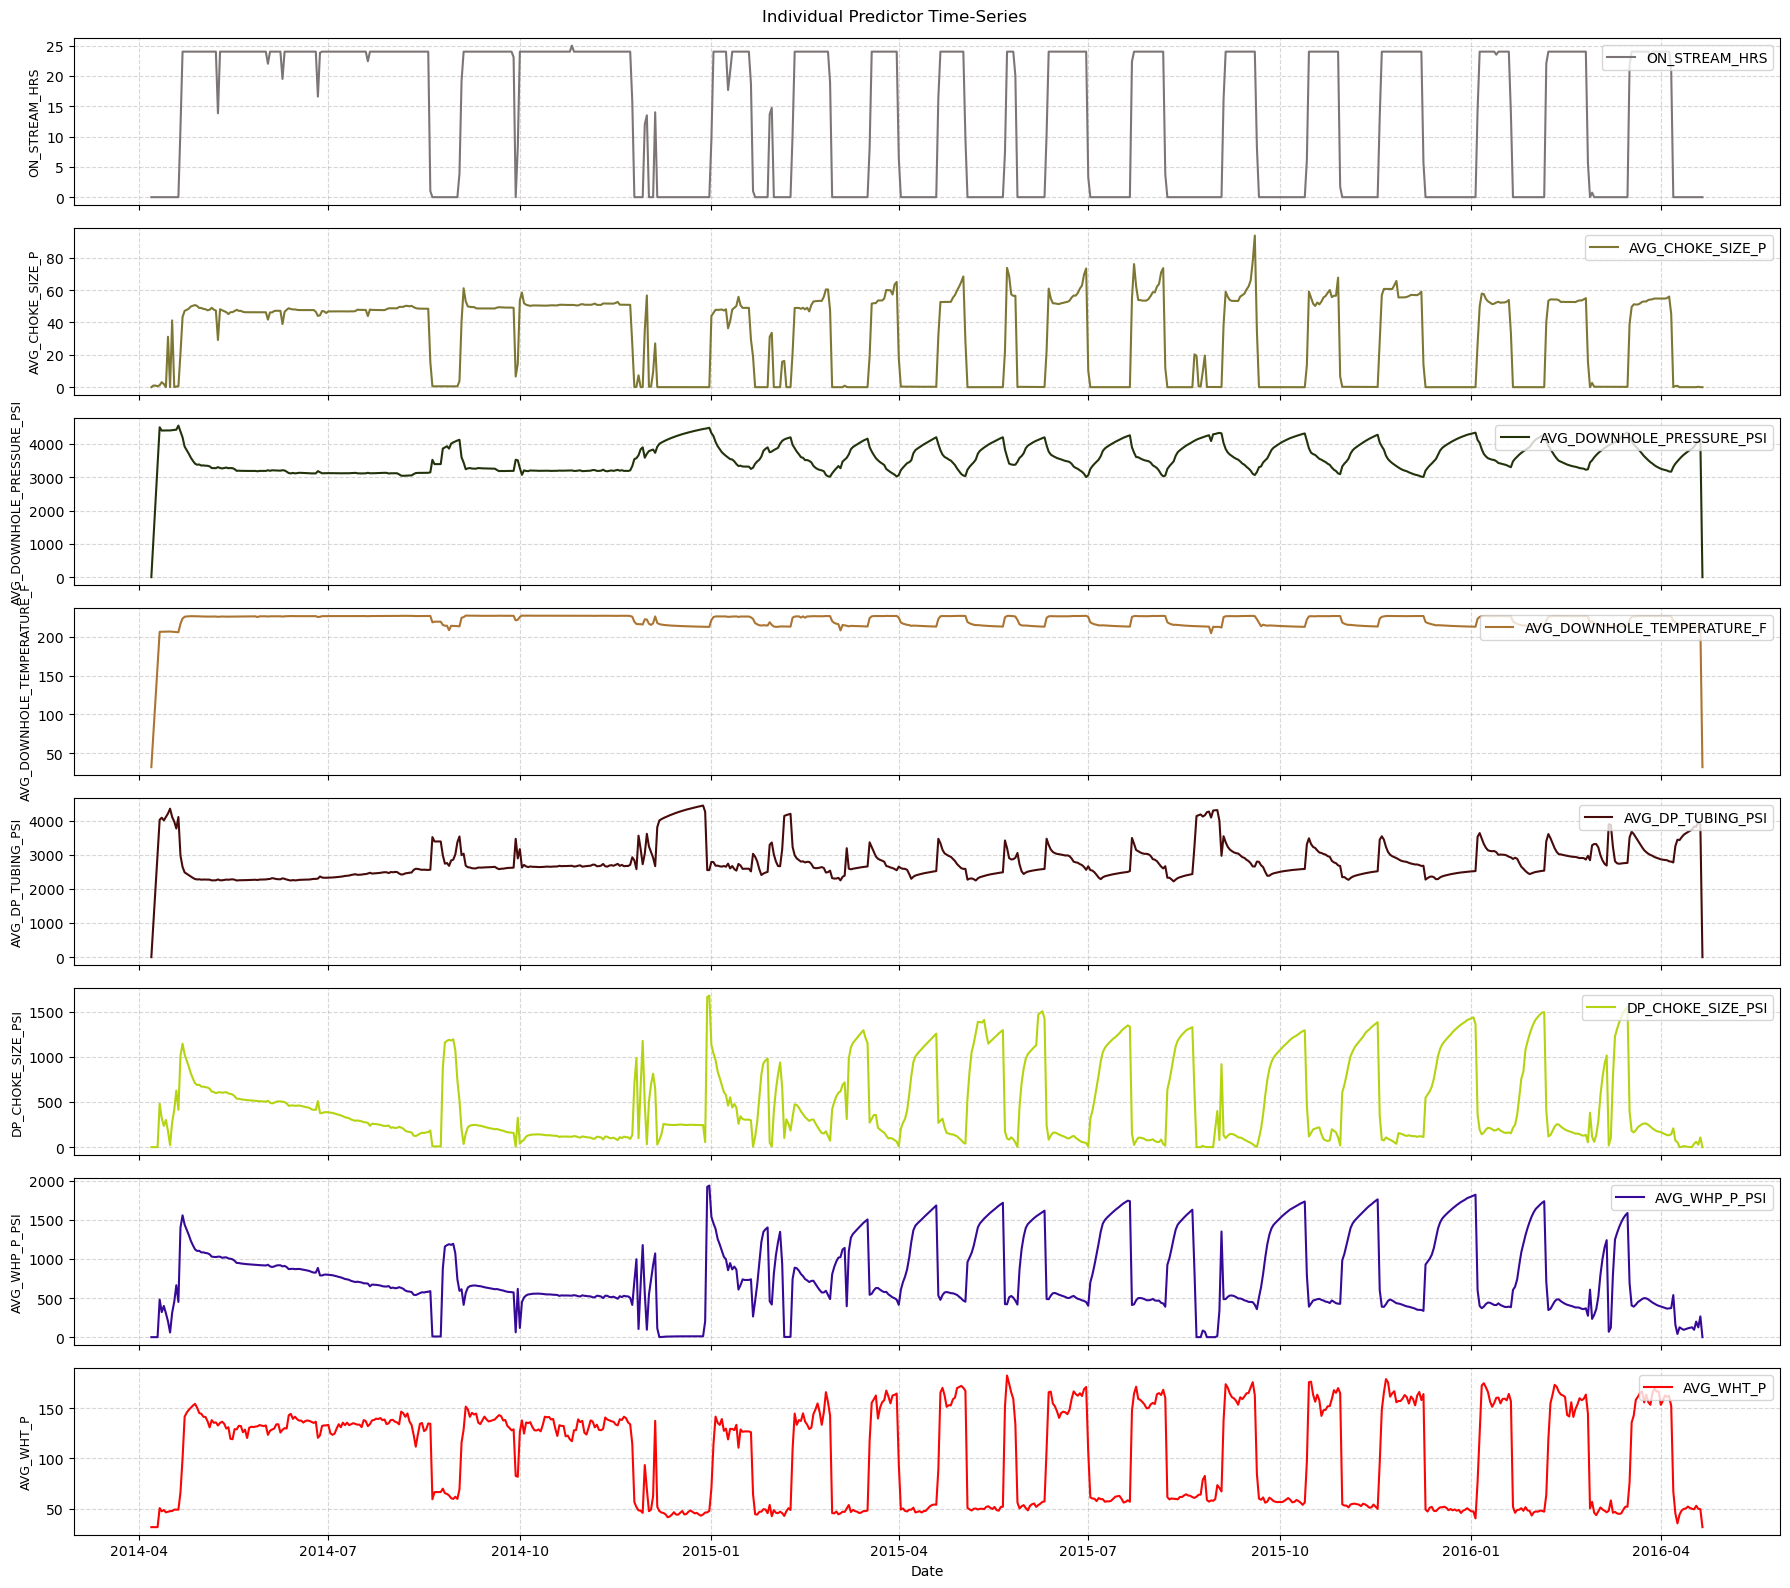

In [11]:
# dropped_nan_cols columns that have nan with more than 50% 
# dropped_zero_cols columns that have zeros with more than 50%
#missing_indicator_cols list of columns that tells us the column nan was changed using linear interpolation
#negative_indicator_cols   #list of columns that tells us the columns with negative values was set to zero

df, dropped_nan_cols, dropped_zero_cols, missing_indicator_cols, negative_indicator_cols=plot_clean_plot(df)

In [12]:
df.columns

Index(['WELL_BORE_CODE', 'NPD_WELL_BORE_CODE', 'NPD_WELL_BORE_NAME',
       'NPD_FIELD_CODE', 'NPD_FIELD_NAME', 'NPD_FACILITY_CODE',
       'NPD_FACILITY_NAME', 'ON_STREAM_HRS', 'AVG_CHOKE_SIZE_P',
       'AVG_CHOKE_UOM', 'FLOW_KIND', 'WELL_TYPE', 'AVG_DOWNHOLE_PRESSURE_PSI',
       'AVG_DOWNHOLE_TEMPERATURE_F', 'AVG_DP_TUBING_PSI', 'DP_CHOKE_SIZE_PSI',
       'AVG_WHP_P_PSI', 'AVG_WHT_P', 'BORE_OIL_VOL_STB_D',
       'BORE_GAS_VOL_MSCF_D', 'BORE_WAT_VOL_STB_D',
       'AVG_DOWNHOLE_PRESSURE_PSI_WAS_MISSING',
       'AVG_DOWNHOLE_TEMPERATURE_F_WAS_MISSING',
       'AVG_DP_TUBING_PSI_WAS_MISSING'],
      dtype='object')

In [13]:
# just to see the columns that were drops
dropped_nan_cols, dropped_zero_cols, missing_indicator_cols, negative_indicator_cols

(['AVG_ANNULUS_PRESS_PSI', 'BORE_WI_VOL_STB_D'],
 [],
 ['AVG_DOWNHOLE_PRESSURE_PSI_WAS_MISSING',
  'AVG_DOWNHOLE_TEMPERATURE_F_WAS_MISSING',
  'AVG_DP_TUBING_PSI_WAS_MISSING'],
 [])

In [14]:
# drop indicator columns
df = df.drop(columns=missing_indicator_cols,errors='ignore')
df = df.drop(columns=negative_indicator_cols,errors='ignore')
df

,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_CHOKE_SIZE_P,AVG_CHOKE_UOM,...,WELL_TYPE,AVG_DOWNHOLE_PRESSURE_PSI,AVG_DOWNHOLE_TEMPERATURE_F,AVG_DP_TUBING_PSI,DP_CHOKE_SIZE_PSI,AVG_WHP_P_PSI,AVG_WHT_P,BORE_OIL_VOL_STB_D,BORE_GAS_VOL_MSCF_D,BORE_WAT_VOL_STB_D
DATEPRD,,,,,,,,,,,,,,,,,,,,,
2014-04-07,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.000000,%,...,WI,0.000000,32.000000,0.000000,0.000000,0.000000,32.000000,0.0,0.0,0.0
2014-04-08,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,1.003059,%,...,OP,1125.408365,75.594150,1005.397107,0.000000,0.000000,32.000000,0.0,0.0,0.0
2014-04-09,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.979008,%,...,OP,2250.816730,119.188301,2010.794214,0.000000,0.000000,32.000000,0.0,0.0,0.0
2014-04-10,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.545759,%,...,OP,3376.225094,162.782451,3016.191321,0.000000,0.000000,32.000000,0.0,0.0,0.0
2014-04-11,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,1.215987,%,...,OP,4501.633459,206.376602,4021.588427,479.668948,480.045032,50.863856,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-04-17,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.000000,%,...,OP,3919.920125,214.156526,3825.672402,38.366612,94.247723,49.644446,0.0,0.0,0.0
2016-04-18,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.000000,%,...,OP,4015.651877,214.215836,3816.747199,59.755656,198.904678,53.136032,0.0,0.0,0.0
2016-04-19,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.265188,%,...,OP,4091.600010,214.119572,3967.218467,27.068152,124.381543,50.214308,0.0,0.0,0.0


In [15]:
# drop columns not needed
cols_to_drop = ['WELL_BORE_CODE', 'NPD_WELL_BORE_CODE', 'NPD_WELL_BORE_NAME',
                'NPD_FIELD_CODE', 'NPD_FIELD_NAME', 'NPD_FACILITY_CODE',
                'NPD_FACILITY_NAME',"AVG_CHOKE_UOM",'FLOW_KIND', 'WELL_TYPE']
df = df.drop(columns=cols_to_drop,errors='ignore')
df

,ON_STREAM_HRS,AVG_CHOKE_SIZE_P,AVG_DOWNHOLE_PRESSURE_PSI,AVG_DOWNHOLE_TEMPERATURE_F,AVG_DP_TUBING_PSI,DP_CHOKE_SIZE_PSI,AVG_WHP_P_PSI,AVG_WHT_P,BORE_OIL_VOL_STB_D,BORE_GAS_VOL_MSCF_D,BORE_WAT_VOL_STB_D
DATEPRD,,,,,,,,,,,
2014-04-07,0.0,0.000000,0.000000,32.000000,0.000000,0.000000,0.000000,32.000000,0.0,0.0,0.0
2014-04-08,0.0,1.003059,1125.408365,75.594150,1005.397107,0.000000,0.000000,32.000000,0.0,0.0,0.0
2014-04-09,0.0,0.979008,2250.816730,119.188301,2010.794214,0.000000,0.000000,32.000000,0.0,0.0,0.0
2014-04-10,0.0,0.545759,3376.225094,162.782451,3016.191321,0.000000,0.000000,32.000000,0.0,0.0,0.0
2014-04-11,0.0,1.215987,4501.633459,206.376602,4021.588427,479.668948,480.045032,50.863856,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2016-04-17,0.0,0.000000,3919.920125,214.156526,3825.672402,38.366612,94.247723,49.644446,0.0,0.0,0.0
2016-04-18,0.0,0.000000,4015.651877,214.215836,3816.747199,59.755656,198.904678,53.136032,0.0,0.0,0.0
2016-04-19,0.0,0.265188,4091.600010,214.119572,3967.218467,27.068152,124.381543,50.214308,0.0,0.0,0.0


In [16]:
#df = df.drop(columns=['GOR_MSCF/STB', 'WCUT'])

In [17]:
df.columns

Index(['ON_STREAM_HRS', 'AVG_CHOKE_SIZE_P', 'AVG_DOWNHOLE_PRESSURE_PSI',
       'AVG_DOWNHOLE_TEMPERATURE_F', 'AVG_DP_TUBING_PSI', 'DP_CHOKE_SIZE_PSI',
       'AVG_WHP_P_PSI', 'AVG_WHT_P', 'BORE_OIL_VOL_STB_D',
       'BORE_GAS_VOL_MSCF_D', 'BORE_WAT_VOL_STB_D'],
      dtype='object')

# Feature Engineering Steps

This steps is for making and testing the pipeline. It uses all the data. Again it is only for making sure the pipepline works

# 1 Calulate GOR and WCU

In [18]:
GOR_WCUT_feat=GOR_WCUT_Transformer(
        oil_col='BORE_OIL_VOL_STB_D', 
        gas_col='BORE_GAS_VOL_MSCF_D', 
        water_col='BORE_WAT_VOL_STB_D')

In [19]:
# Add the GOR and WCUT to the dataframe.
df = GOR_WCUT_feat.fit_transform(df)

In [20]:
df

,ON_STREAM_HRS,AVG_CHOKE_SIZE_P,AVG_DOWNHOLE_PRESSURE_PSI,AVG_DOWNHOLE_TEMPERATURE_F,AVG_DP_TUBING_PSI,DP_CHOKE_SIZE_PSI,AVG_WHP_P_PSI,AVG_WHT_P,BORE_OIL_VOL_STB_D,BORE_GAS_VOL_MSCF_D,BORE_WAT_VOL_STB_D,GOR_MSCF/STB,WCUT
DATEPRD,,,,,,,,,,,,,
2014-04-07,0.0,0.000000,0.000000,32.000000,0.000000,0.000000,0.000000,32.000000,0.0,0.0,0.0,0.0,0.0
2014-04-08,0.0,1.003059,1125.408365,75.594150,1005.397107,0.000000,0.000000,32.000000,0.0,0.0,0.0,0.0,0.0
2014-04-09,0.0,0.979008,2250.816730,119.188301,2010.794214,0.000000,0.000000,32.000000,0.0,0.0,0.0,0.0,0.0
2014-04-10,0.0,0.545759,3376.225094,162.782451,3016.191321,0.000000,0.000000,32.000000,0.0,0.0,0.0,0.0,0.0
2014-04-11,0.0,1.215987,4501.633459,206.376602,4021.588427,479.668948,480.045032,50.863856,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-04-17,0.0,0.000000,3919.920125,214.156526,3825.672402,38.366612,94.247723,49.644446,0.0,0.0,0.0,0.0,0.0
2016-04-18,0.0,0.000000,4015.651877,214.215836,3816.747199,59.755656,198.904678,53.136032,0.0,0.0,0.0,0.0,0.0
2016-04-19,0.0,0.265188,4091.600010,214.119572,3967.218467,27.068152,124.381543,50.214308,0.0,0.0,0.0,0.0,0.0


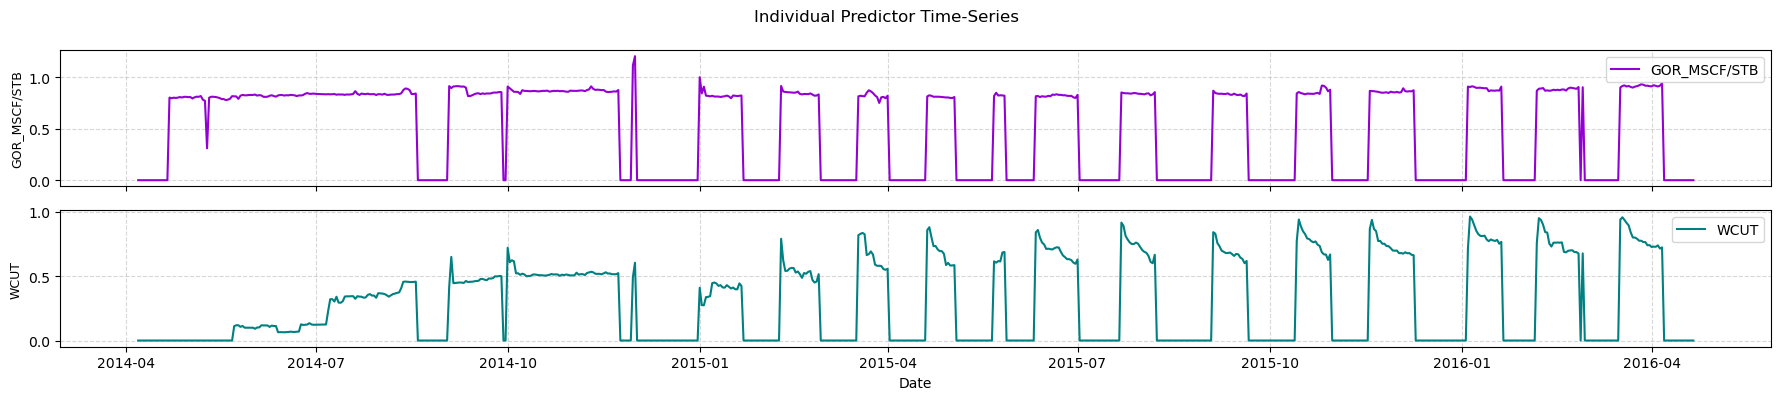

In [21]:
# plot the GOR and WCUT
seperate_predictor_plot(df[["GOR_MSCF/STB","WCUT"]])

In [22]:
df.isnull().sum()

ON_STREAM_HRS                 0
AVG_CHOKE_SIZE_P              0
AVG_DOWNHOLE_PRESSURE_PSI     0
AVG_DOWNHOLE_TEMPERATURE_F    0
AVG_DP_TUBING_PSI             0
DP_CHOKE_SIZE_PSI             0
AVG_WHP_P_PSI                 0
AVG_WHT_P                     0
BORE_OIL_VOL_STB_D            0
BORE_GAS_VOL_MSCF_D           0
BORE_WAT_VOL_STB_D            0
GOR_MSCF/STB                  0
WCUT                          0
dtype: int64

(df.select_dtypes(include='number') < 0).sum()

# 2 Lag Selection

## 2.1 Seasonal Plots

The selection is just to plot to see what seasonal pattern I see. I going to use this later in 5 where I actually create features for these seasonal patterns

In [23]:
df.columns

Index(['ON_STREAM_HRS', 'AVG_CHOKE_SIZE_P', 'AVG_DOWNHOLE_PRESSURE_PSI',
       'AVG_DOWNHOLE_TEMPERATURE_F', 'AVG_DP_TUBING_PSI', 'DP_CHOKE_SIZE_PSI',
       'AVG_WHP_P_PSI', 'AVG_WHT_P', 'BORE_OIL_VOL_STB_D',
       'BORE_GAS_VOL_MSCF_D', 'BORE_WAT_VOL_STB_D', 'GOR_MSCF/STB', 'WCUT'],
      dtype='object')

### Day of the week seasonal pattern

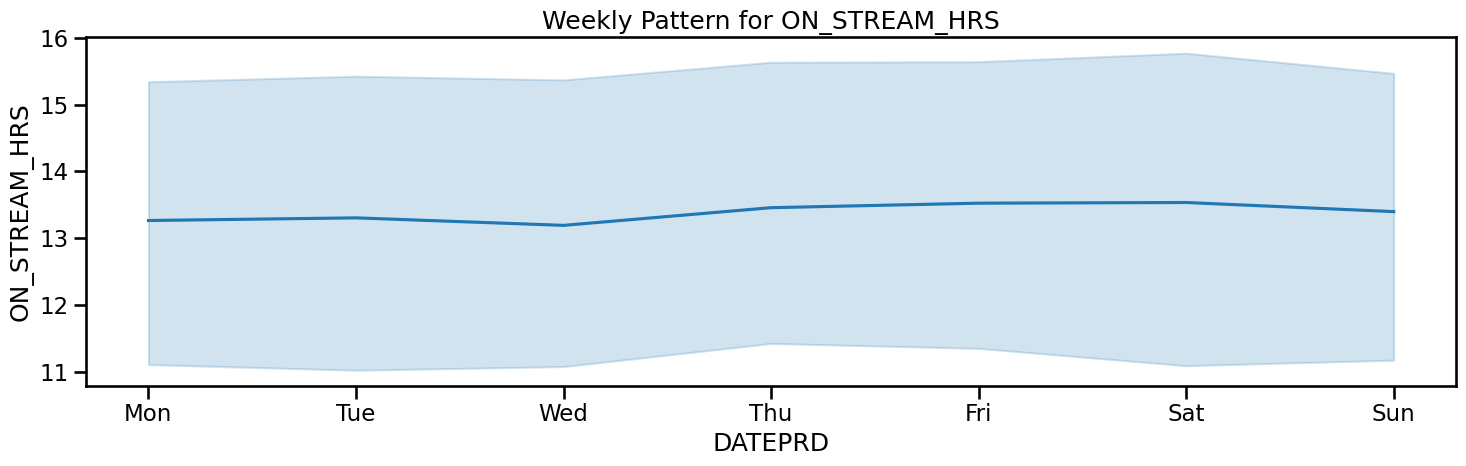

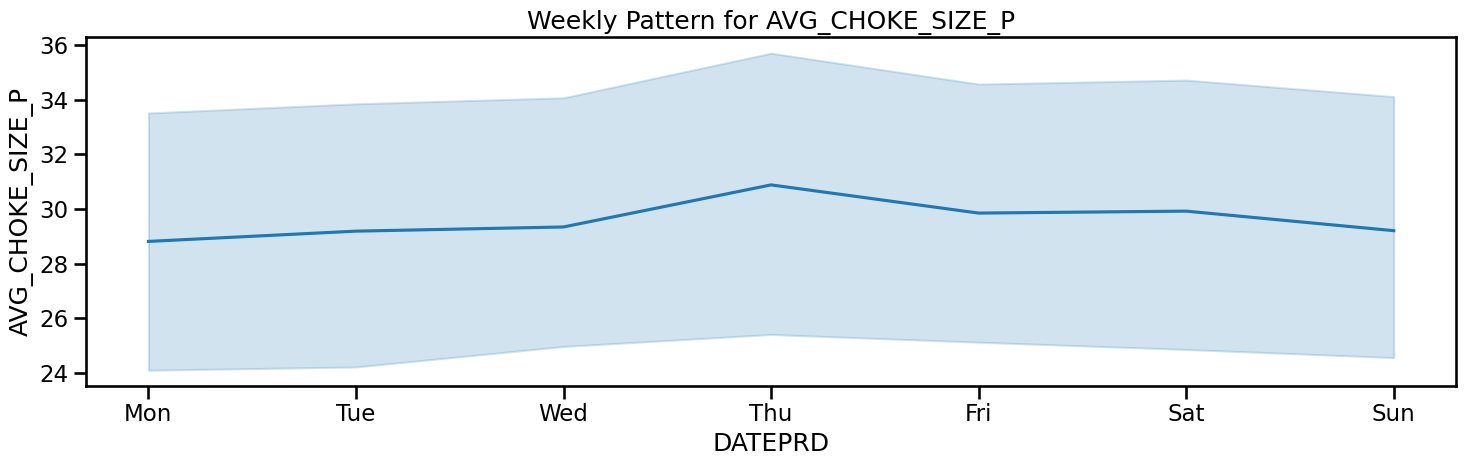

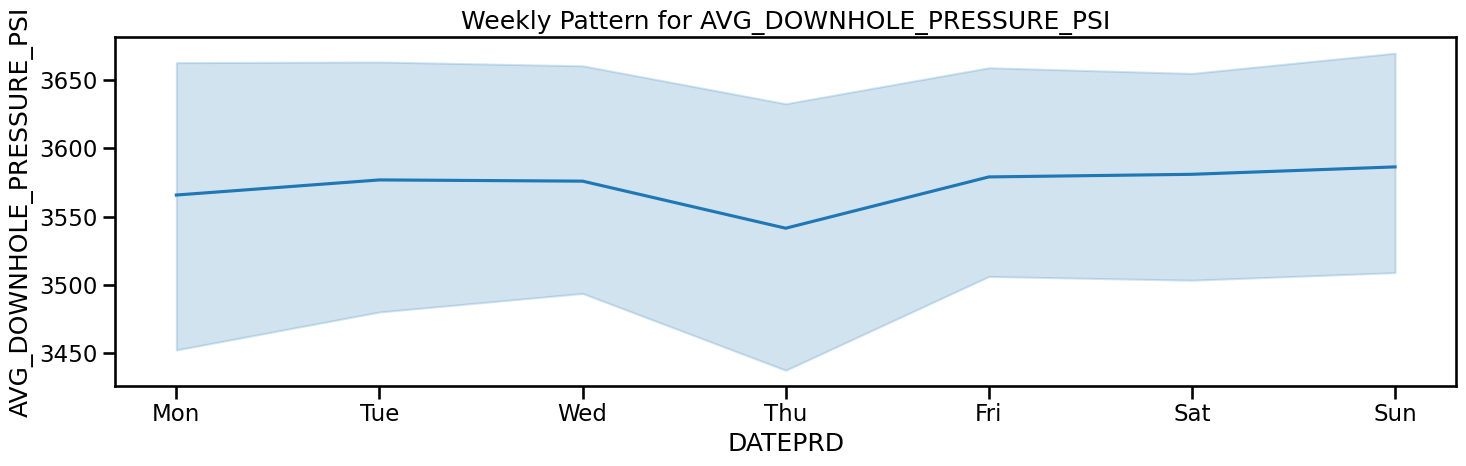

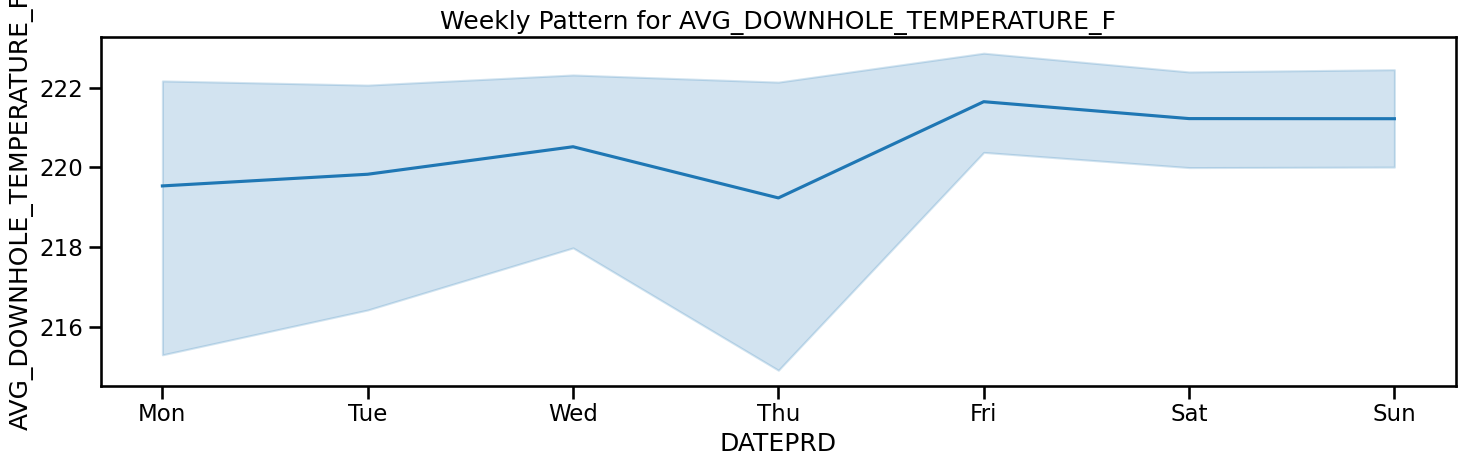

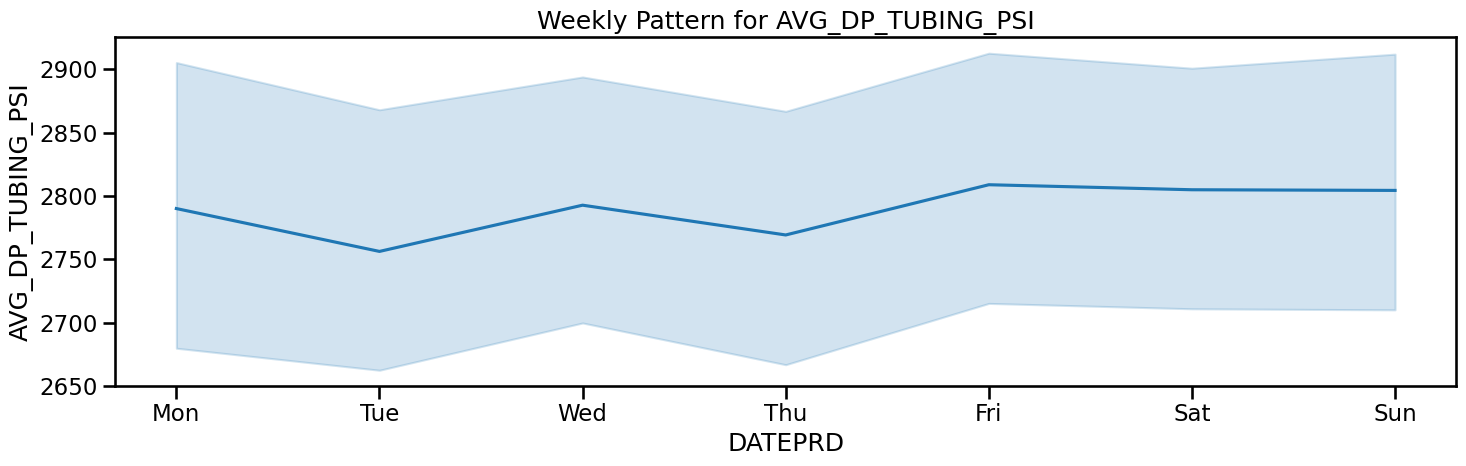

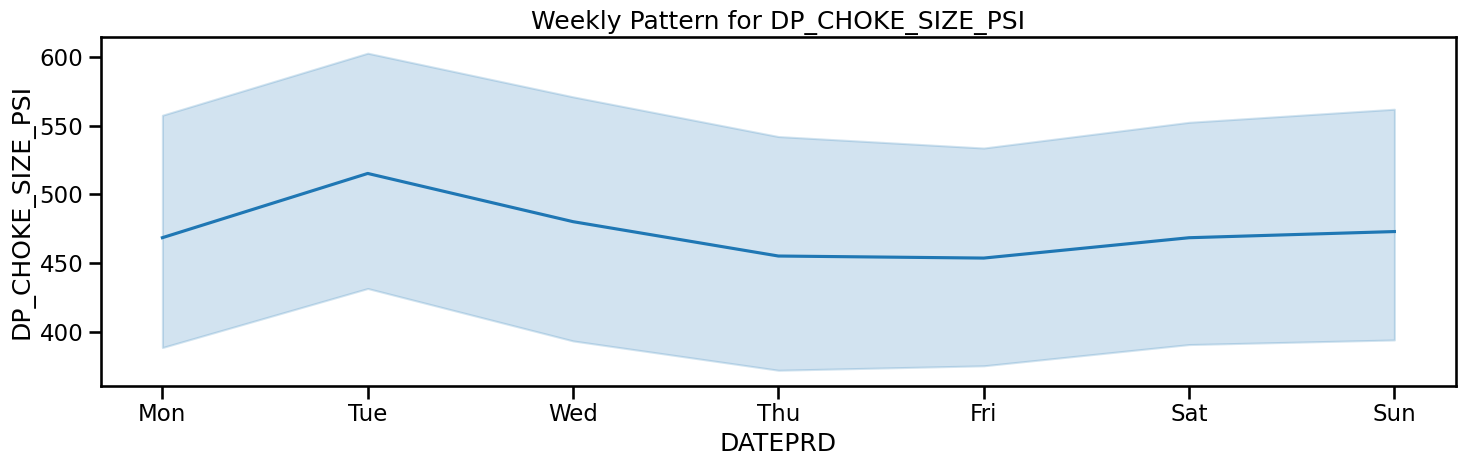

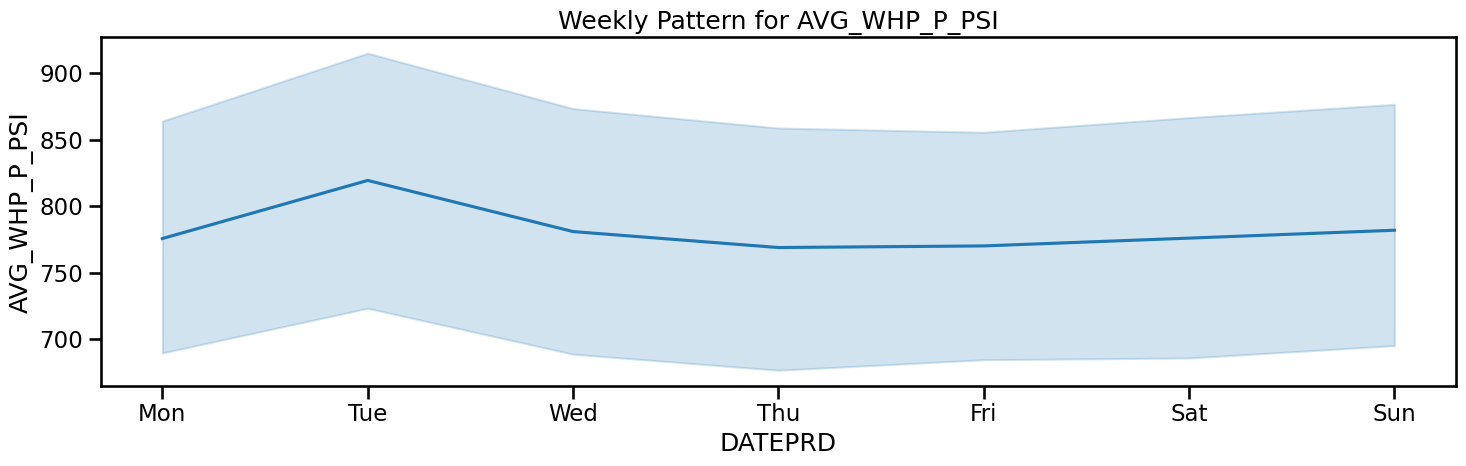

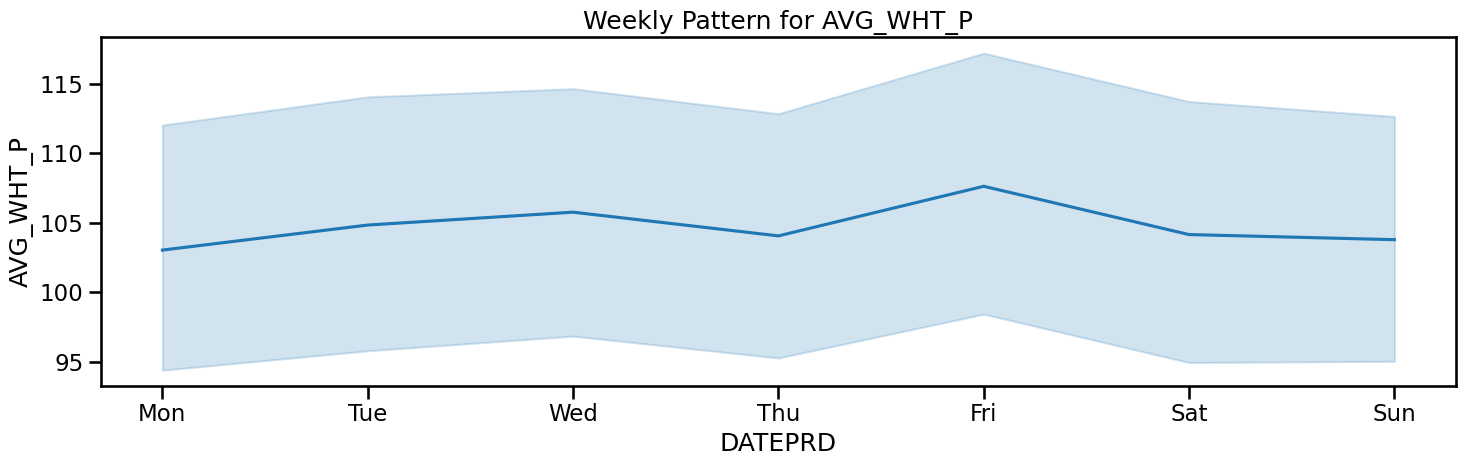

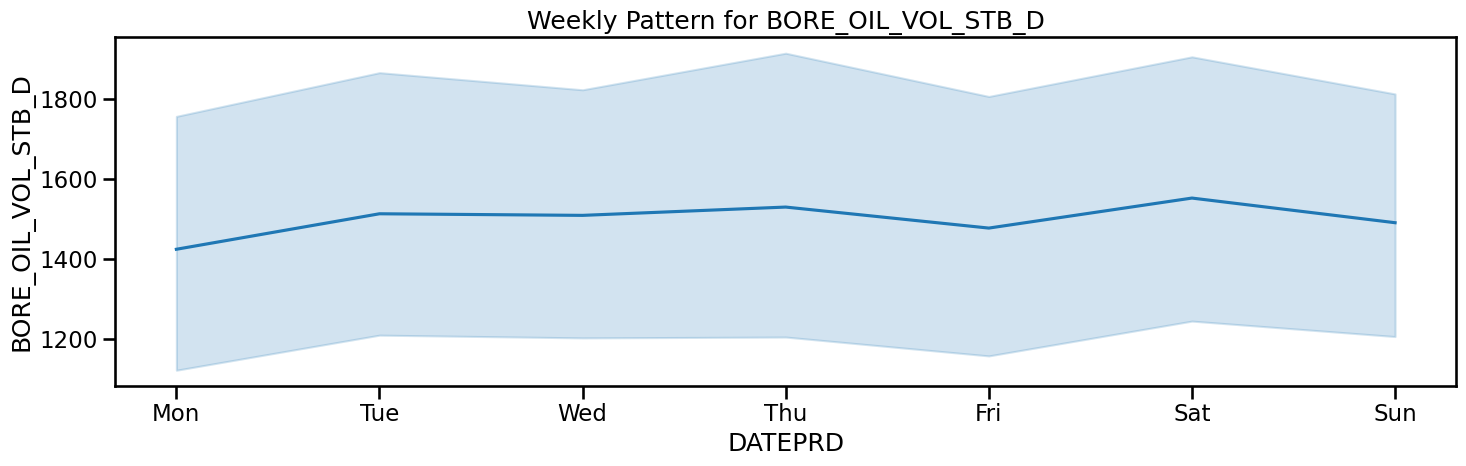

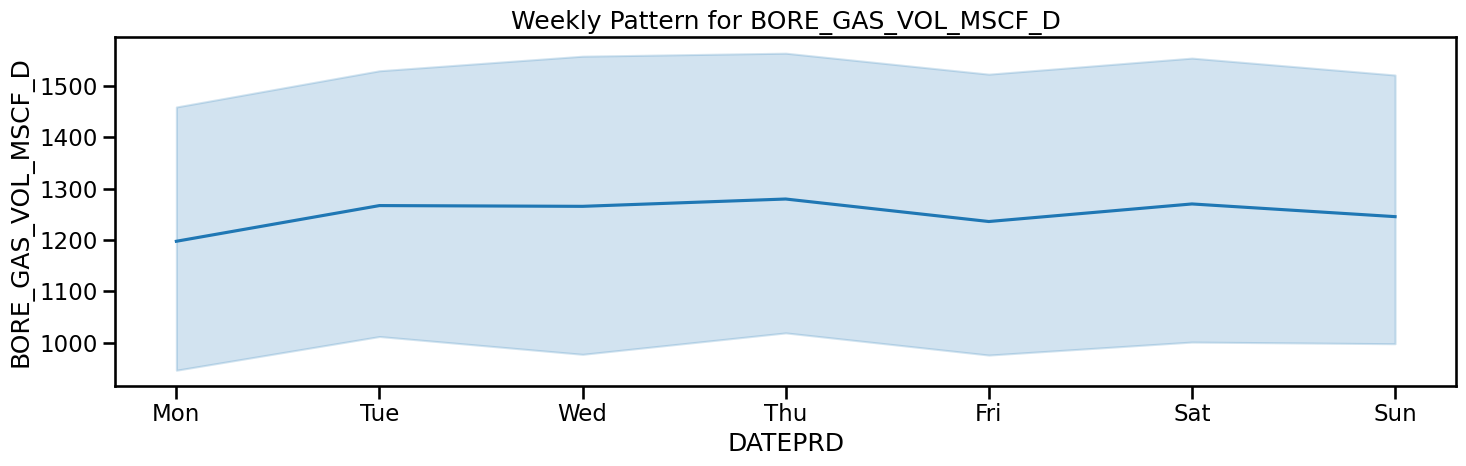

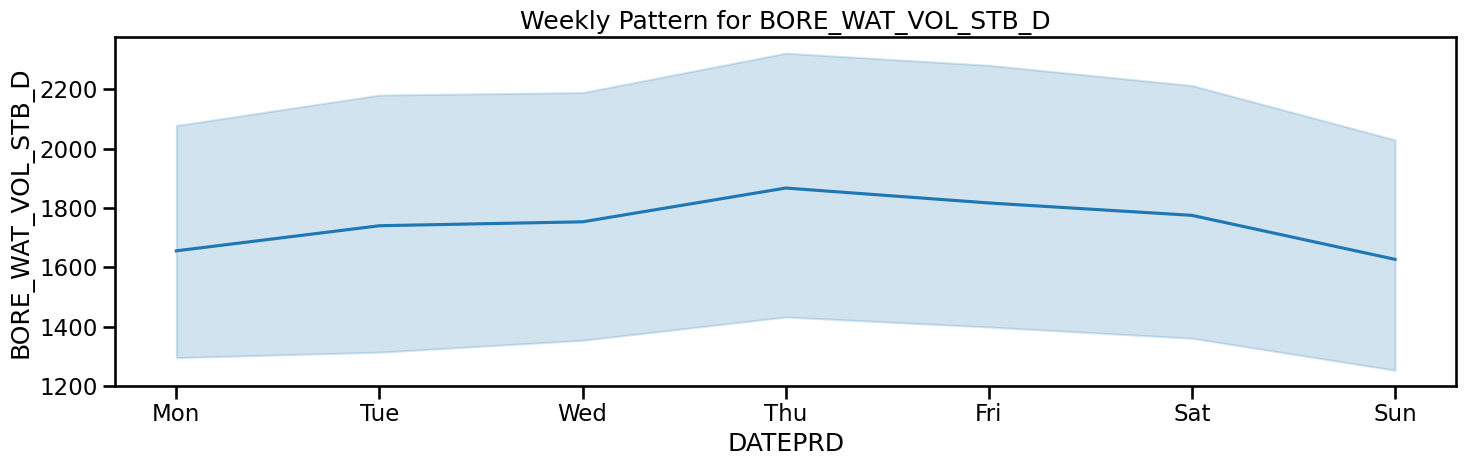

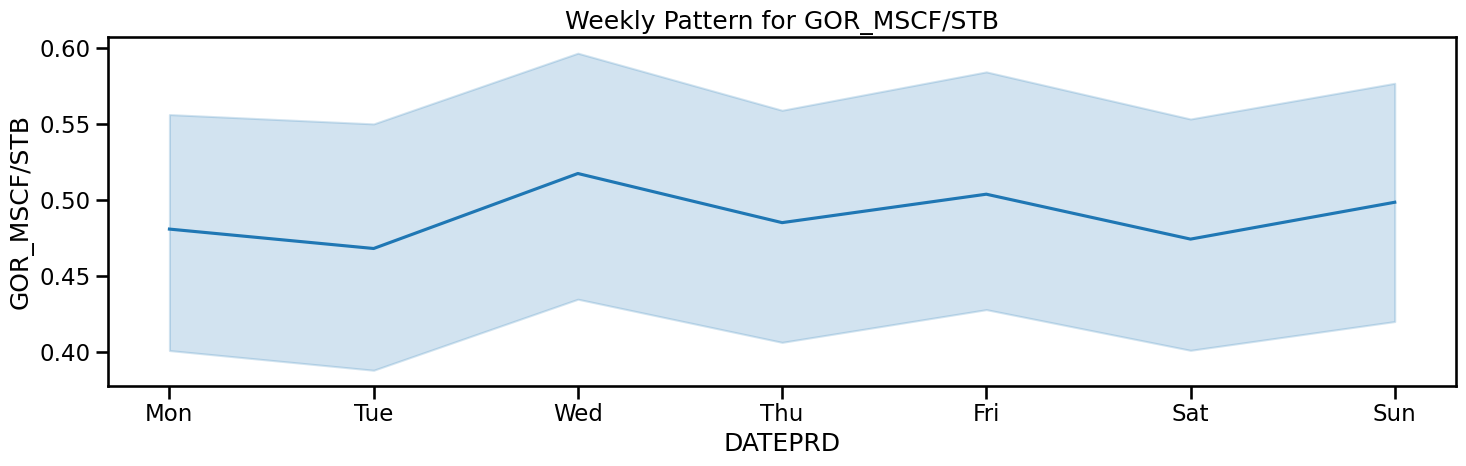

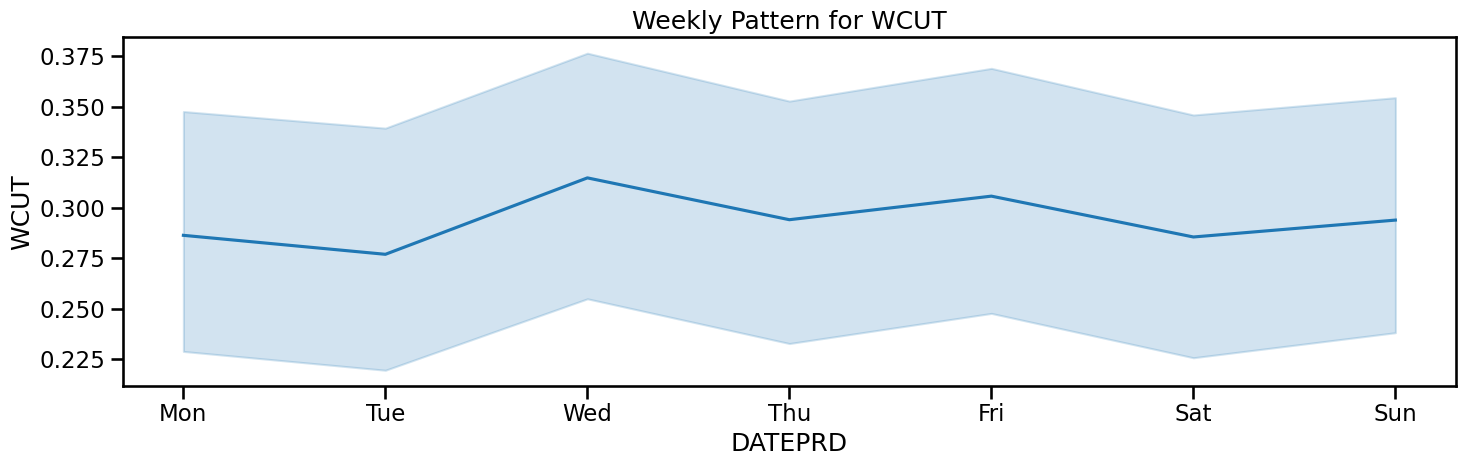

In [23]:
pd.plotting.register_matplotlib_converters()
with sns.plotting_context("talk"):

    for feat in df.columns:
    
        fig, ax = plt.subplots(figsize=[15, 5])
        
        sns.lineplot(x=df.index.dayofweek, y=df[feat], ax=ax)
        ax.set_xticks(range(7))
        ax.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
        ax.set_title(f"Weekly Pattern for {feat}")
        
        plt.tight_layout()
        plt.show()  # Ensures each plot displays sequentially in your loop

I don't think there is a weekly seasonality

###  Month of the year seasonal pattern

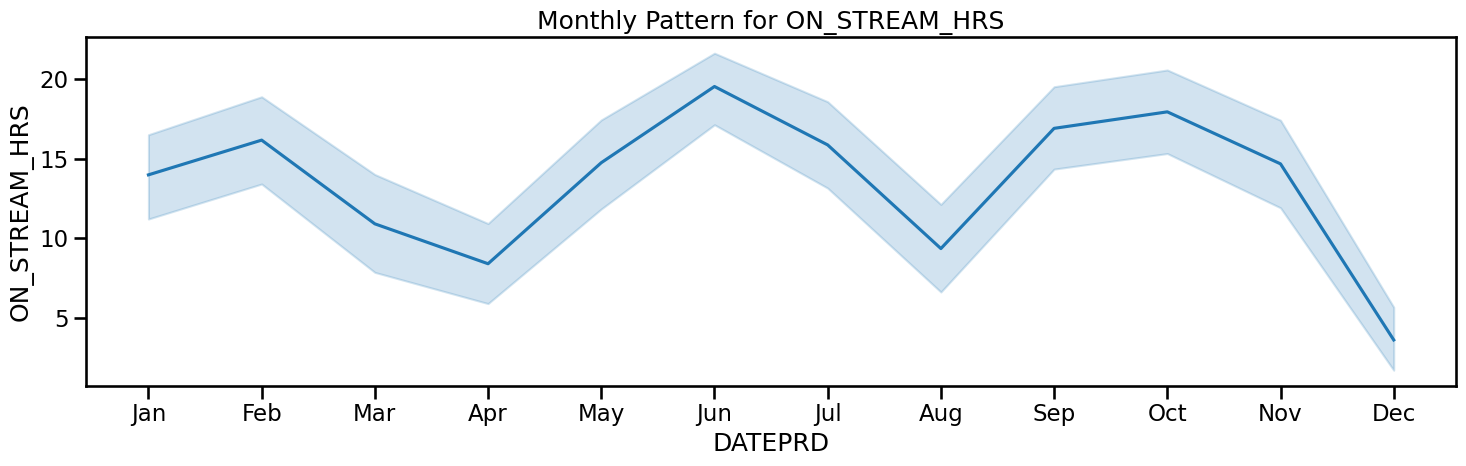

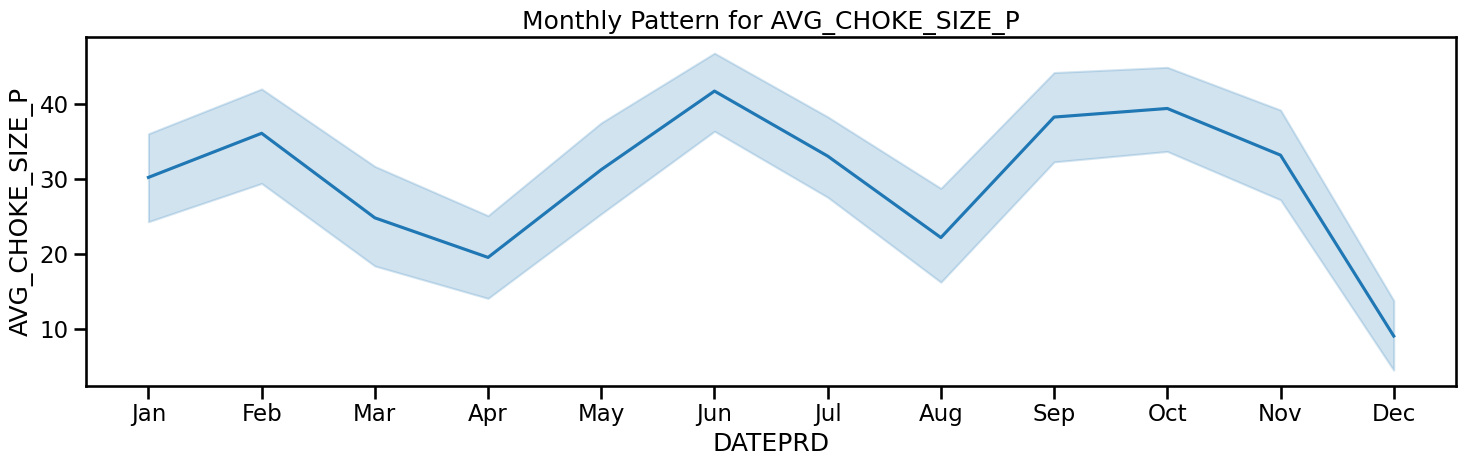

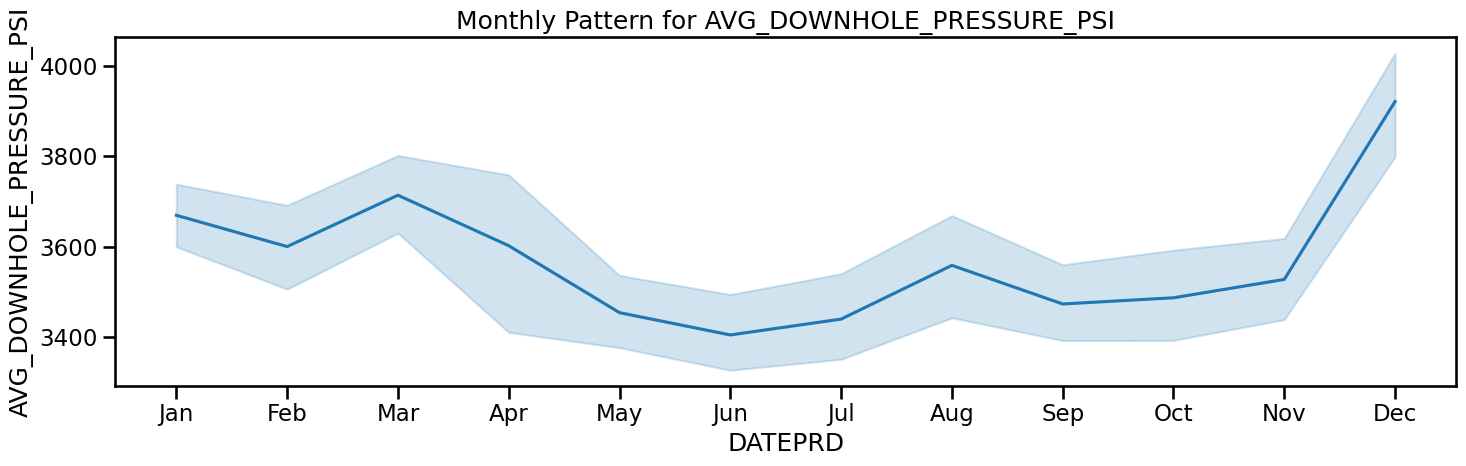

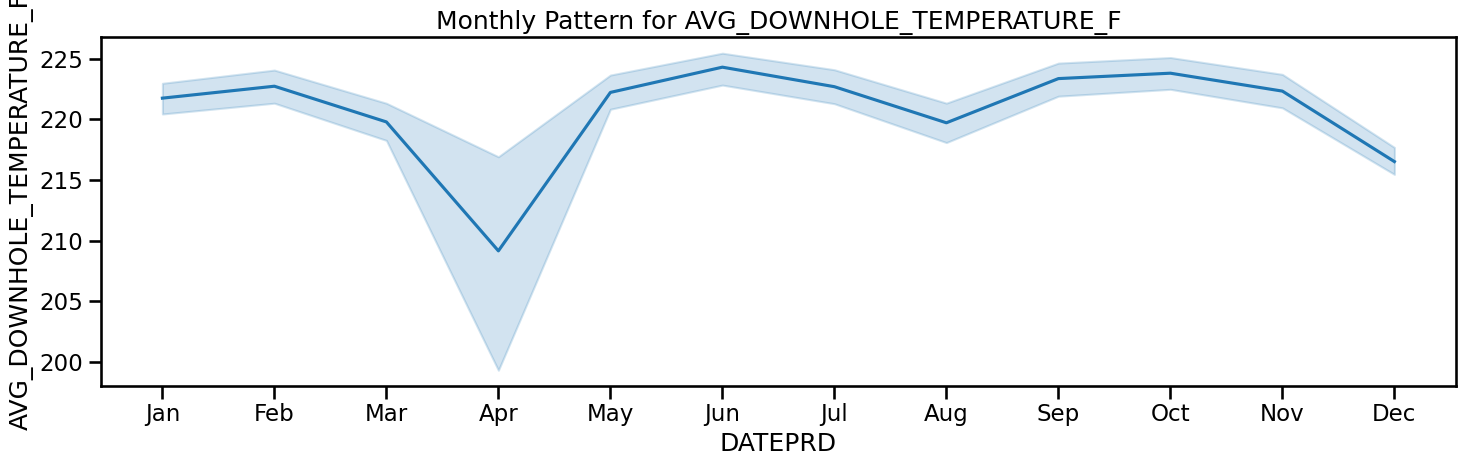

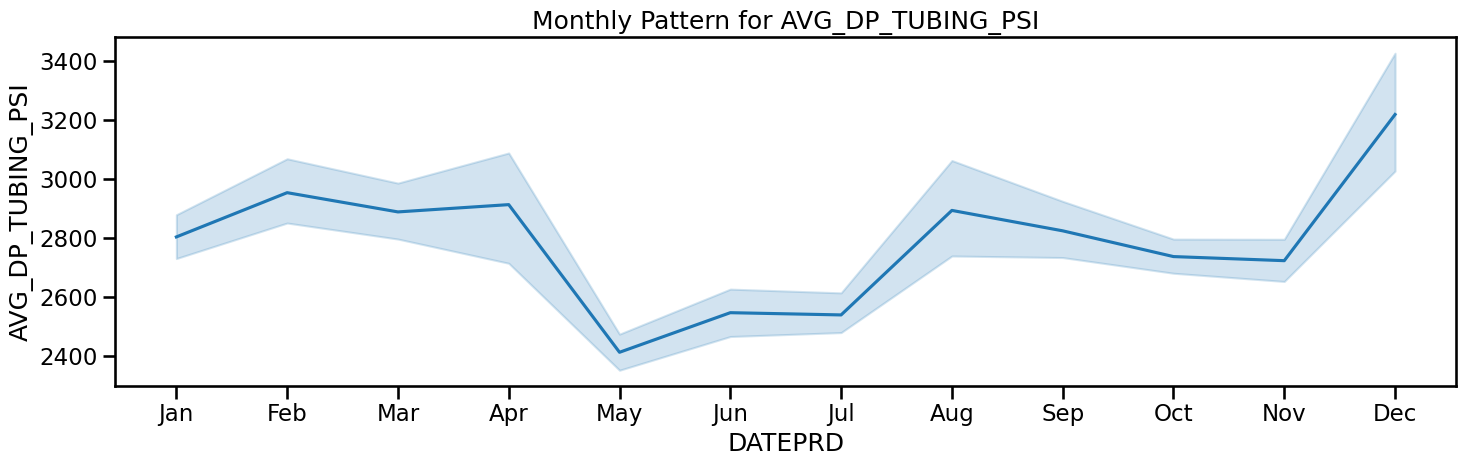

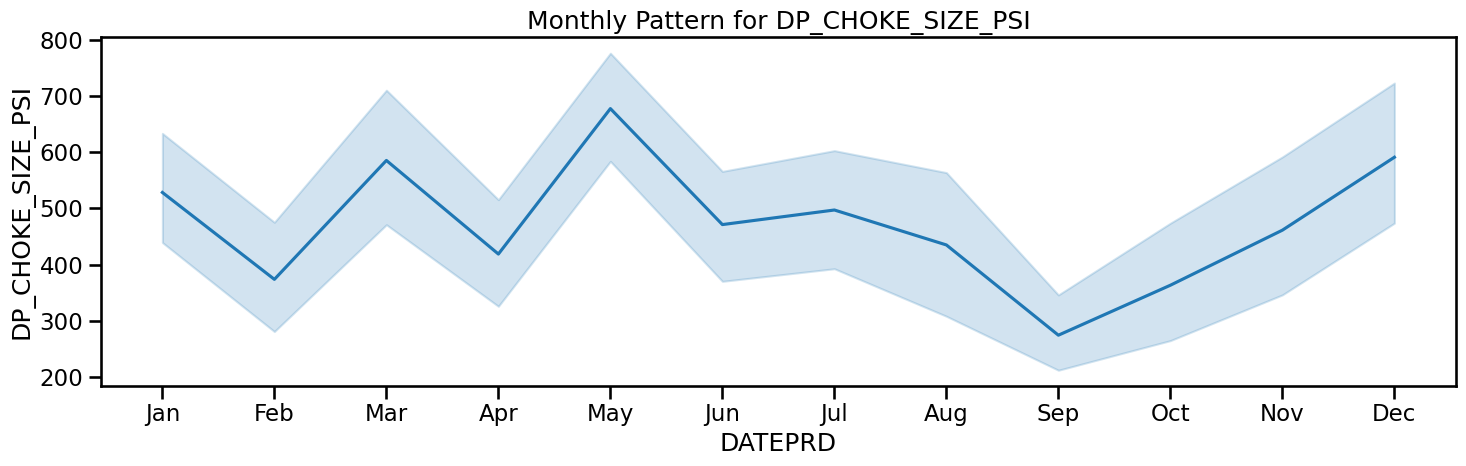

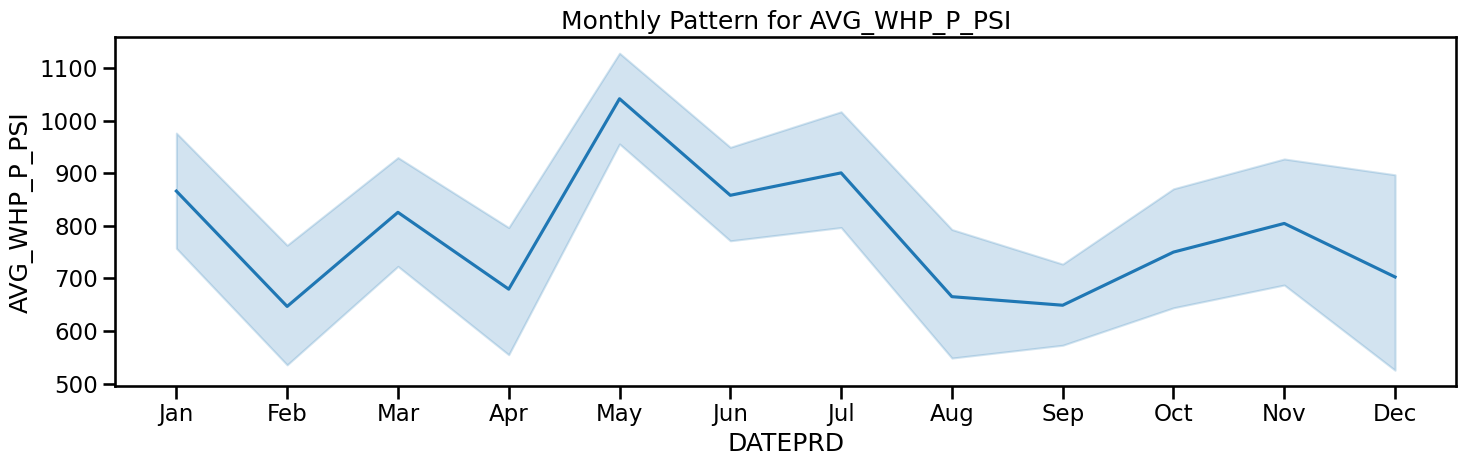

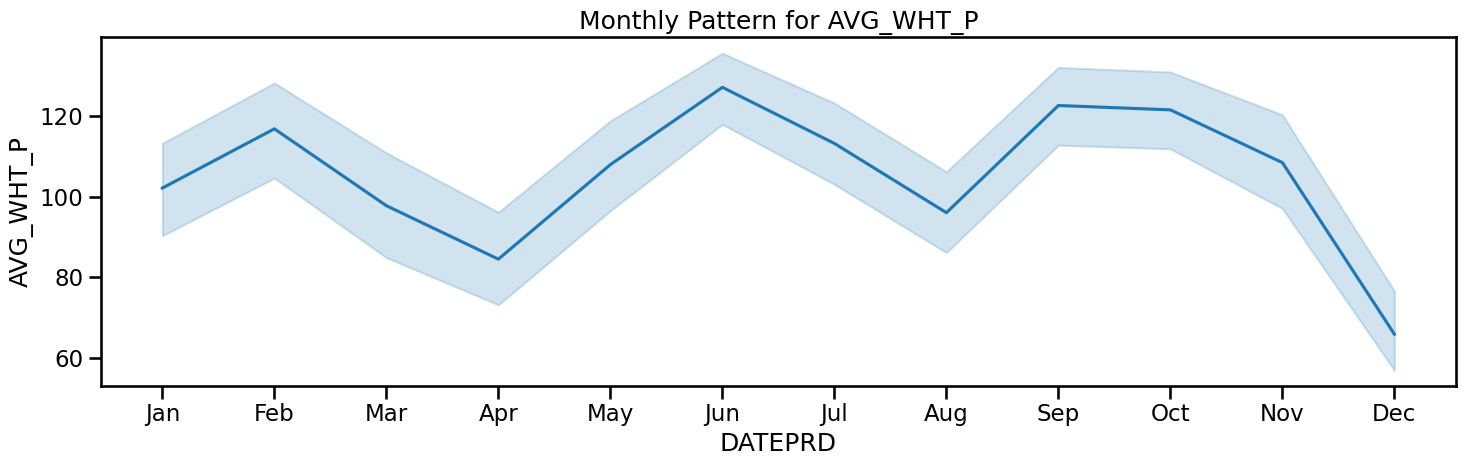

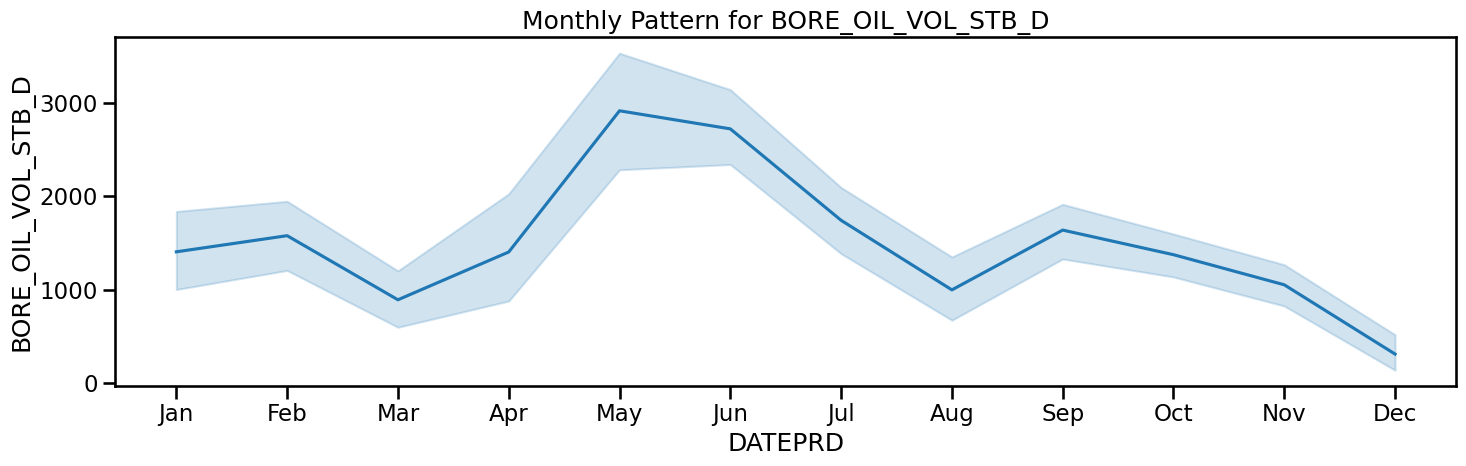

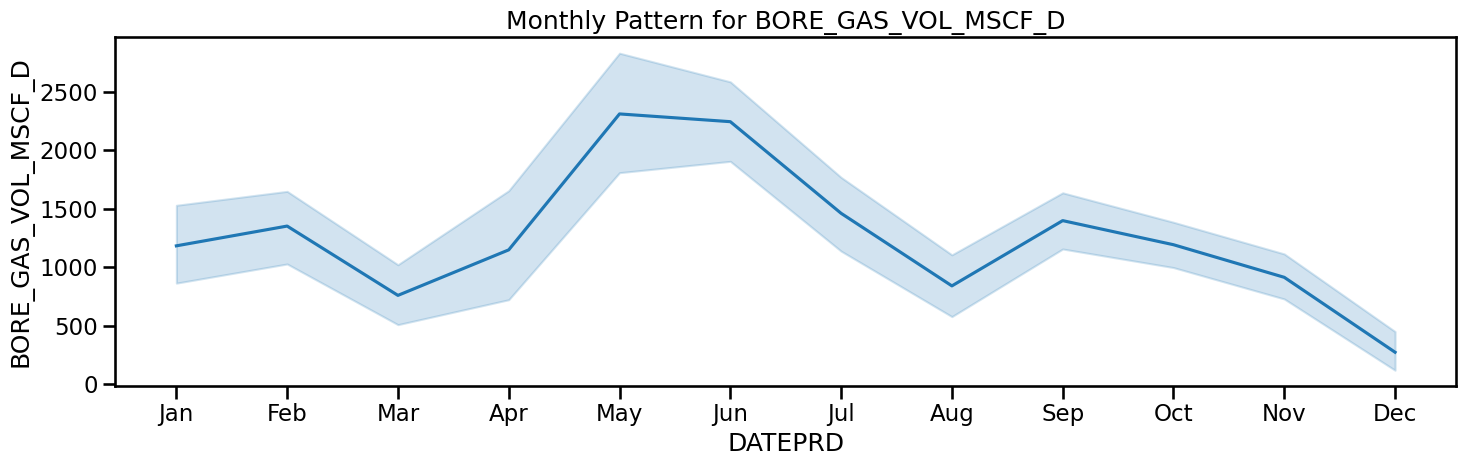

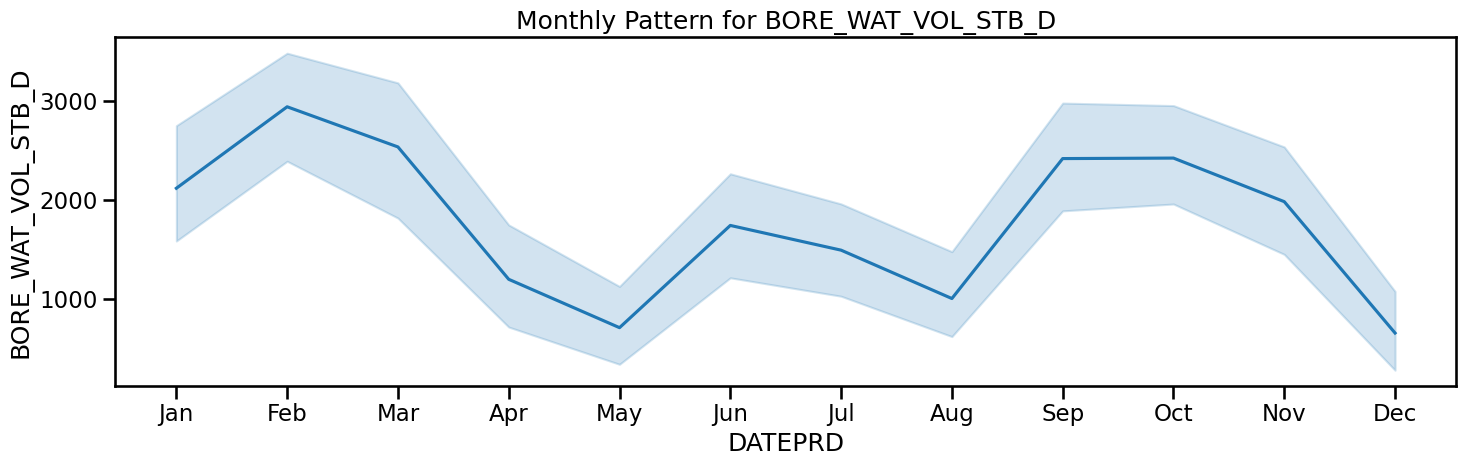

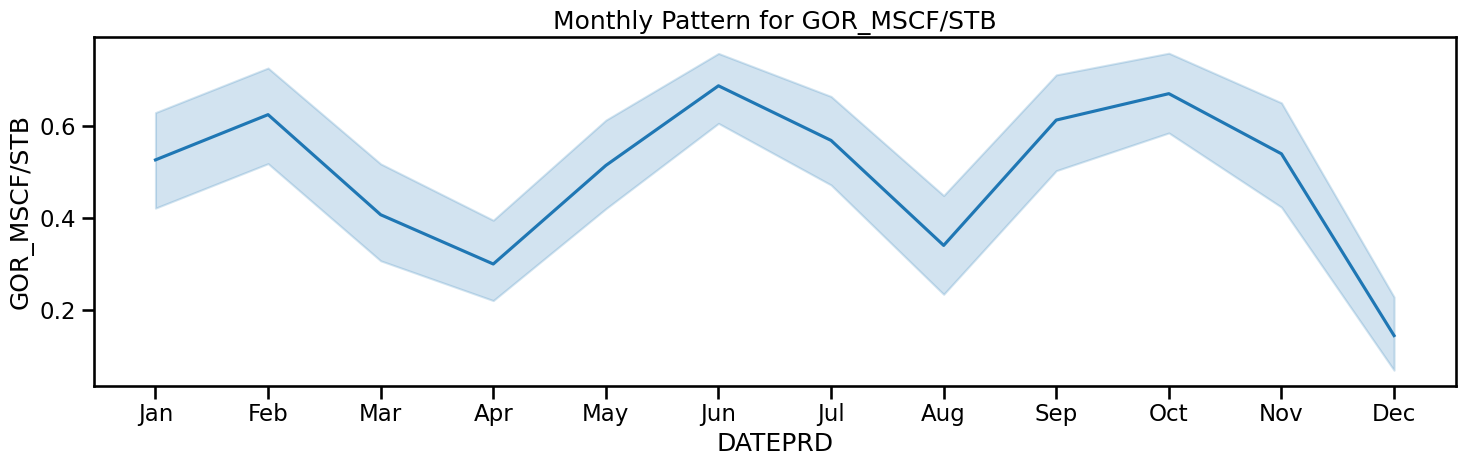

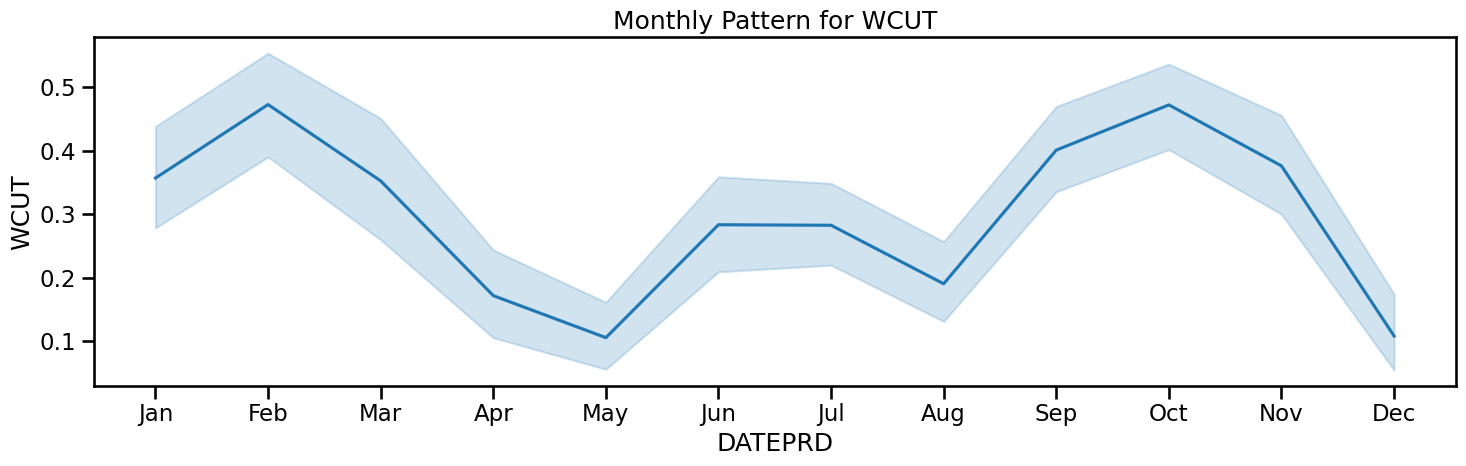

In [24]:
pd.plotting.register_matplotlib_converters()

# Using "talk" context for larger text sizing
with sns.plotting_context("talk"):

    for feat in df.columns:
        fig, ax = plt.subplots(figsize=[15, 5])
        
        # 1. Change x to df.index.month (values ranging from 1 to 12)
        sns.lineplot(x=df.index.month, y=df[feat], ax=ax)
        
        # 2. Update ticks for 12 months (1 through 12)
        ax.set_xticks(range(1, 13))
        ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                            'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
        
        # 3. Update the title to reflect the monthly trend
        ax.set_title(f"Monthly Pattern for {feat}")
        
        plt.tight_layout()
        plt.show()

There is a monthly seasonal pattern

### Week of the year seasonal pattern

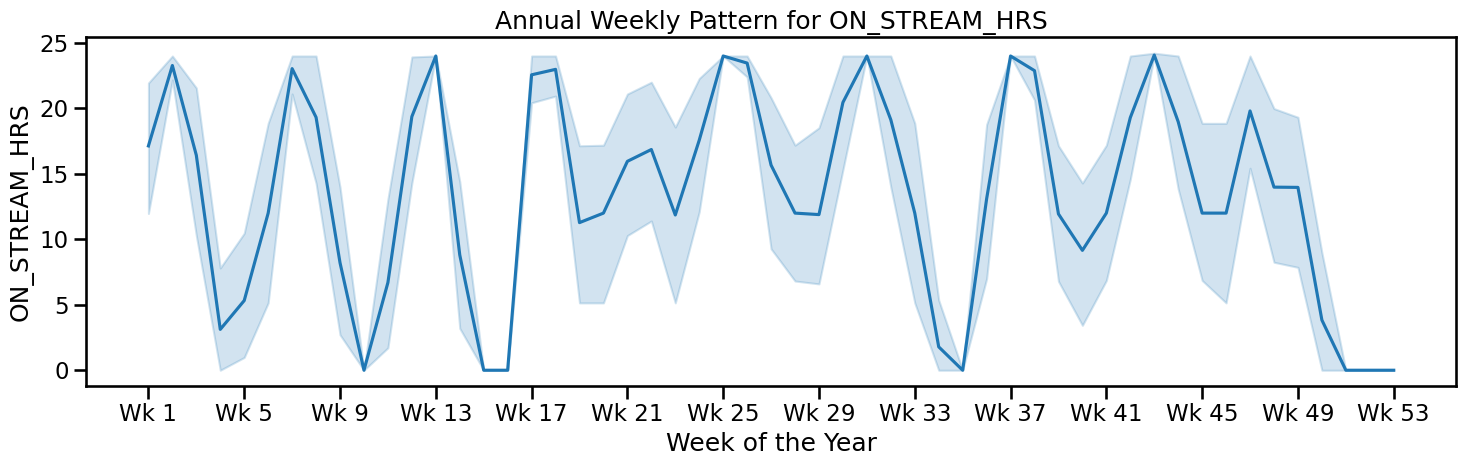

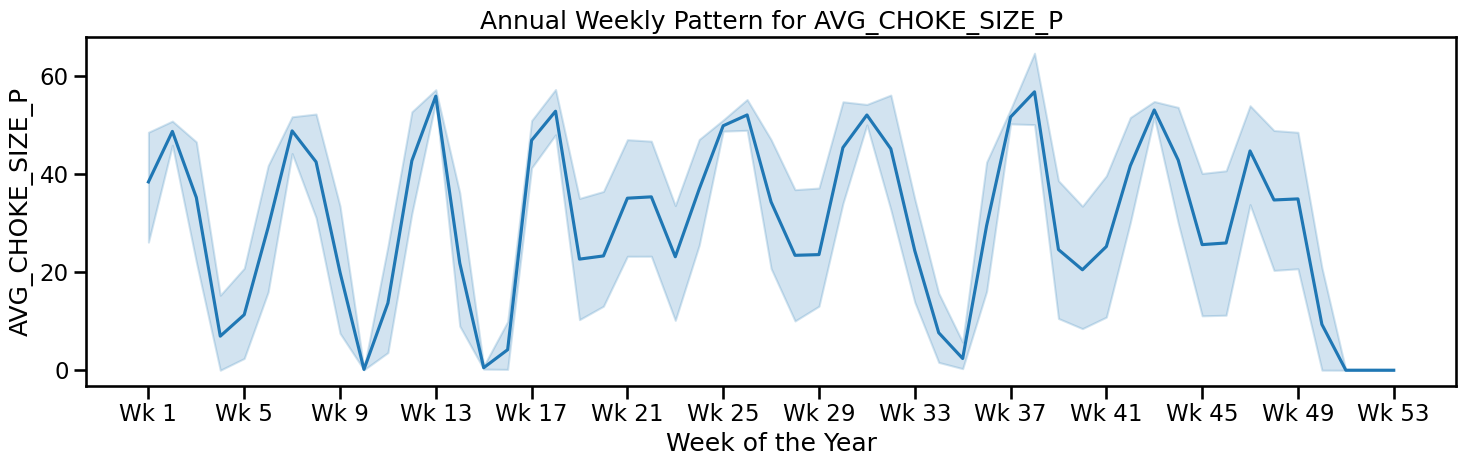

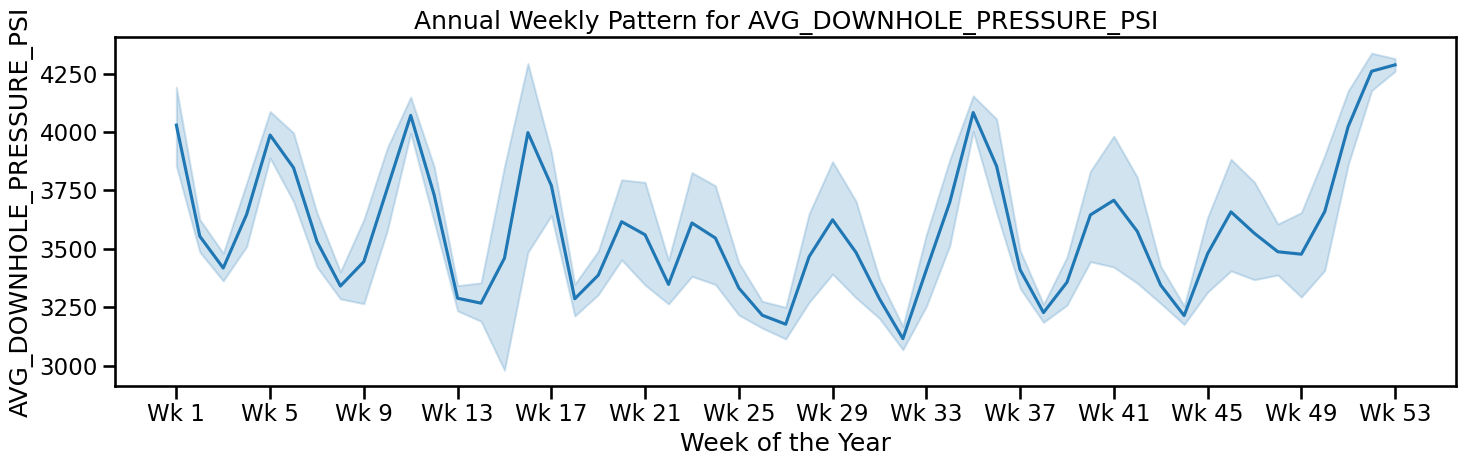

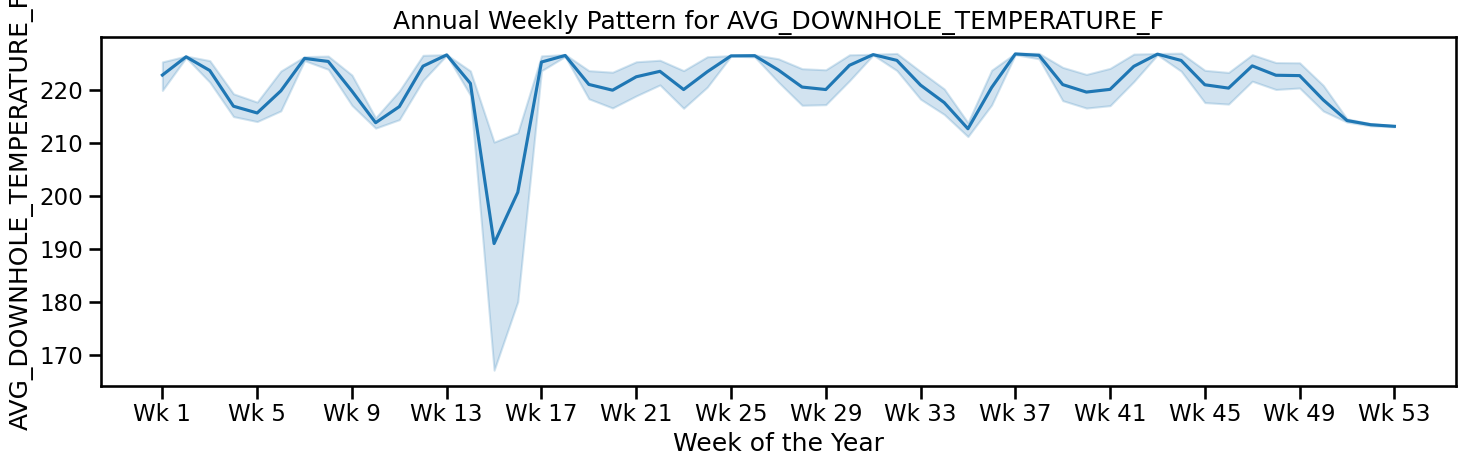

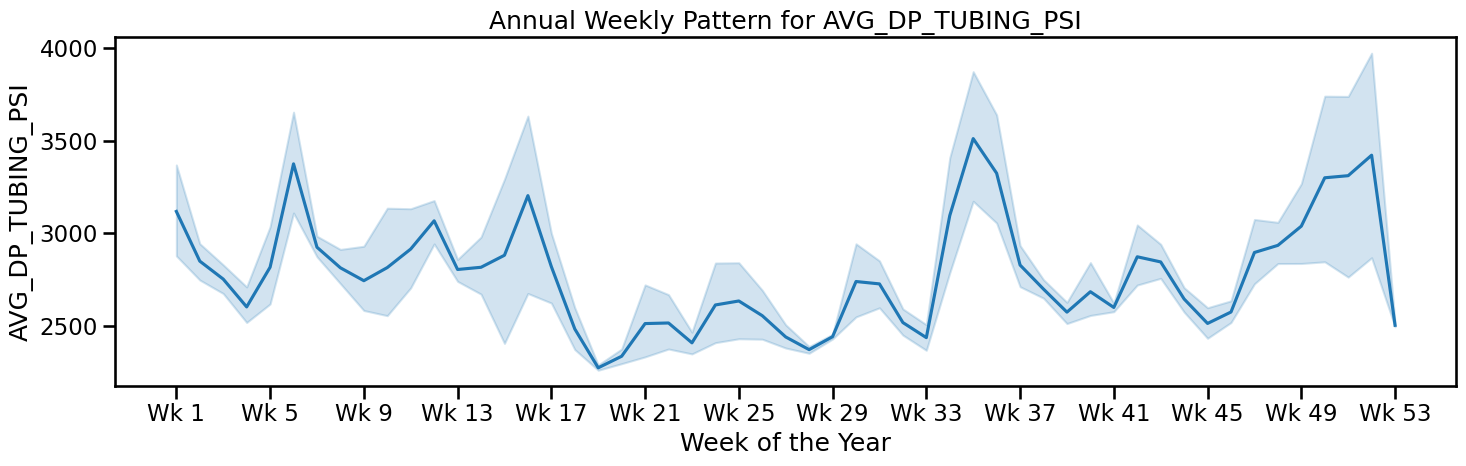

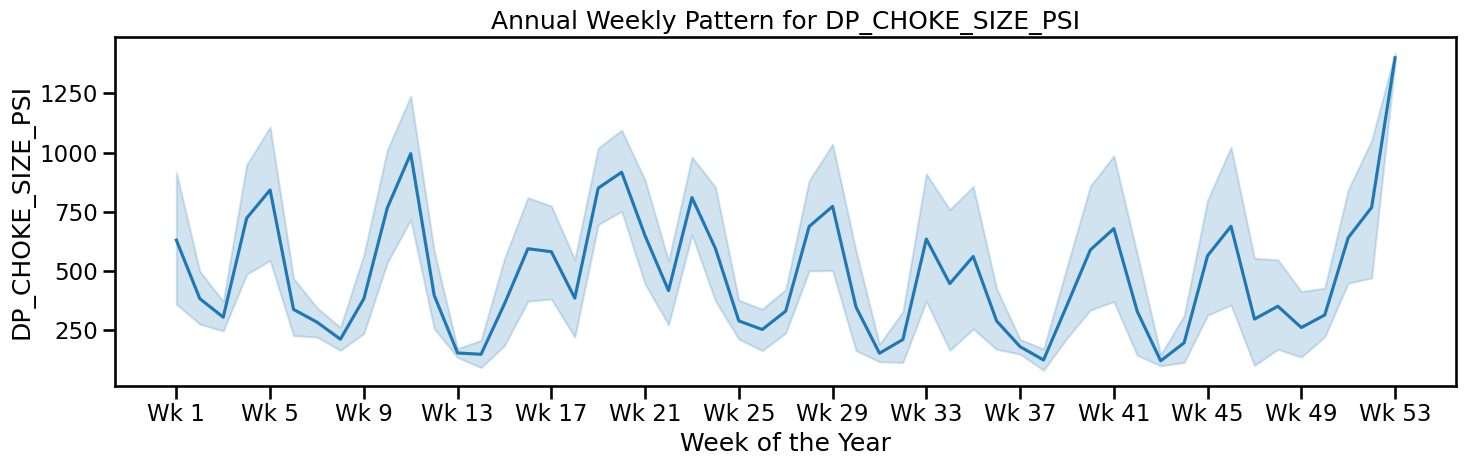

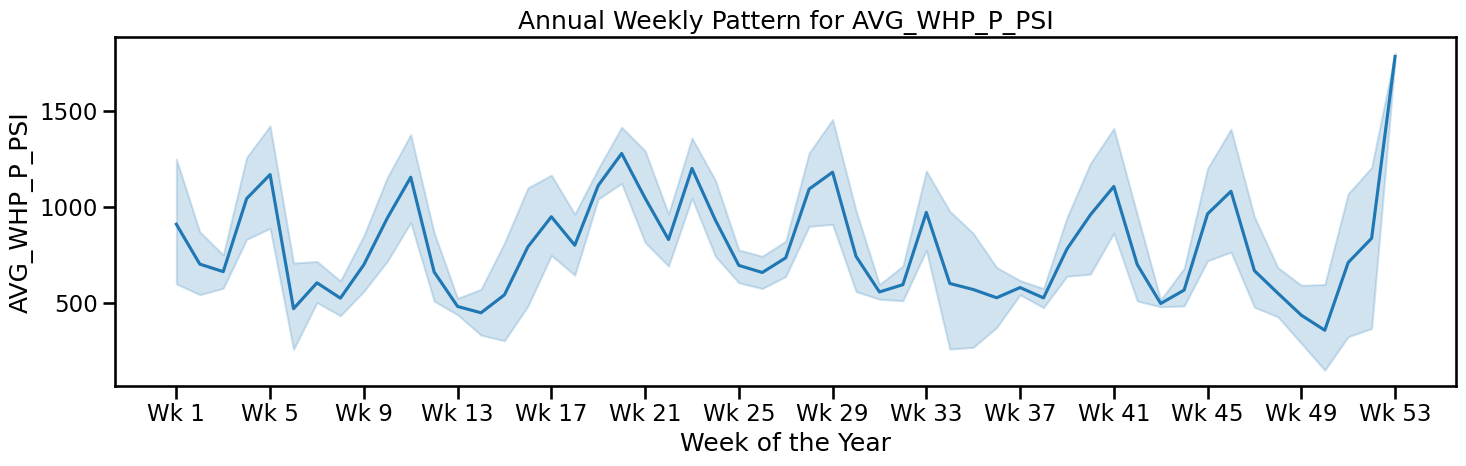

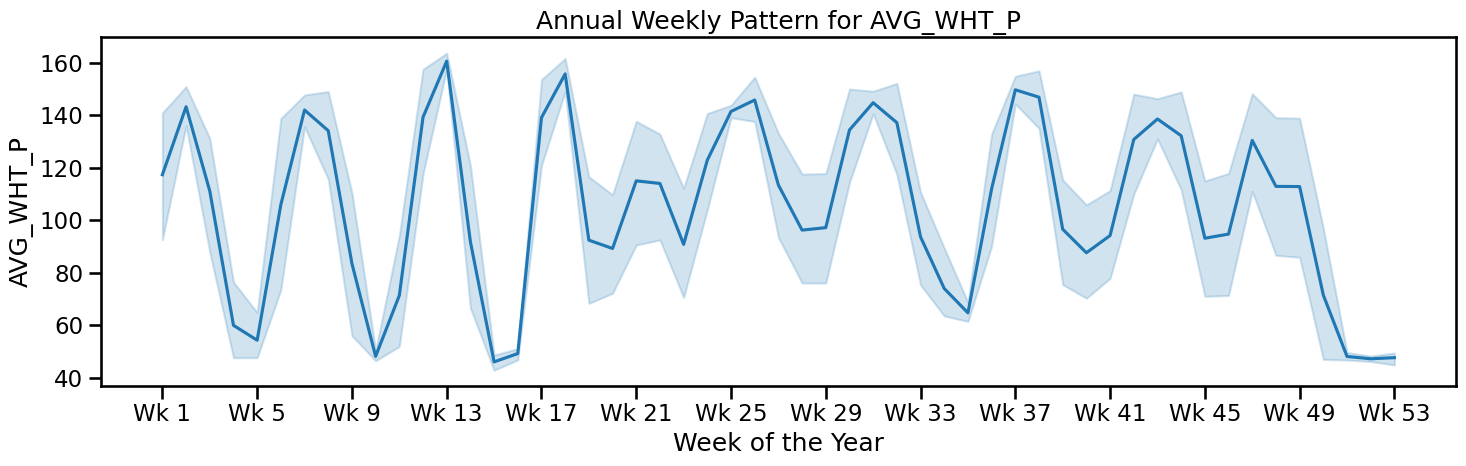

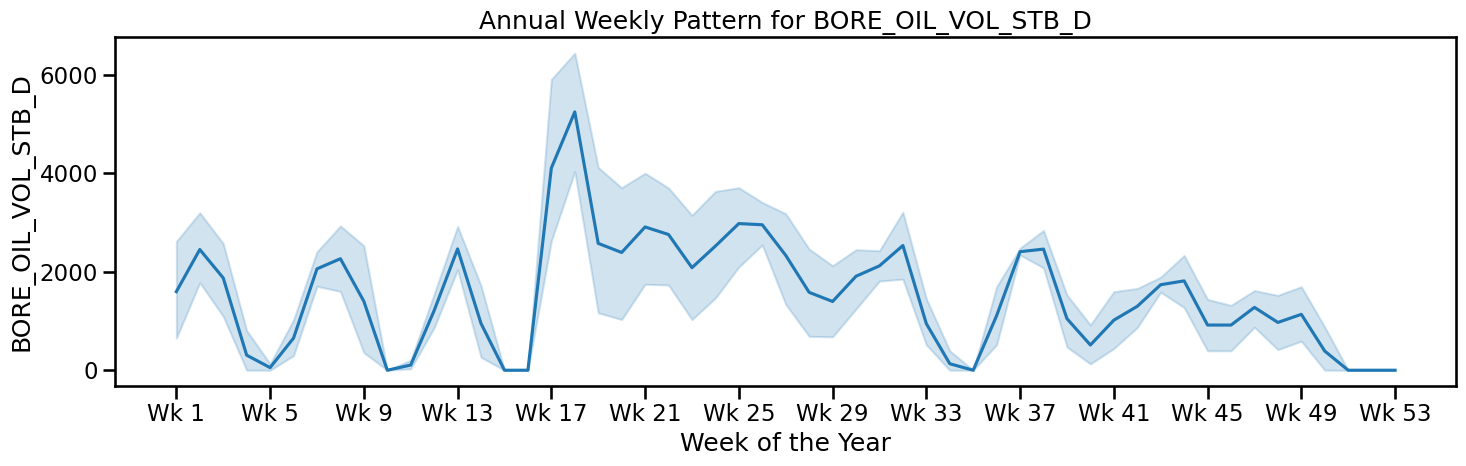

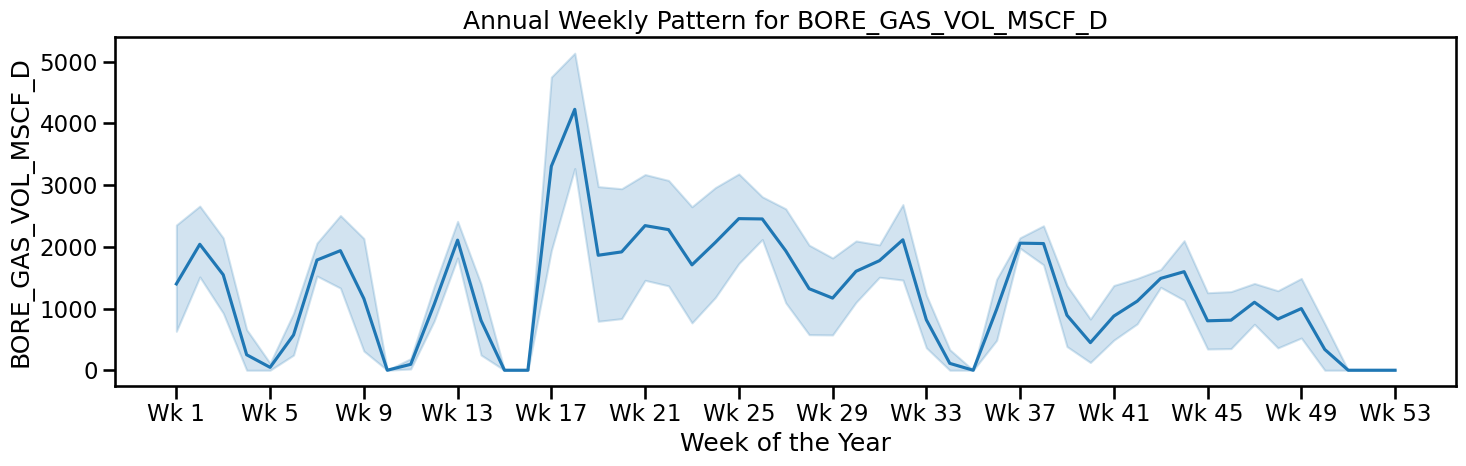

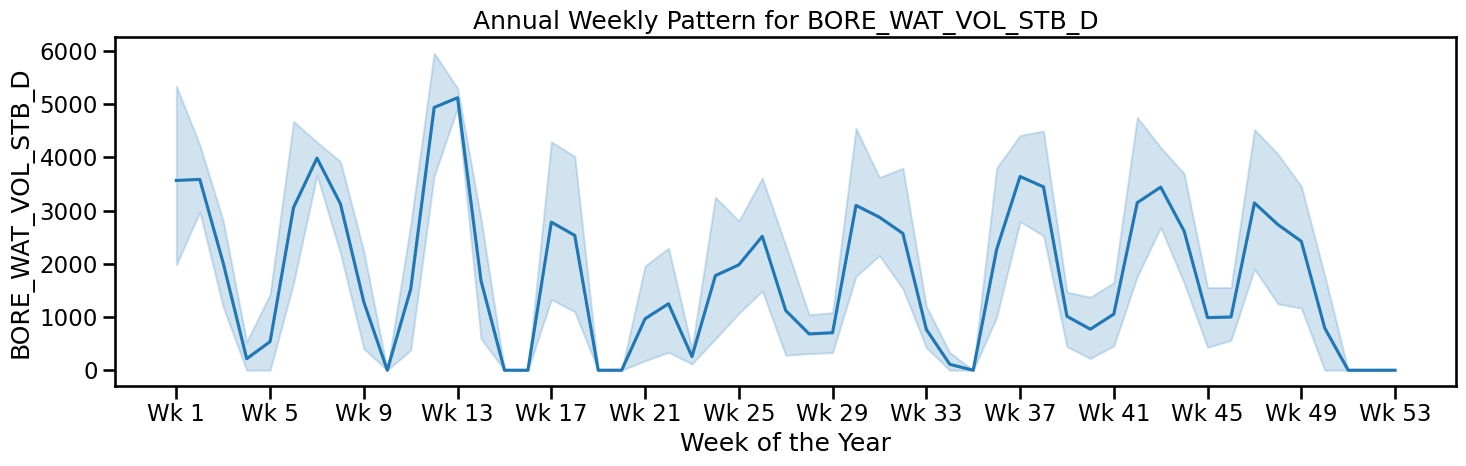

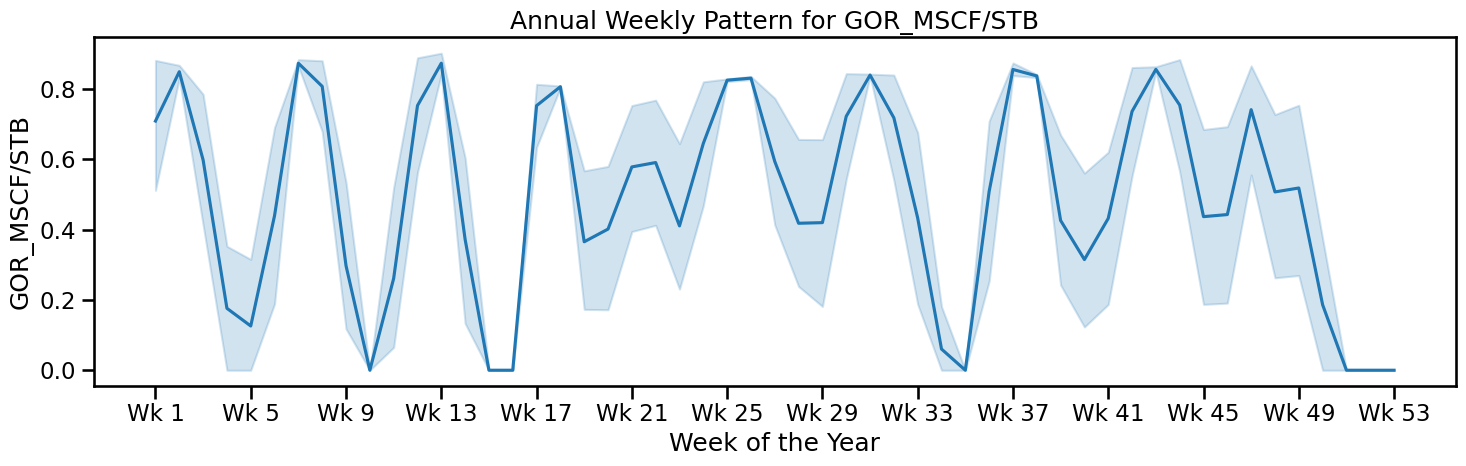

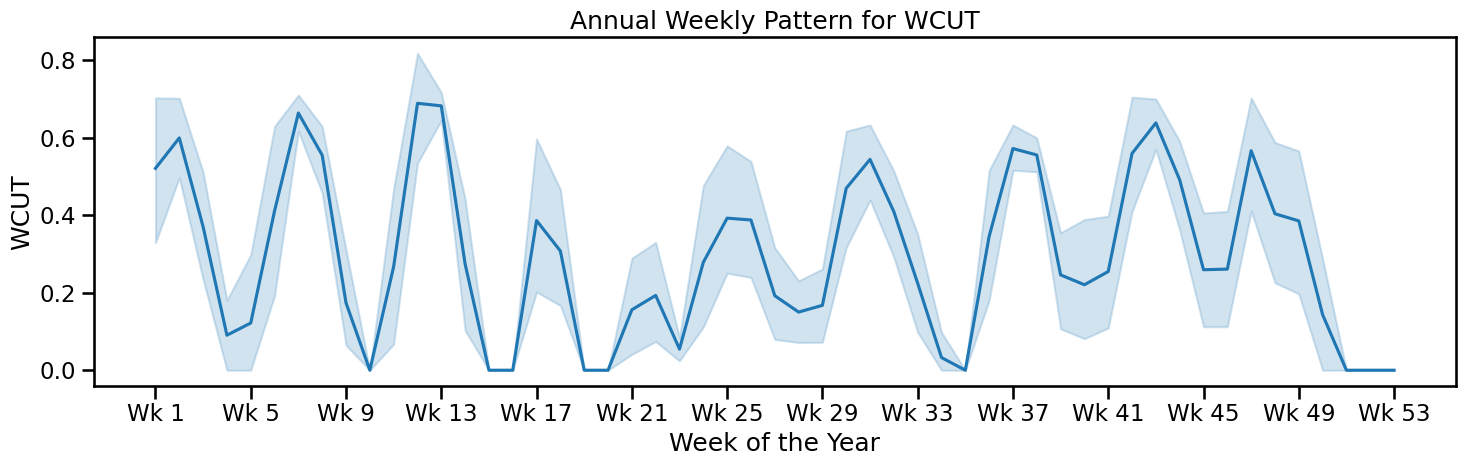

In [25]:
pd.plotting.register_matplotlib_converters()

with sns.plotting_context("talk"):

    for feat in df.columns:
        fig, ax = plt.subplots(figsize=[15, 5])
        
        # 1. Use .isocalendar().week to get week numbers (1 to 52/53)
        sns.lineplot(x=df.index.isocalendar().week, y=df[feat], ax=ax)
        
        # 2. Clean up x-axis: label every 4th week so it's readable
        week_ticks = list(range(1, 54, 4))
        ax.set_xticks(week_ticks)
        ax.set_xticklabels([f"Wk {w}" for w in week_ticks])
        
        ax.set_title(f"Annual Weekly Pattern for {feat}")
        ax.set_xlabel("Week of the Year")
        
        plt.tight_layout()
        plt.show()

There is also a weekly seasonal pattern for the year

### Quater of the year seasonal pattern

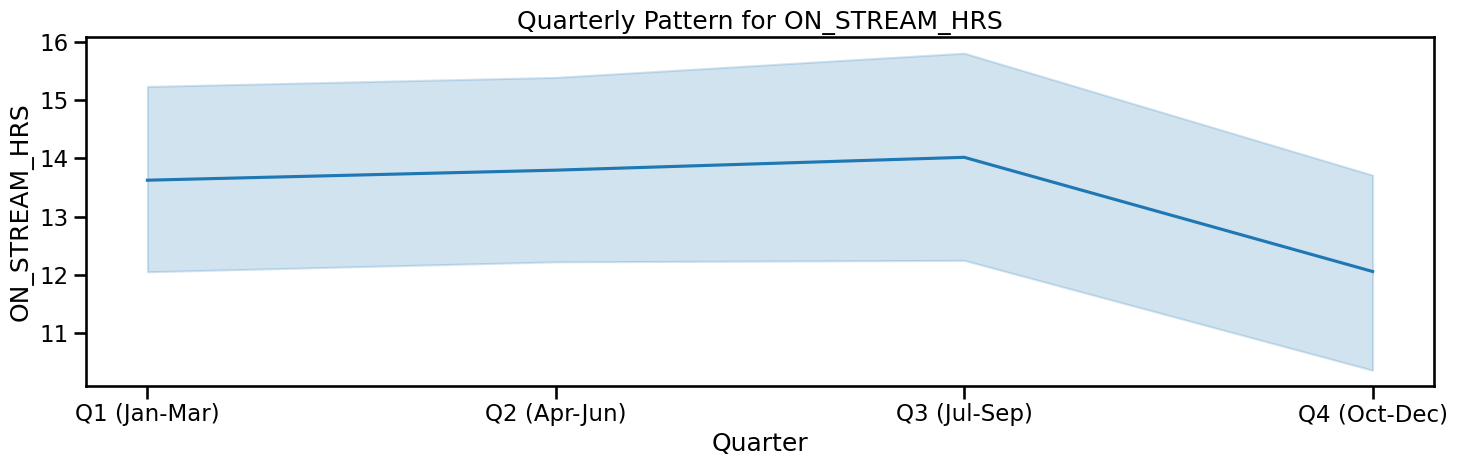

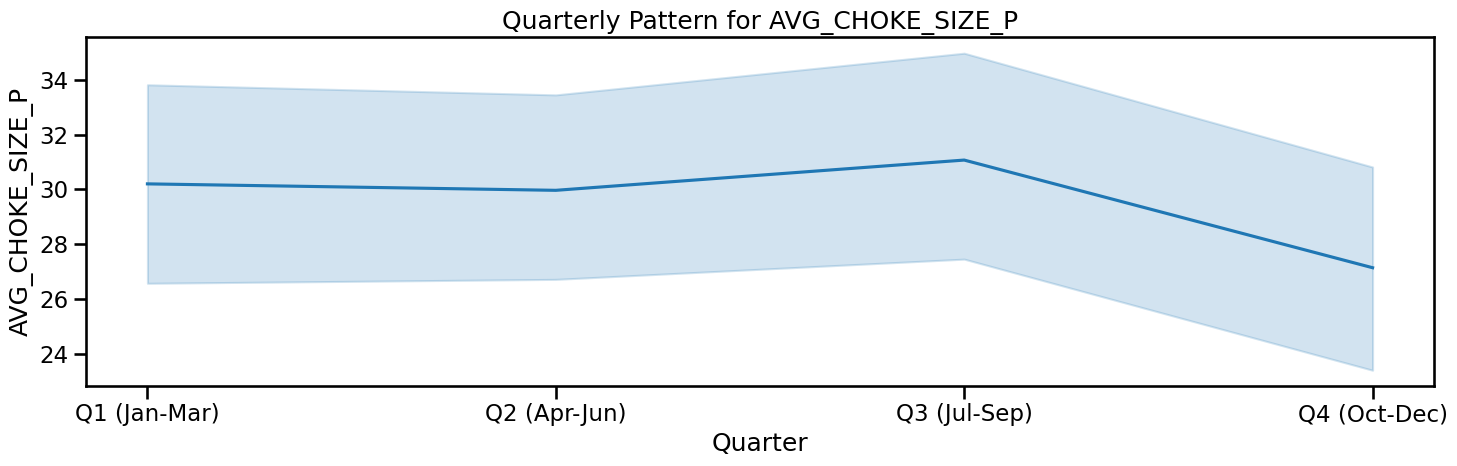

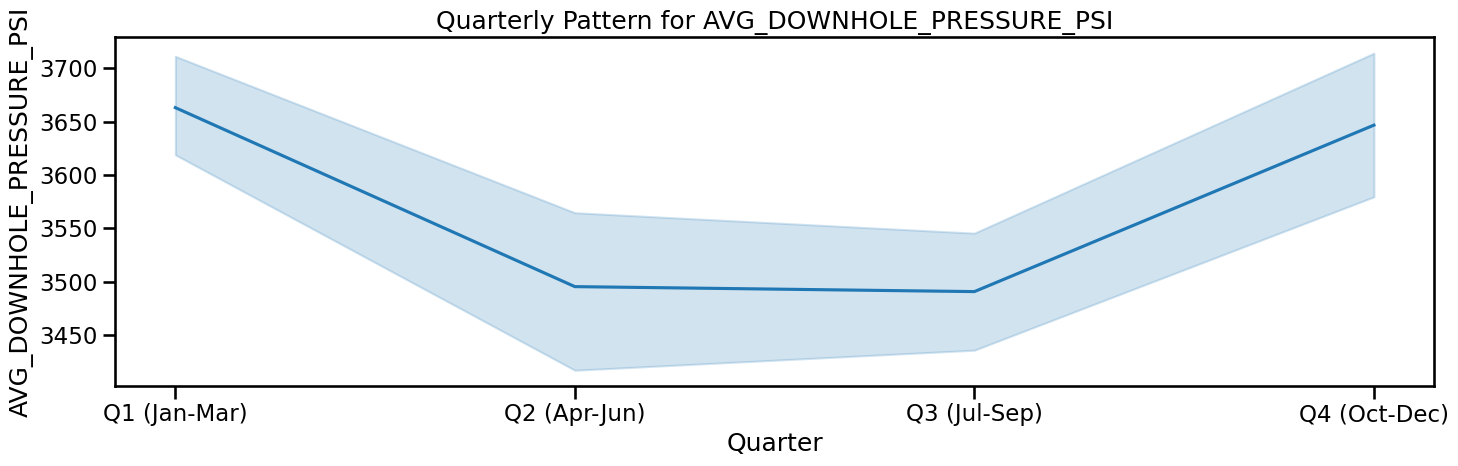

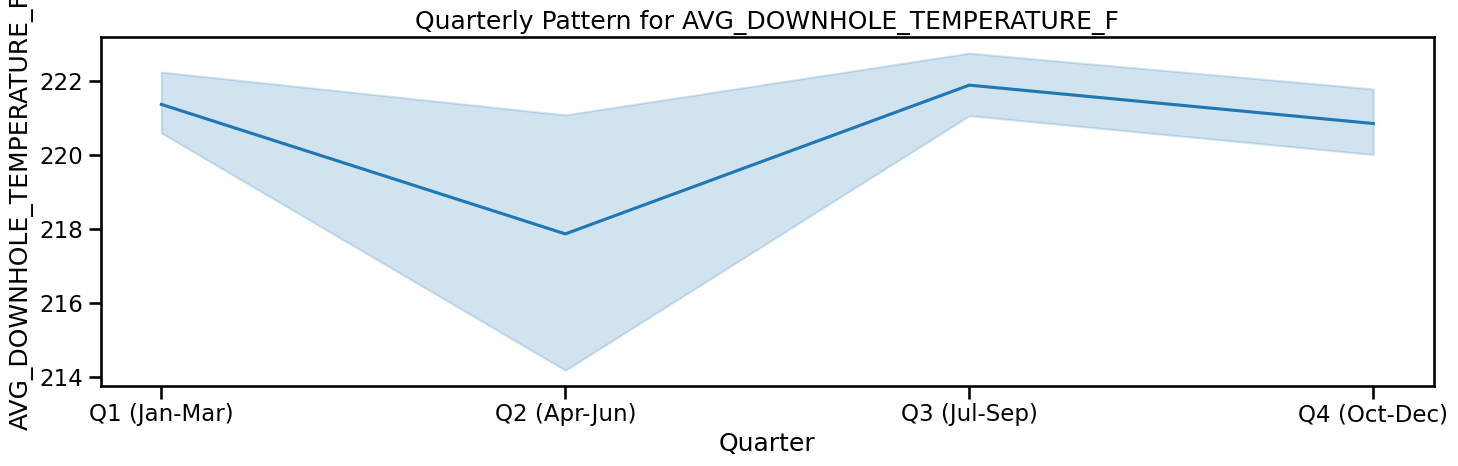

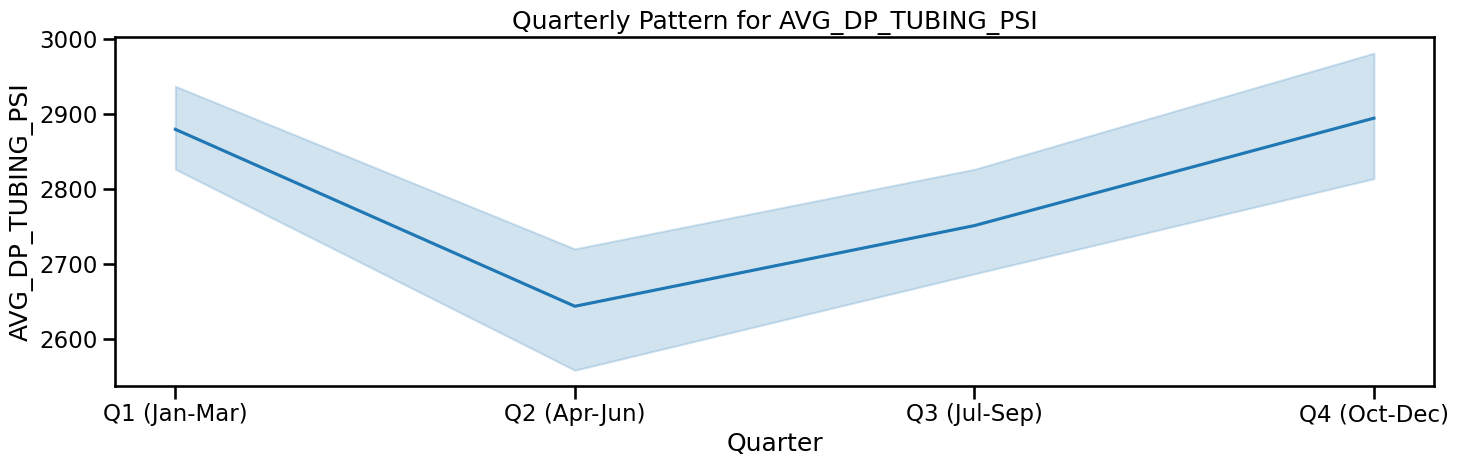

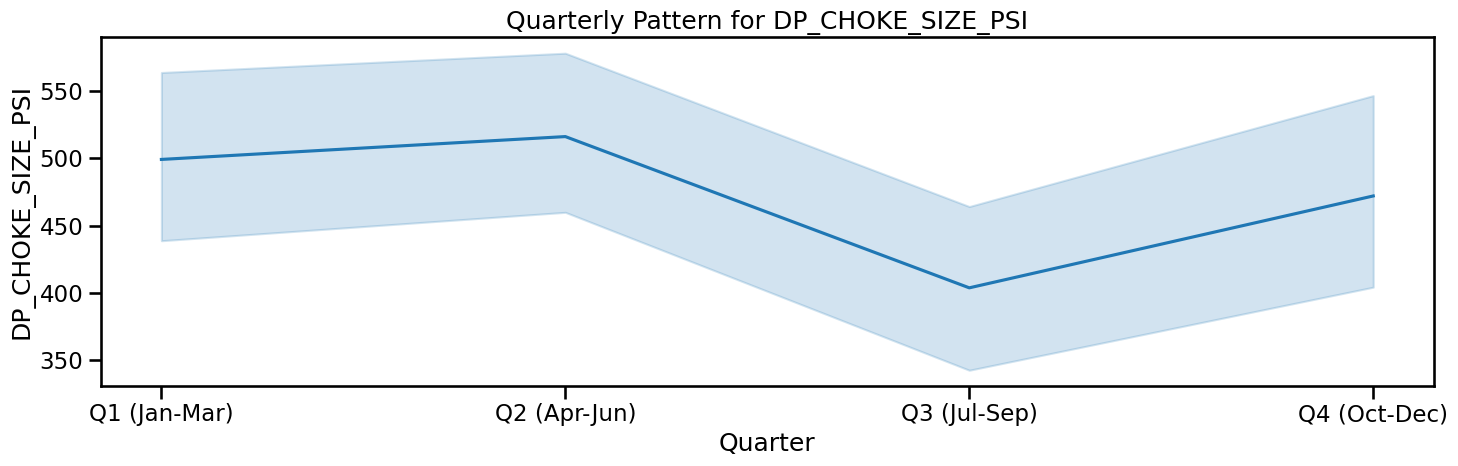

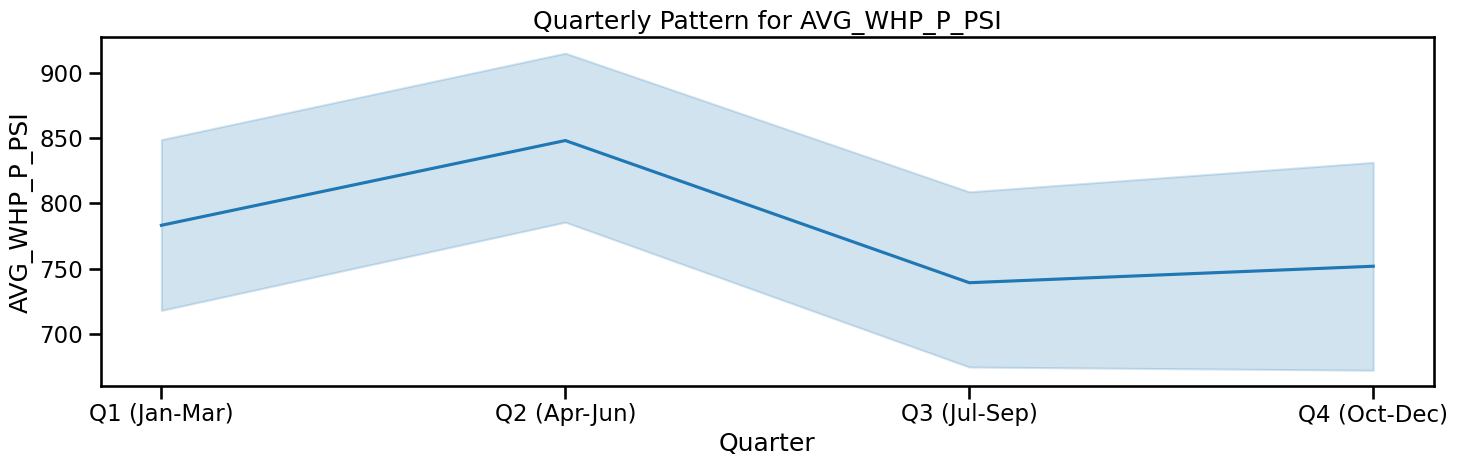

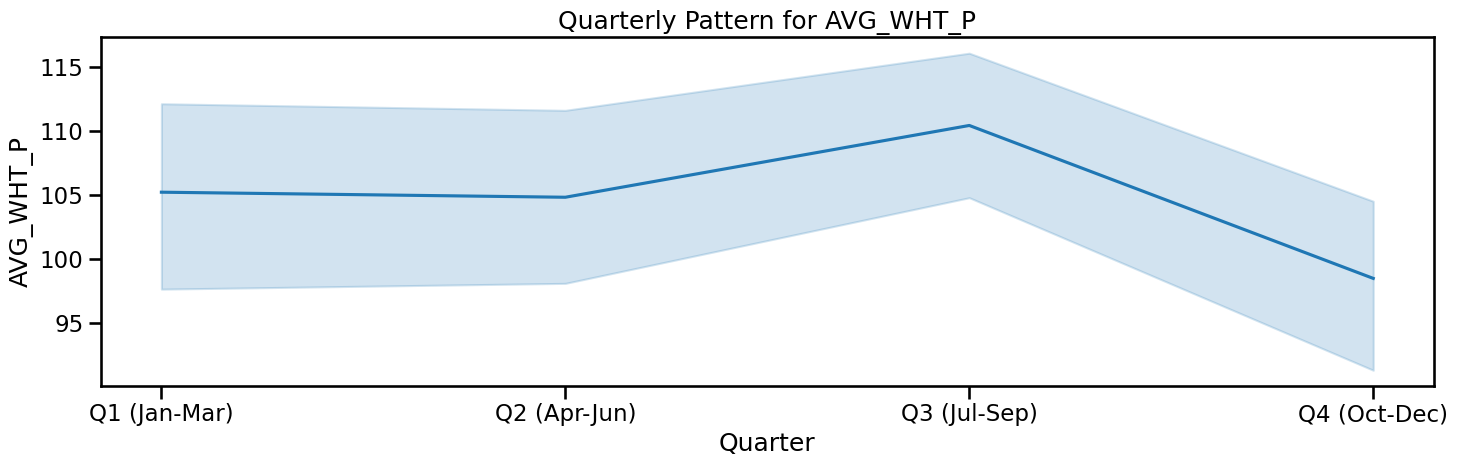

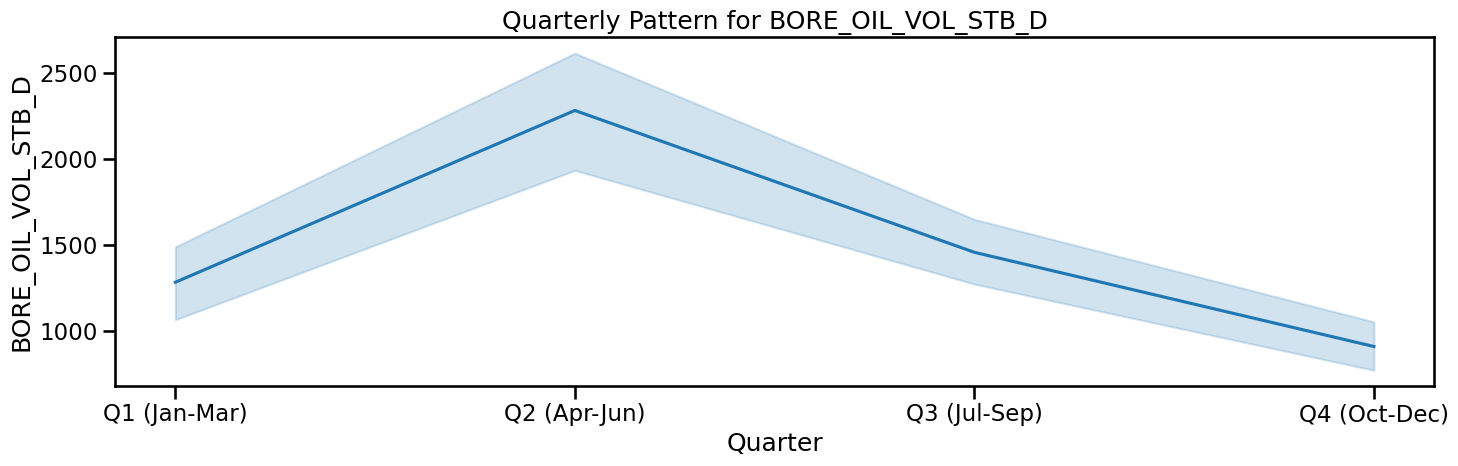

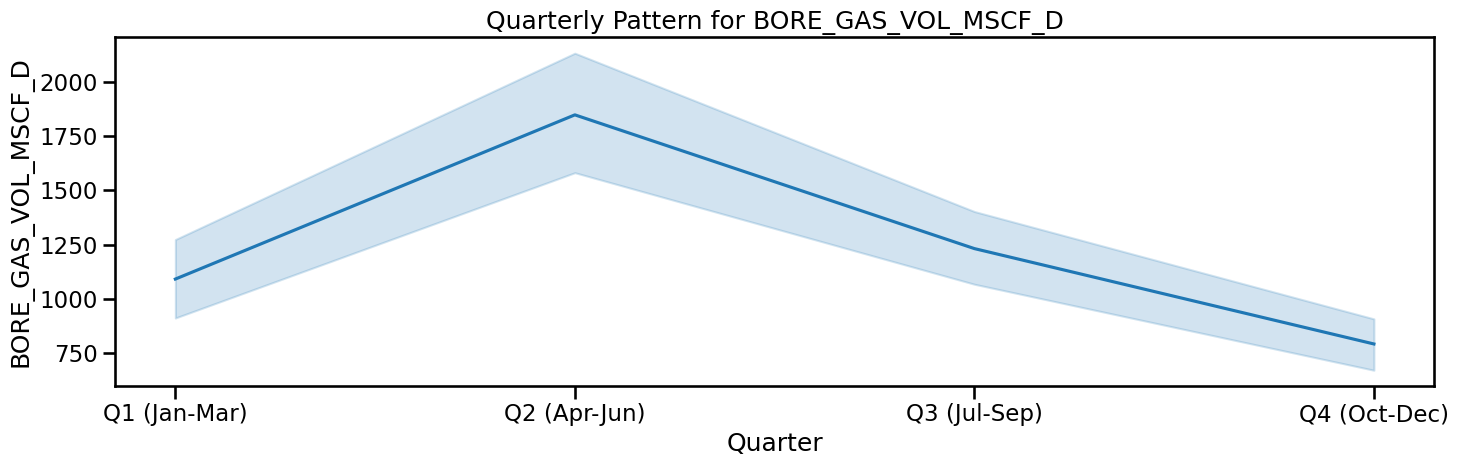

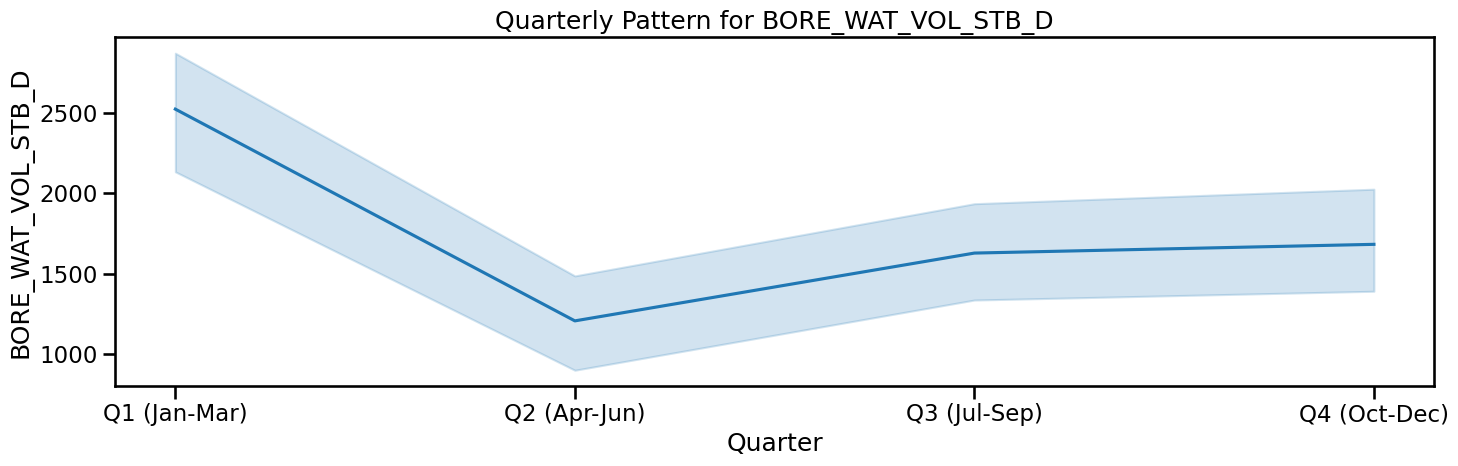

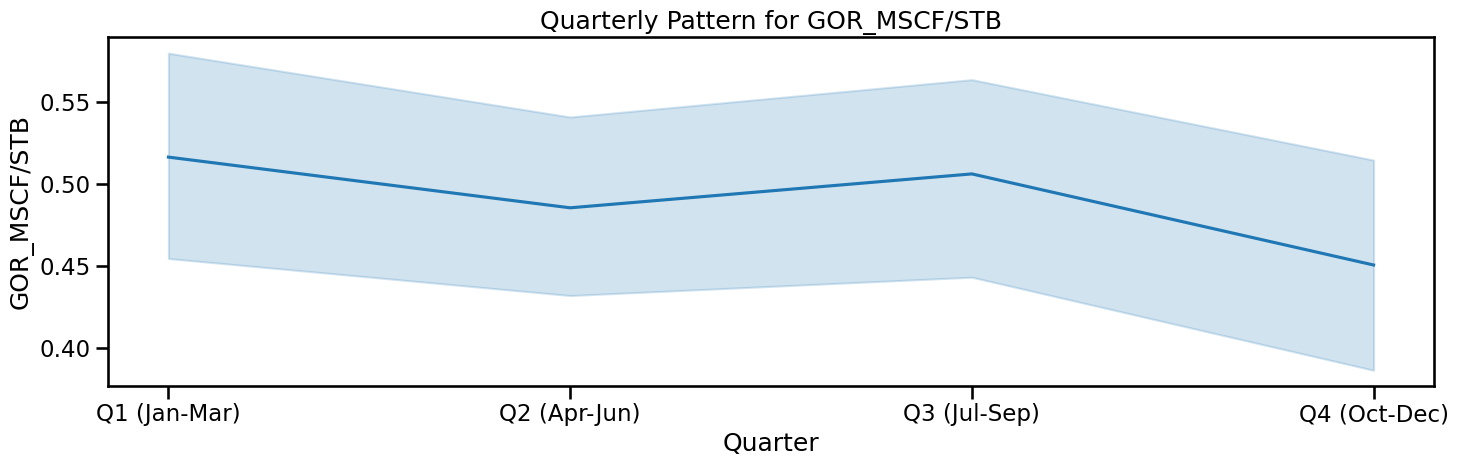

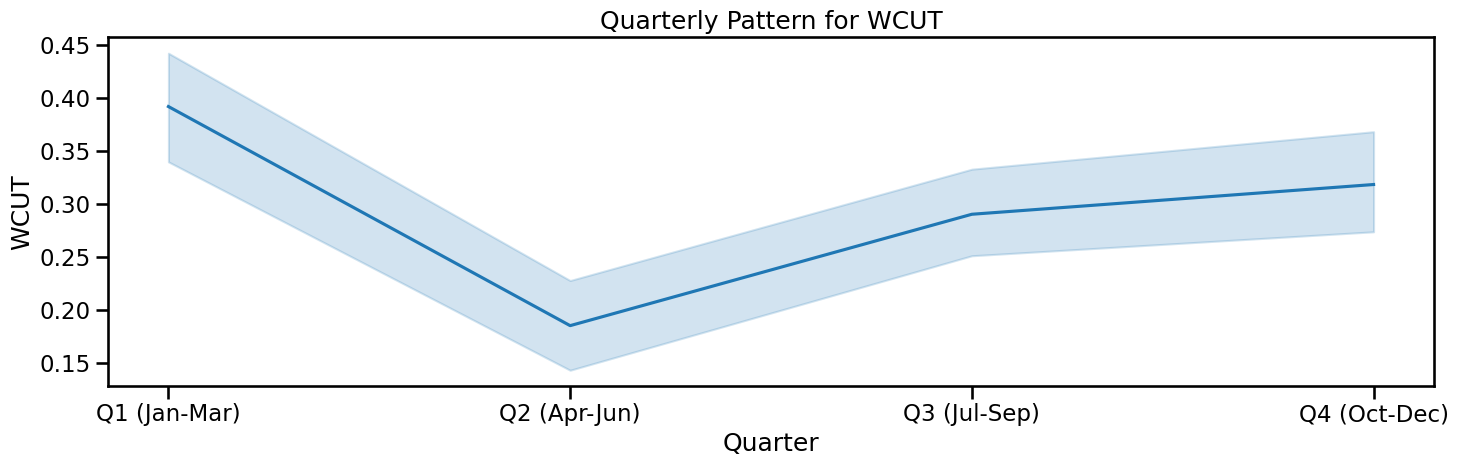

In [26]:

pd.plotting.register_matplotlib_converters()

with sns.plotting_context("talk"):

    for feat in df.columns:
        fig, ax = plt.subplots(figsize=[15, 5])
        
        # 1. Use df.index.quarter to group data into 4 chunks
        sns.lineplot(x=df.index.quarter, y=df[feat], ax=ax)
        
        # 2. Set explicit ticks for the 4 quarters
        ax.set_xticks([1, 2, 3, 4])
        ax.set_xticklabels(['Q1 (Jan-Mar)', 'Q2 (Apr-Jun)', 'Q3 (Jul-Sep)', 'Q4 (Oct-Dec)'])
        
        ax.set_title(f"Quarterly Pattern for {feat}")
        ax.set_xlabel("Quarter")
        
        plt.tight_layout()
        plt.show()

A little but not as much

## 2.2 ACF & PACF To pick lags

I am going to use this to plot the ACF anad PACF and manually pick the lags. and force keep these lags in the lasso selector

In [24]:
df_acf_pacf=df.copy()

In [25]:
df_acf_pacf

,ON_STREAM_HRS,AVG_CHOKE_SIZE_P,AVG_DOWNHOLE_PRESSURE_PSI,AVG_DOWNHOLE_TEMPERATURE_F,AVG_DP_TUBING_PSI,DP_CHOKE_SIZE_PSI,AVG_WHP_P_PSI,AVG_WHT_P,BORE_OIL_VOL_STB_D,BORE_GAS_VOL_MSCF_D,BORE_WAT_VOL_STB_D,GOR_MSCF/STB,WCUT
DATEPRD,,,,,,,,,,,,,
2014-04-07,0.0,0.000000,0.000000,32.000000,0.000000,0.000000,0.000000,32.000000,0.0,0.0,0.0,0.0,0.0
2014-04-08,0.0,1.003059,1125.408365,75.594150,1005.397107,0.000000,0.000000,32.000000,0.0,0.0,0.0,0.0,0.0
2014-04-09,0.0,0.979008,2250.816730,119.188301,2010.794214,0.000000,0.000000,32.000000,0.0,0.0,0.0,0.0,0.0
2014-04-10,0.0,0.545759,3376.225094,162.782451,3016.191321,0.000000,0.000000,32.000000,0.0,0.0,0.0,0.0,0.0
2014-04-11,0.0,1.215987,4501.633459,206.376602,4021.588427,479.668948,480.045032,50.863856,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-04-17,0.0,0.000000,3919.920125,214.156526,3825.672402,38.366612,94.247723,49.644446,0.0,0.0,0.0,0.0,0.0
2016-04-18,0.0,0.000000,4015.651877,214.215836,3816.747199,59.755656,198.904678,53.136032,0.0,0.0,0.0,0.0,0.0
2016-04-19,0.0,0.265188,4091.600010,214.119572,3967.218467,27.068152,124.381543,50.214308,0.0,0.0,0.0,0.0,0.0


### ACF & PACF for oil

#### without removing tend or seasonality

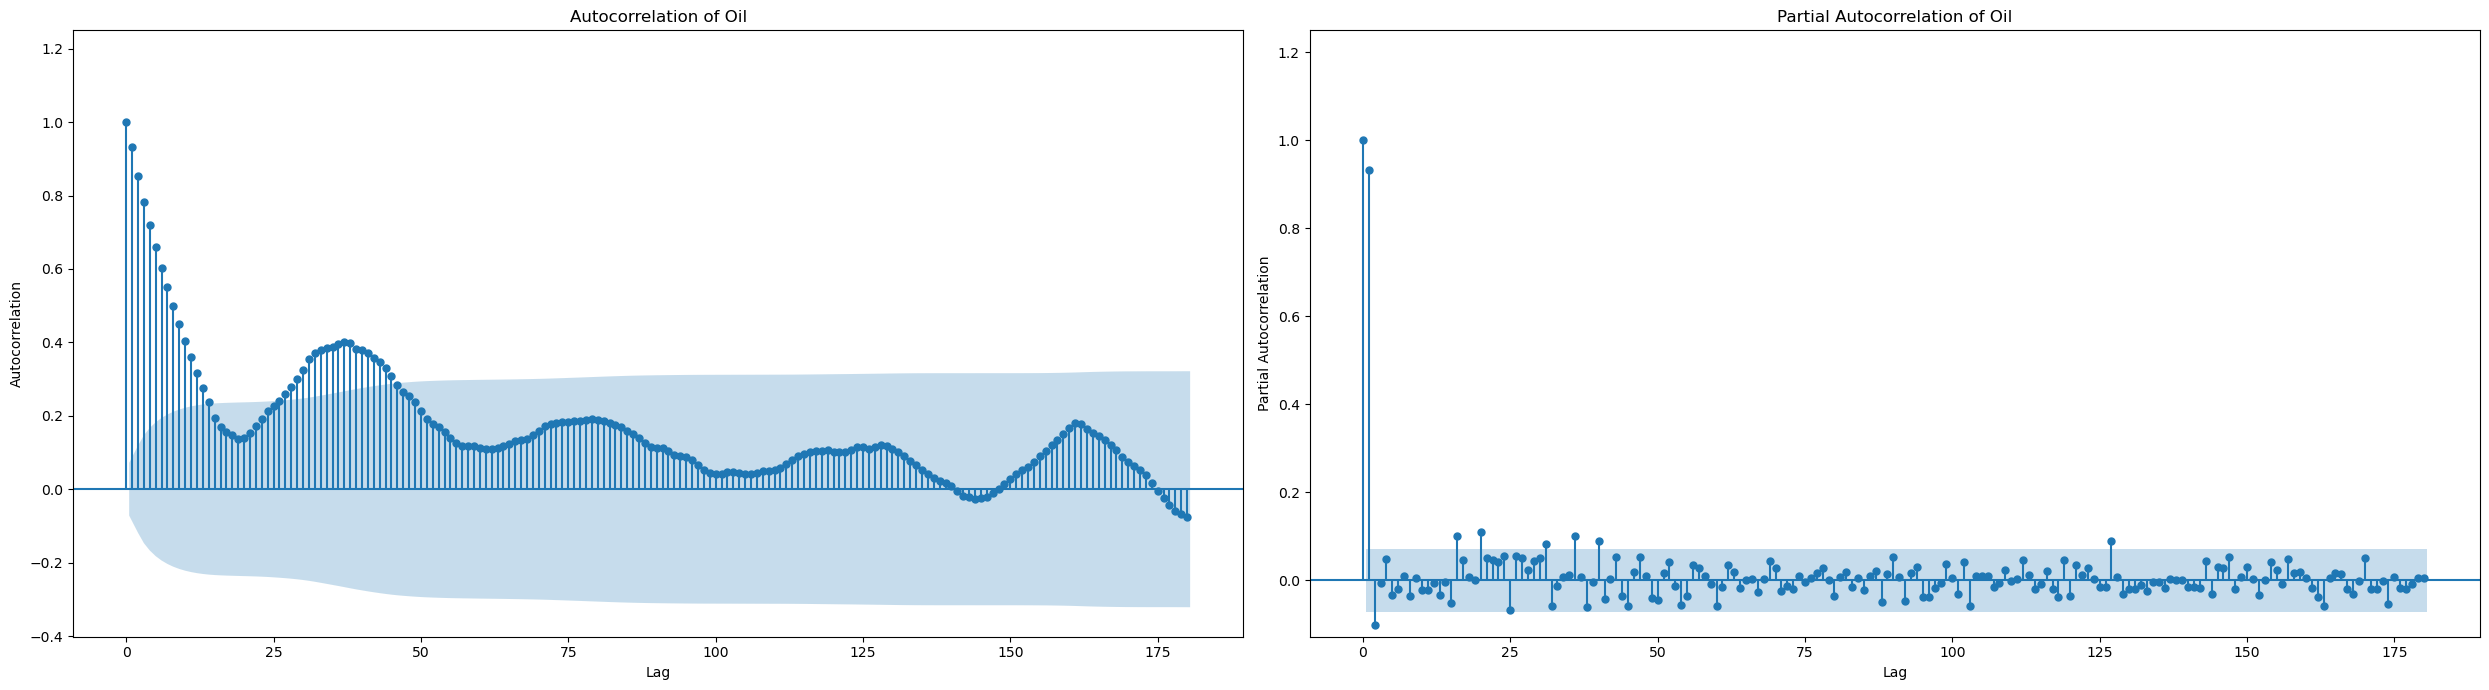

In [29]:

# Create a single figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=[25, 7])

# 1. Plot ACF on the first axis (axes[0])
plot_acf(
    x=df_acf_pacf["BORE_OIL_VOL_STB_D"],
    lags=180,
    ax=axes[0],
    alpha=0.05,
    auto_ylims=True
)
axes[0].set_title("Autocorrelation of Oil")
axes[0].set_ylabel("Autocorrelation")
axes[0].set_xlabel("Lag")

# 2. Plot PACF on the second axis (axes[1])
plot_pacf(
    x=df_acf_pacf["BORE_OIL_VOL_STB_D"],
    method='ywmle', 
    lags=180,
    ax=axes[1],
    alpha=0.05,
    auto_ylims=True
)
axes[1].set_title("Partial Autocorrelation of Oil")
axes[1].set_ylabel("Partial Autocorrelation")
axes[1].set_xlabel("Lag")

# Adjust layout so labels don't overlap
plt.tight_layout()
plt.show()

#### detrend

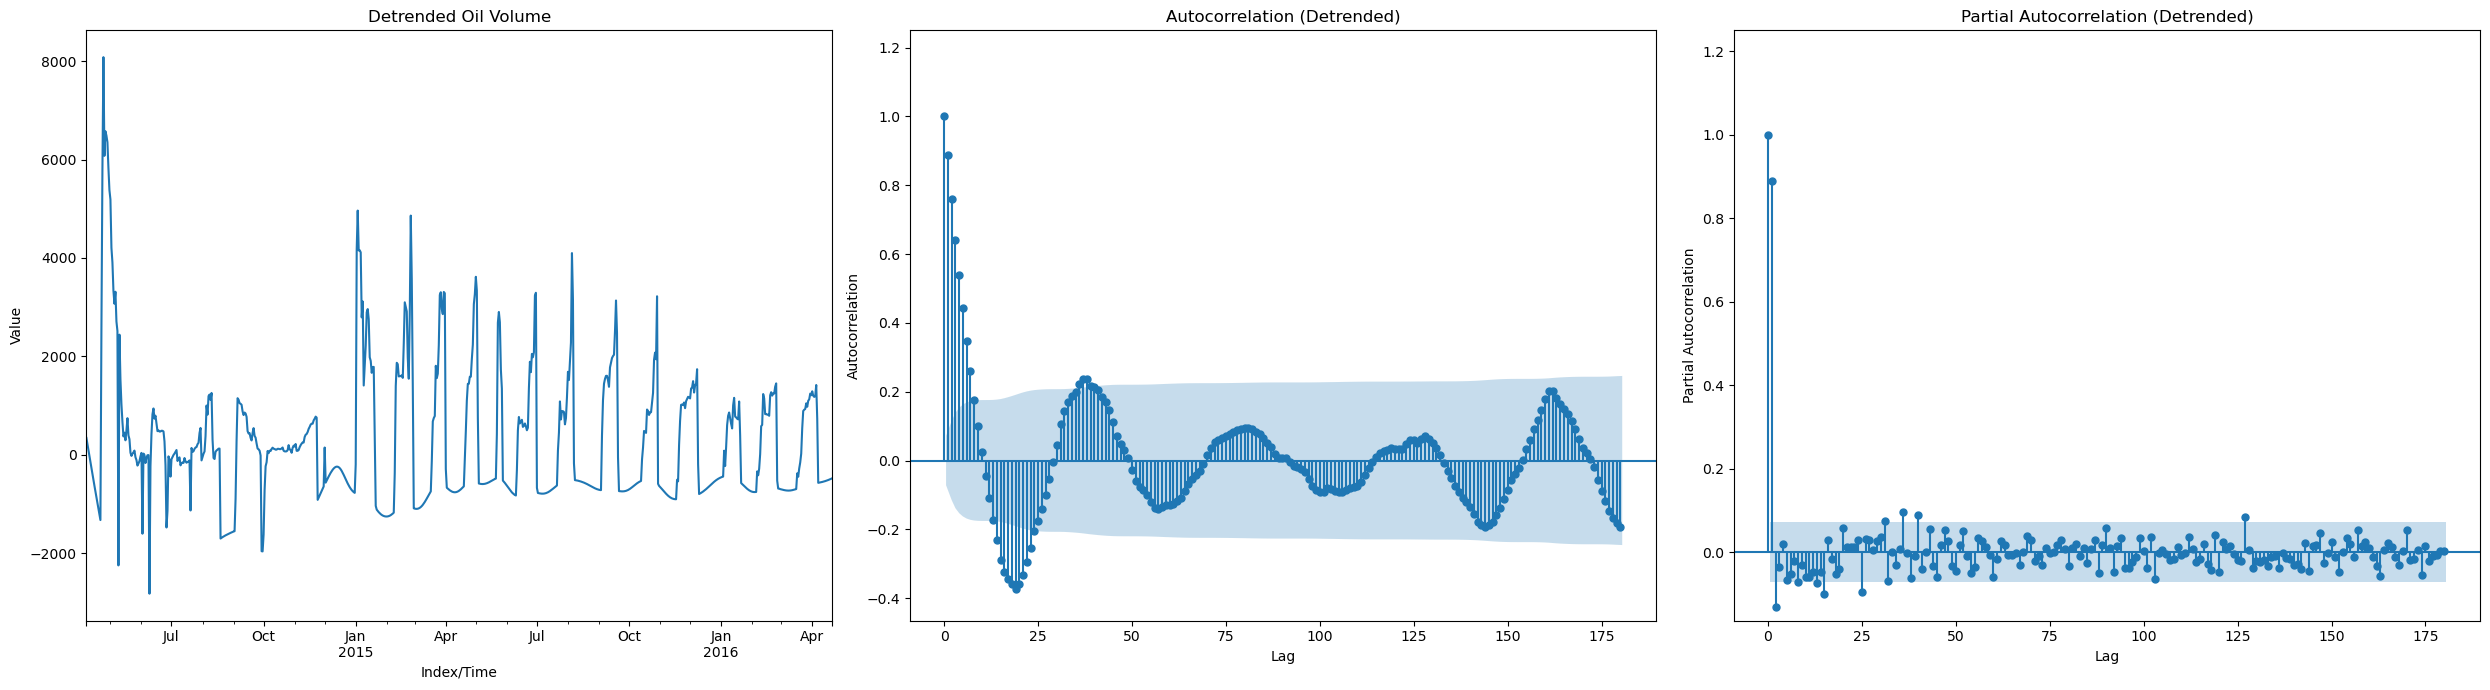

In [30]:
# Compute the trend with LOWESS

# 1. Compute LOWESS and detrend the data
frac = 0.1
y = df_acf_pacf["BORE_OIL_VOL_STB_D"]
x = np.arange(0, len(y))
res = lowess(endog=y, exog=x, frac=frac)
df_acf_pacf["lowess_oil"] = res[:, 1]
df_acf_pacf["y_oil_detrend"] = df_acf_pacf["BORE_OIL_VOL_STB_D"] - df_acf_pacf["lowess_oil"]

# 2. Setup the grid: 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=[25, 7])

# Plot 1: Detrended Time Series
df_acf_pacf["y_oil_detrend"].plot(ax=axes[0], color='tab:blue')
axes[0].set_title("Detrended Oil Volume")
axes[0].set_ylabel("Value")
axes[0].set_xlabel("Index/Time")

# Plot 2: ACF
plot_acf(
    x=df_acf_pacf["y_oil_detrend"],
    lags=180,
    ax=axes[1],
    alpha=0.05,
    auto_ylims=True
)
axes[1].set_title("Autocorrelation (Detrended)")
axes[1].set_ylabel("Autocorrelation")
axes[1].set_xlabel("Lag")

# Plot 3: PACF
plot_pacf(
    x=df_acf_pacf["y_oil_detrend"],
    method='ywmle', 
    lags=180,
    ax=axes[2],
    alpha=0.05,
    auto_ylims=True
)
axes[2].set_title("Partial Autocorrelation (Detrended)")
axes[2].set_ylabel("Partial Autocorrelation")
axes[2].set_xlabel("Lag")

# Adjust spacing and display
plt.tight_layout()
plt.show()

#### detrend and deseason

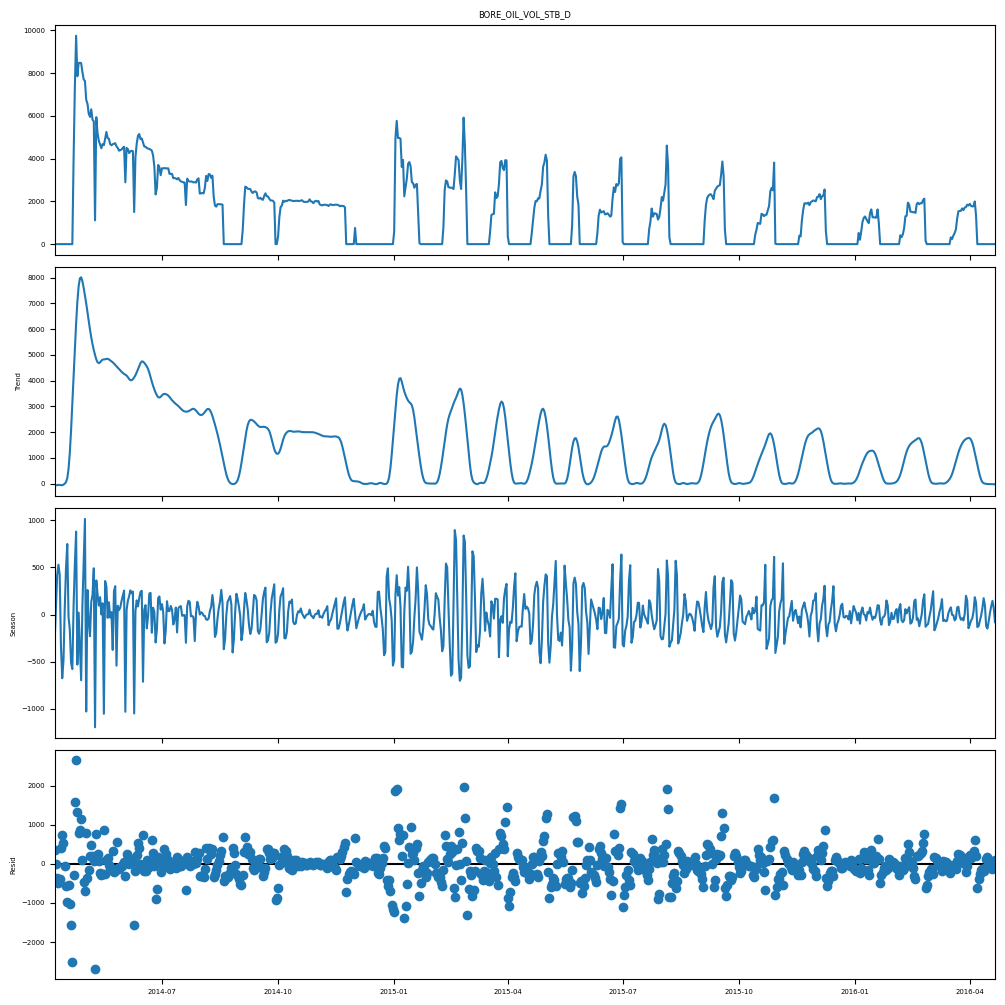

In [32]:
# Break the timeseries into trend, seasonality, and residual components
res_oil = STL(df_acf_pacf["BORE_OIL_VOL_STB_D"]).fit()

# Plot the full decomposition
plt.rc("figure", figsize=(10, 10))
plt.rc("font", size=5)
res_oil.plot();

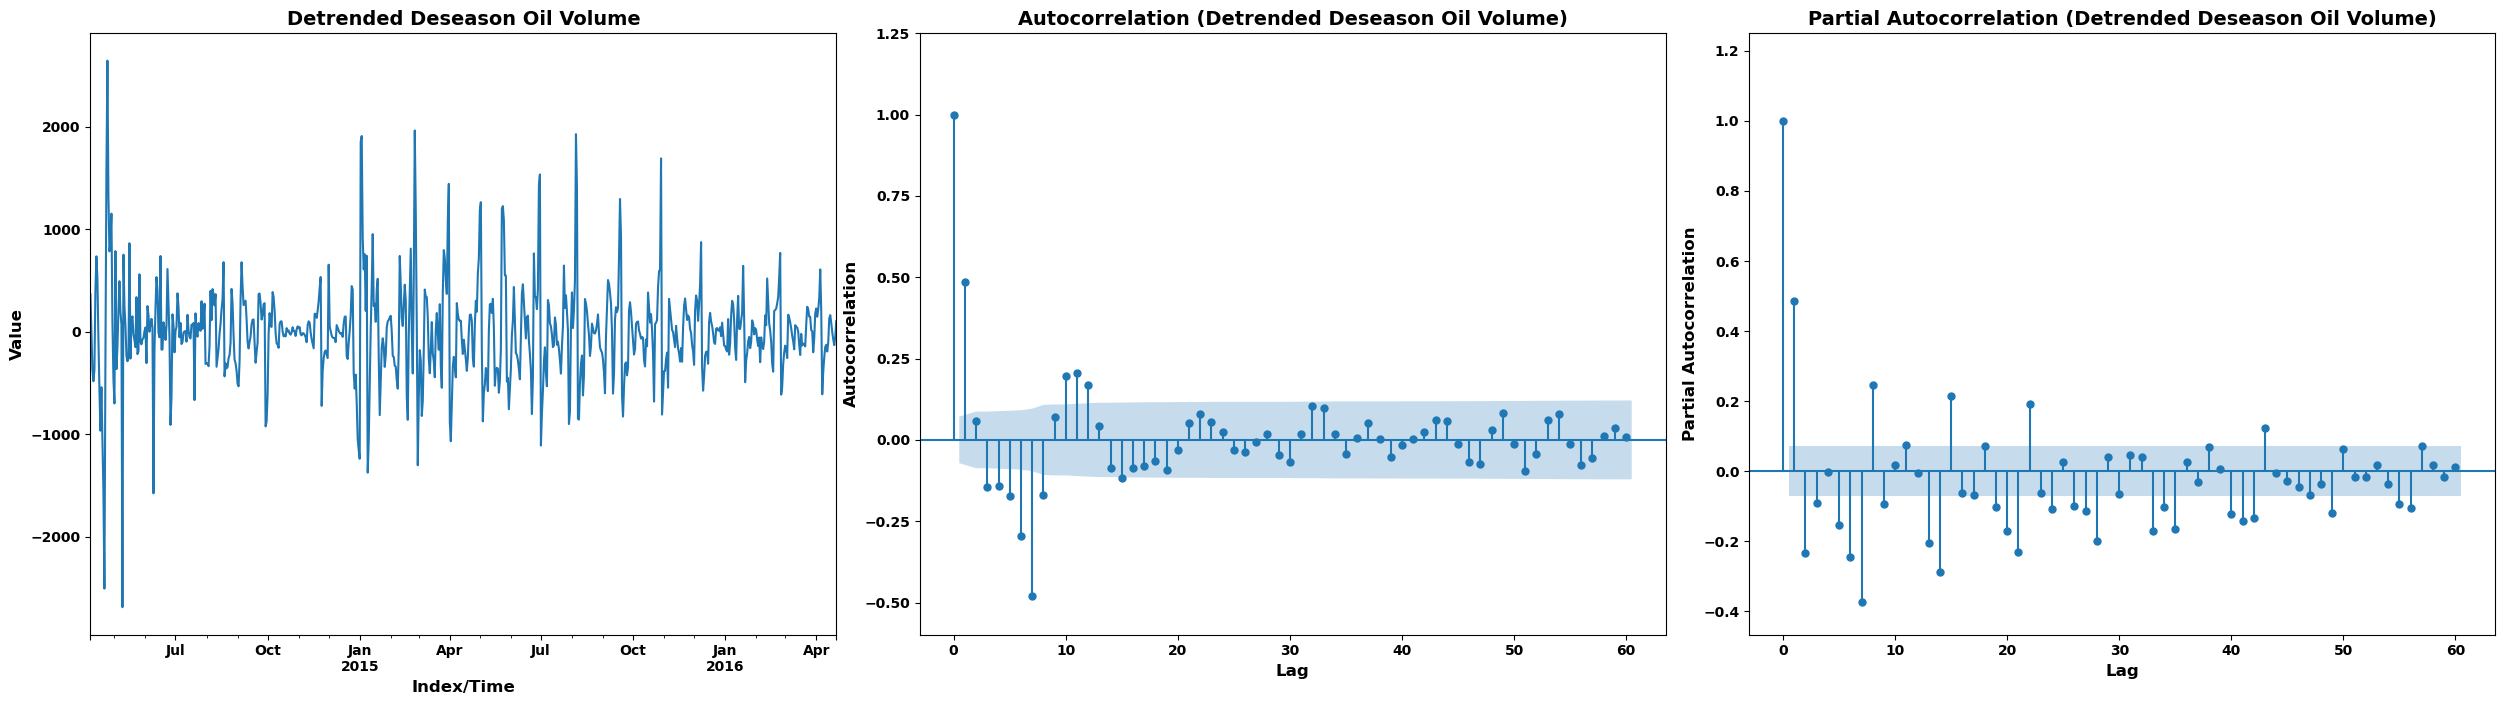

In [152]:
# 2. Setup the grid: 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=[25, 7])

# Plot 1: Detrended Time Series
res_oil.resid.plot(ax=axes[0], color='tab:blue')
axes[0].set_title("Detrended Deseason Oil Volume", weight='bold', fontsize=14)
axes[0].set_ylabel("Value", weight='bold', fontsize=12)
axes[0].set_xlabel("Index/Time", weight='bold', fontsize=12)

# Plot 2: ACF
plot_acf(
    x=res_oil.resid,
    lags=60,
    ax=axes[1],
    alpha=0.05,
    auto_ylims=True
)
axes[1].set_title("Autocorrelation (Detrended Deseason Oil Volume)", weight='bold', fontsize=14)
axes[1].set_ylabel("Autocorrelation", weight='bold', fontsize=12)
axes[1].set_xlabel("Lag", weight='bold', fontsize=12)

# Plot 3: PACF
plot_pacf(
    x=res_oil.resid,
    method='ywmle', 
    lags=60,
    ax=axes[2],
    alpha=0.05,
    auto_ylims=True
)
axes[2].set_title("Partial Autocorrelation (Detrended Deseason Oil Volume)", weight='bold', fontsize=14)
axes[2].set_ylabel("Partial Autocorrelation", weight='bold', fontsize=12)
axes[2].set_xlabel("Lag", weight='bold', fontsize=12)

# Loop through all axes to bold the tick numbers correctly
for ax in axes:
    # Set the size via tick_params safely
    ax.tick_params(axis='both', which='major', labelsize=10)
    
    # Bold the X axis tick labels
    for label in ax.get_xticklabels():
        label.set_weight('bold')
        
    # Bold the Y axis tick labels
    for label in ax.get_yticklabels():
        label.set_weight('bold')

# Adjust spacing and display
plt.tight_layout()
plt.show()

#### Final comments

after removing the trend and the season, i should use a Lag of 1,2,6,7

### ACF & PACF for gas

#### without removing tend or seasonality

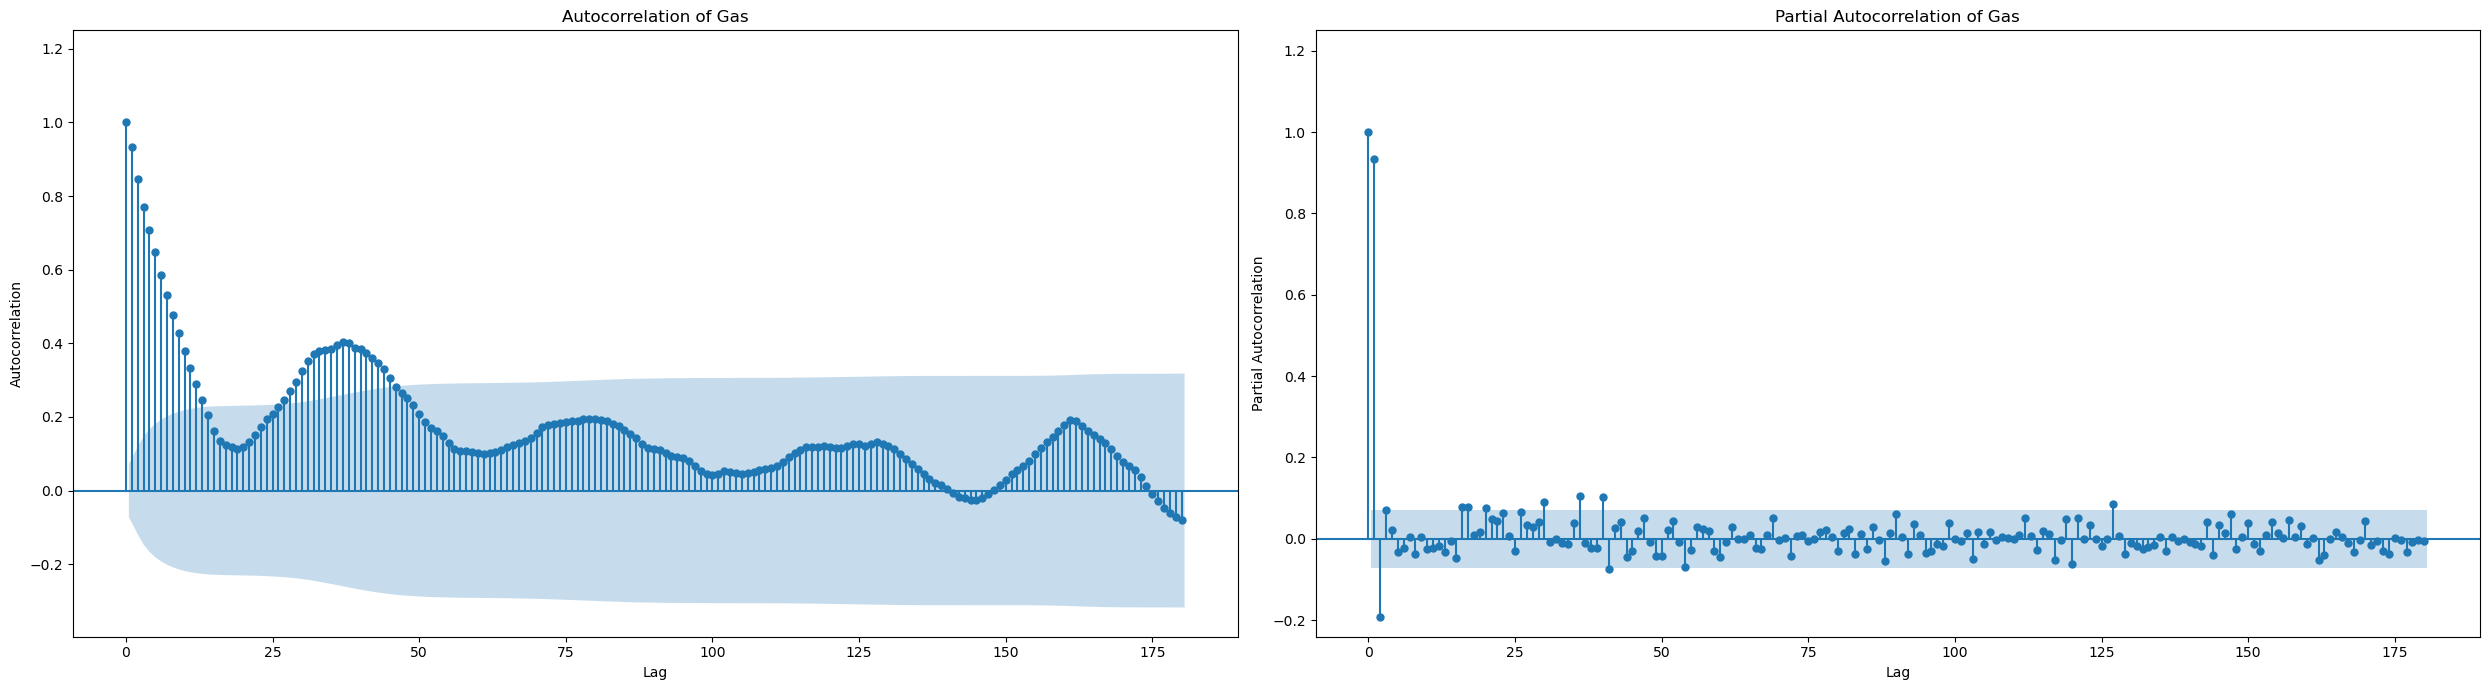

In [25]:

# Create a single figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=[25, 7])

# 1. Plot ACF on the first axis (axes[0])
plot_acf(
    x=df_acf_pacf["BORE_GAS_VOL_MSCF_D"],
    lags=180,
    ax=axes[0],
    alpha=0.05,
    auto_ylims=True
)
axes[0].set_title("Autocorrelation of Gas")
axes[0].set_ylabel("Autocorrelation")
axes[0].set_xlabel("Lag")

# 2. Plot PACF on the second axis (axes[1])
plot_pacf(
    x=df_acf_pacf["BORE_GAS_VOL_MSCF_D"],
    method='ywmle', 
    lags=180,
    ax=axes[1],
    alpha=0.05,
    auto_ylims=True
)
axes[1].set_title("Partial Autocorrelation of Gas")
axes[1].set_ylabel("Partial Autocorrelation")
axes[1].set_xlabel("Lag")

# Adjust layout so labels don't overlap
plt.tight_layout()
plt.show()

#### detrend

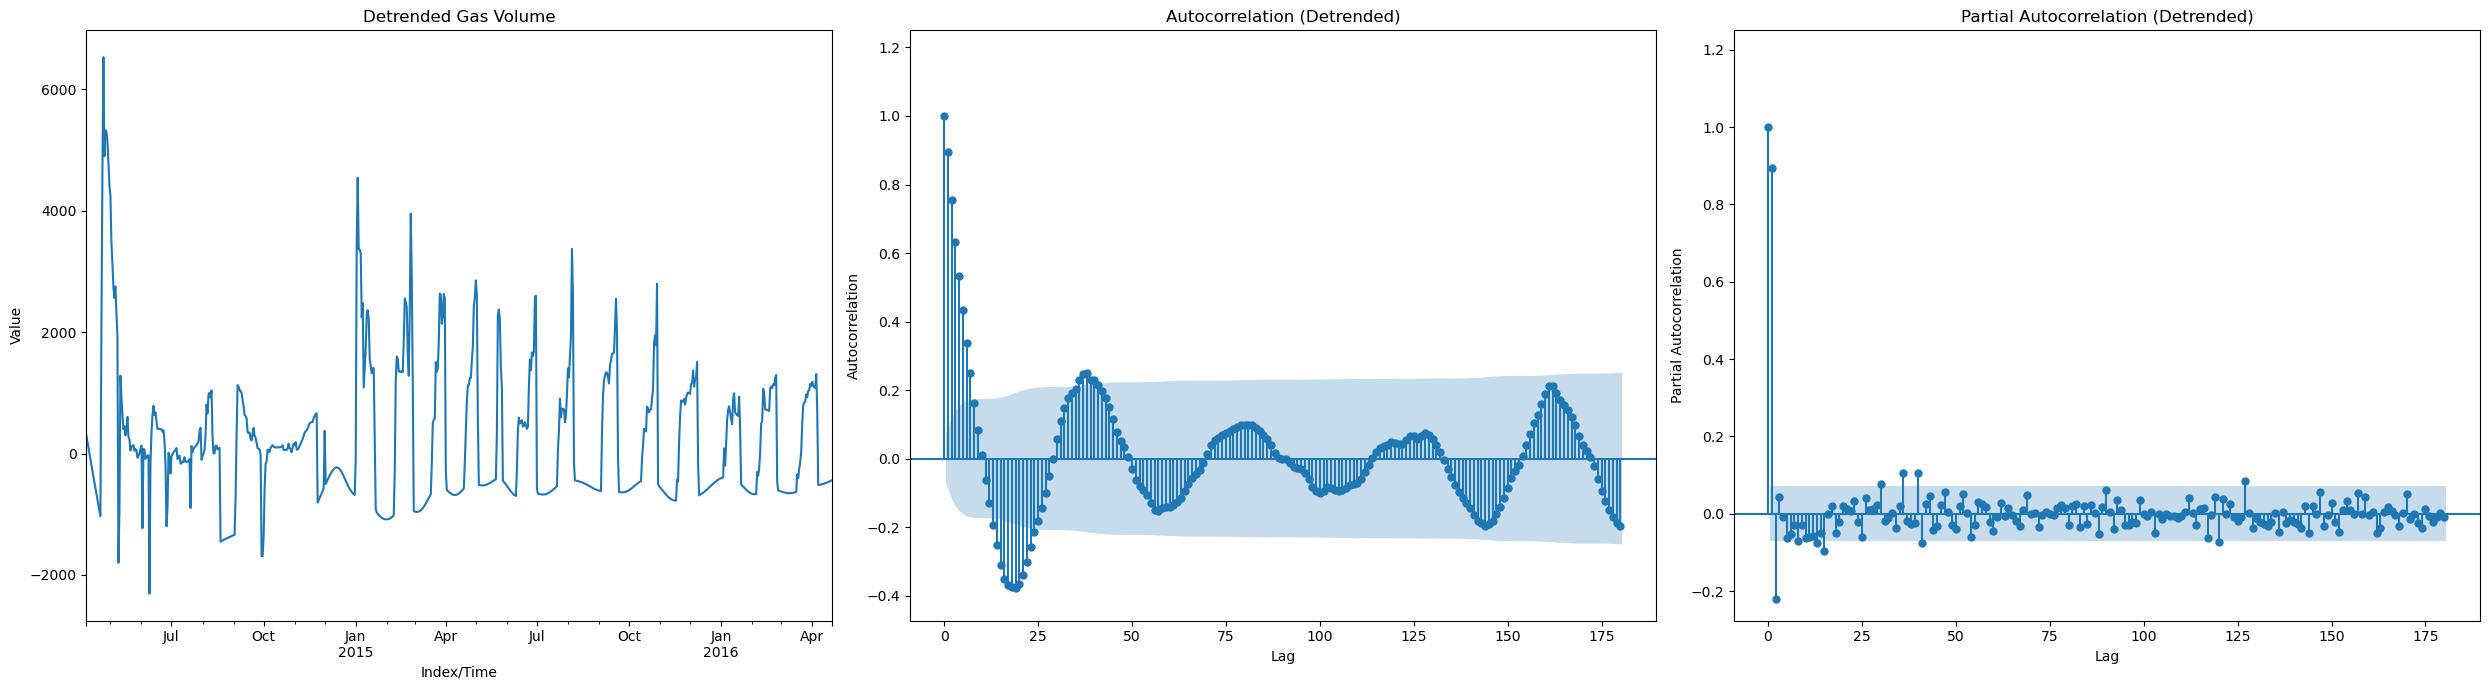

In [26]:
# Compute the trend with LOWESS

# 1. Compute LOWESS and detrend the data
frac = 0.1
y = df_acf_pacf["BORE_GAS_VOL_MSCF_D"]
x = np.arange(0, len(y))
res = lowess(endog=y, exog=x, frac=frac)
df_acf_pacf["lowess_gas"] = res[:, 1]
df_acf_pacf["y_gas_detrend"] = df_acf_pacf["BORE_GAS_VOL_MSCF_D"] - df_acf_pacf["lowess_gas"]

# 2. Setup the grid: 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=[25, 7])

# Plot 1: Detrended Time Series
df_acf_pacf["y_gas_detrend"].plot(ax=axes[0], color='tab:blue')
axes[0].set_title("Detrended Gas Volume")
axes[0].set_ylabel("Value")
axes[0].set_xlabel("Index/Time")

# Plot 2: ACF
plot_acf(
    x=df_acf_pacf["y_gas_detrend"],
    lags=180,
    ax=axes[1],
    alpha=0.05,
    auto_ylims=True
)
axes[1].set_title("Autocorrelation (Detrended)")
axes[1].set_ylabel("Autocorrelation")
axes[1].set_xlabel("Lag")

# Plot 3: PACF
plot_pacf(
    x=df_acf_pacf["y_gas_detrend"],
    method='ywmle', 
    lags=180,
    ax=axes[2],
    alpha=0.05,
    auto_ylims=True
)
axes[2].set_title("Partial Autocorrelation (Detrended)")
axes[2].set_ylabel("Partial Autocorrelation")
axes[2].set_xlabel("Lag")

# Adjust spacing and display
plt.tight_layout()
plt.show()

#### detrend and deseason

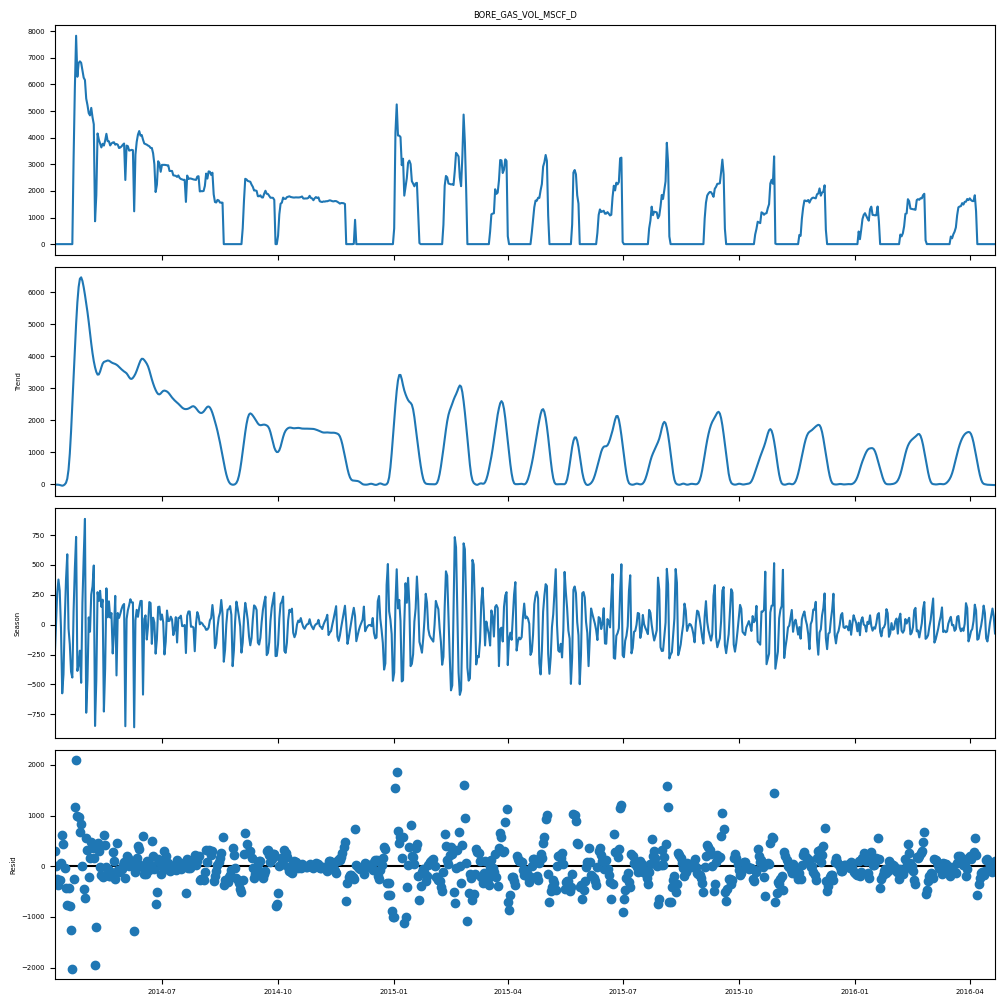

In [31]:
# Break the timeseries into trend, seasonality, and residual components
res_gas = STL(df_acf_pacf["BORE_GAS_VOL_MSCF_D"]).fit()

# Plot the full decomposition
plt.rc("figure", figsize=(10, 10))
plt.rc("font", size=5)
res_gas.plot();

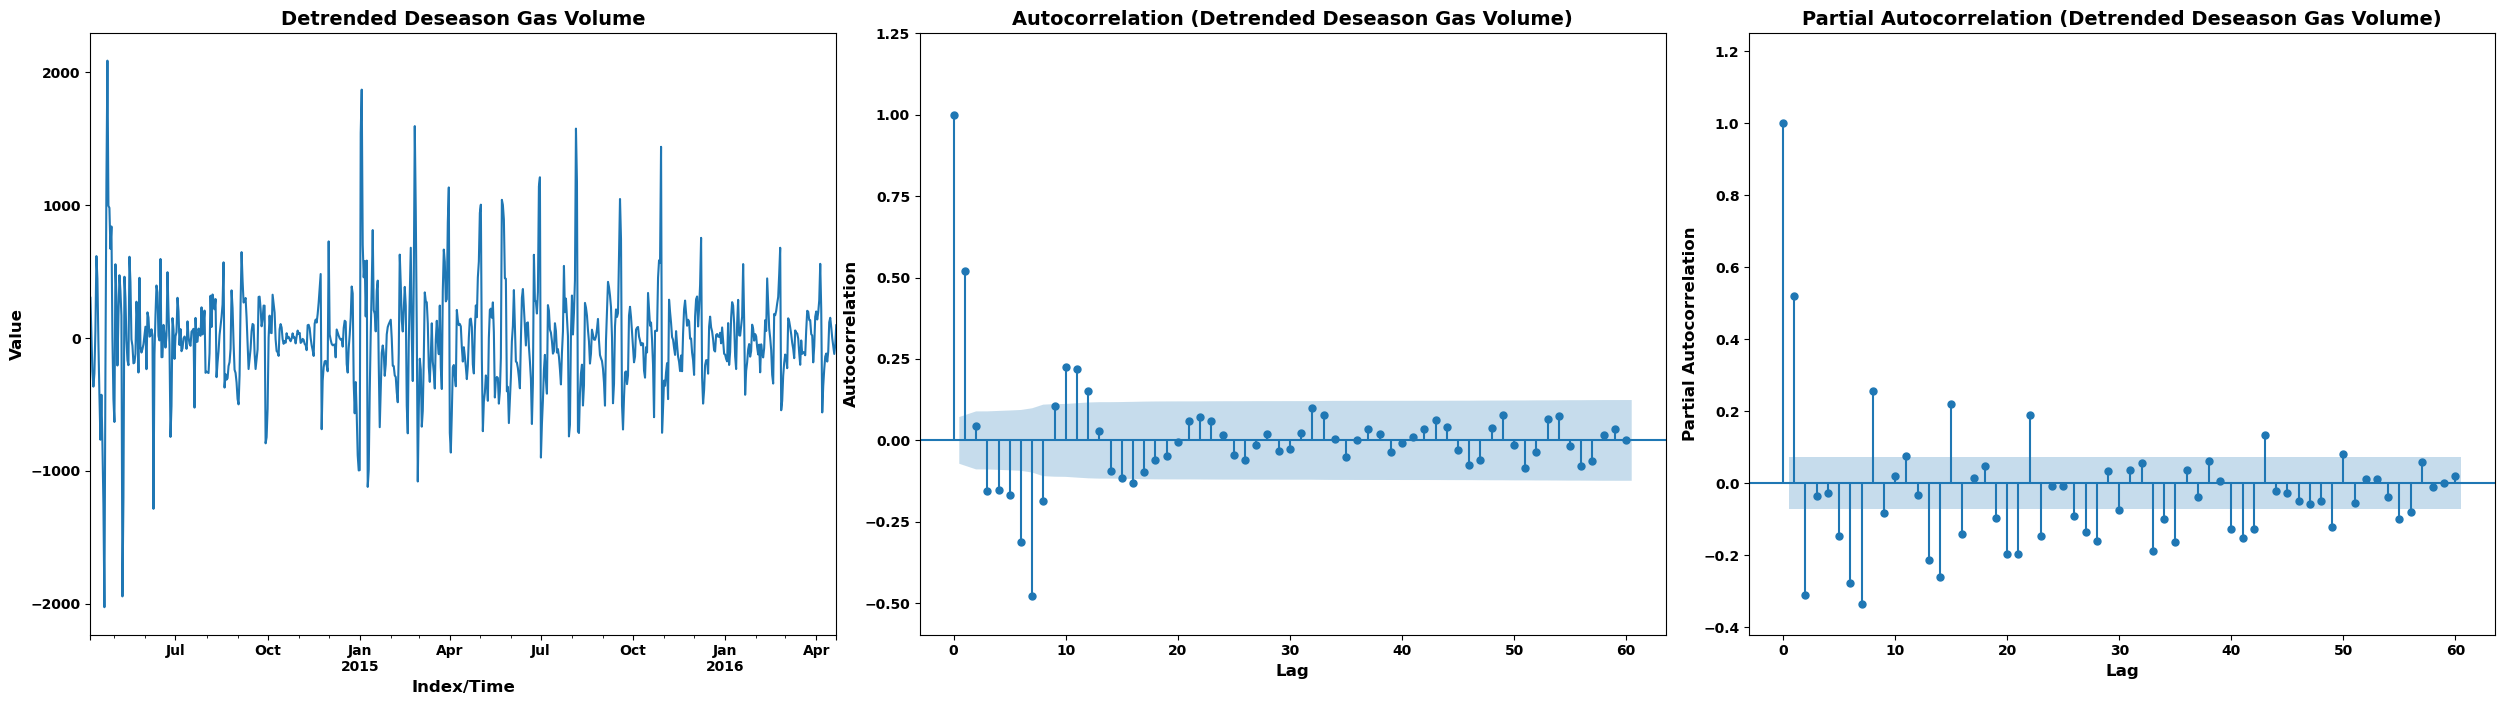

In [32]:
# 2. Setup the grid: 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=[25, 7])

# Plot 1: Detrended Time Series
res_oil.resid.plot(ax=axes[0], color='tab:blue')
axes[0].set_title("Detrended Deseason Gas Volume", weight='bold', fontsize=14)
axes[0].set_ylabel("Value", weight='bold', fontsize=12)
axes[0].set_xlabel("Index/Time", weight='bold', fontsize=12)

# Plot 2: ACF
plot_acf(
    x=res_gas.resid,
    lags=60,
    ax=axes[1],
    alpha=0.05,
    auto_ylims=True
)
axes[1].set_title("Autocorrelation (Detrended Deseason Gas Volume)", weight='bold', fontsize=14)
axes[1].set_ylabel("Autocorrelation", weight='bold', fontsize=12)
axes[1].set_xlabel("Lag", weight='bold', fontsize=12)

# Plot 3: PACF
plot_pacf(
    x=res_gas.resid,
    method='ywmle', 
    lags=60,
    ax=axes[2],
    alpha=0.05,
    auto_ylims=True
)
axes[2].set_title("Partial Autocorrelation (Detrended Deseason Gas Volume)", weight='bold', fontsize=14)
axes[2].set_ylabel("Partial Autocorrelation", weight='bold', fontsize=12)
axes[2].set_xlabel("Lag", weight='bold', fontsize=12)

# Loop through all axes to bold the tick numbers correctly
for ax in axes:
    # Set the size via tick_params safely
    ax.tick_params(axis='both', which='major', labelsize=10)
    
    # Bold the X axis tick labels
    for label in ax.get_xticklabels():
        label.set_weight('bold')
        
    # Bold the Y axis tick labels
    for label in ax.get_yticklabels():
        label.set_weight('bold')

# Adjust spacing and display
plt.tight_layout()
plt.show()

#### Final comments

after removing the trend and the season, i should use a Lag of 1,2,6,7

### ACF & PACF for water

## 2.3 Cross Correlation plot

I am going to use this to plot  manually pick the lags. and force keep these lags in the lasso selector

In [33]:
df_ccf=df.copy()

In [34]:
stl_results = {}

for col in df_ccf:
    # Store the result in the dictionary using a dynamic key
    stl_results[f"res_{col}"] = STL(df_ccf[col]).fit()

### CCF for oil

In [35]:
# target
res_oil = STL(df_ccf["BORE_OIL_VOL_STB_D"]).fit()

Analyzing components for: res_ON_STREAM_HRS
Analyzing components for: res_AVG_CHOKE_SIZE_P
Analyzing components for: res_AVG_DOWNHOLE_PRESSURE_PSI
Analyzing components for: res_AVG_DOWNHOLE_TEMPERATURE_F
Analyzing components for: res_AVG_DP_TUBING_PSI
Analyzing components for: res_DP_CHOKE_SIZE_PSI
Analyzing components for: res_AVG_WHP_P_PSI
Analyzing components for: res_AVG_WHT_P
Analyzing components for: res_BORE_OIL_VOL_STB_D
Analyzing components for: res_BORE_GAS_VOL_MSCF_D
Analyzing components for: res_BORE_WAT_VOL_STB_D
Analyzing components for: res_GOR_MSCF/STB
Analyzing components for: res_WCUT


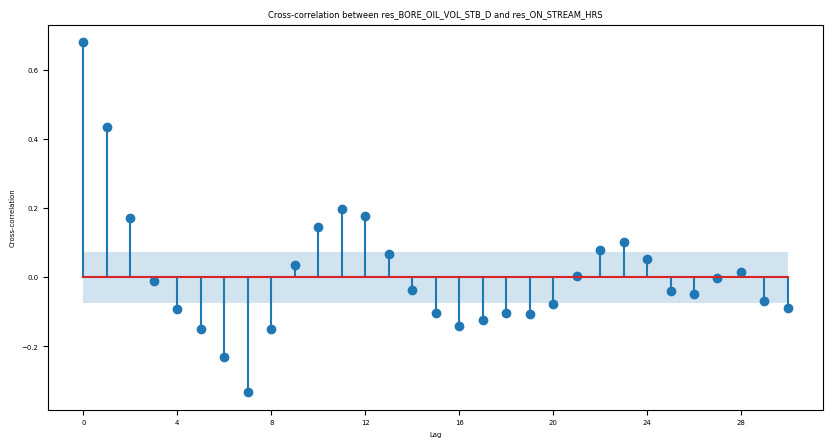

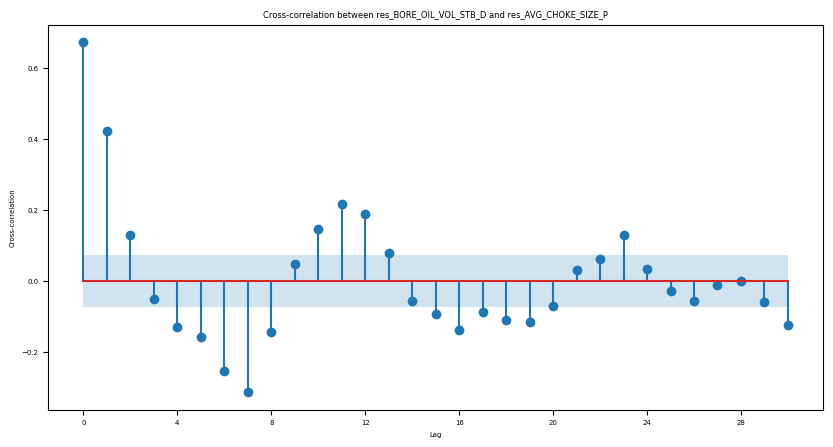

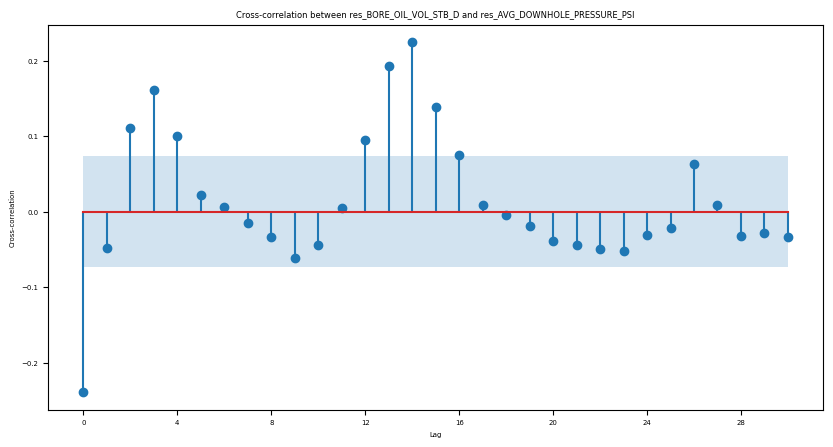

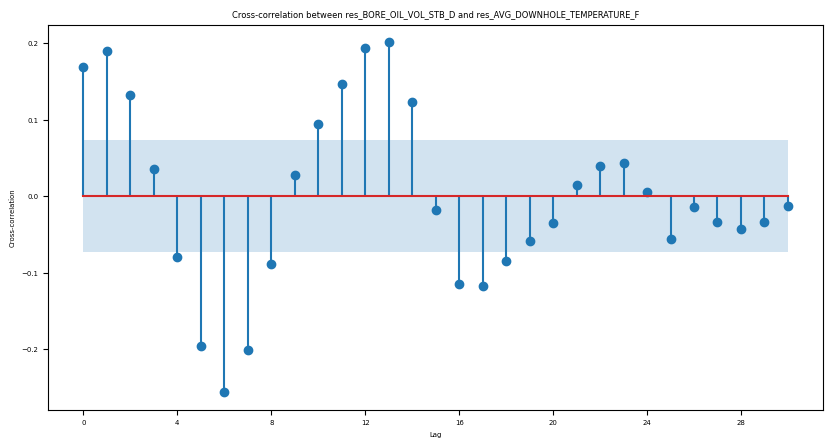

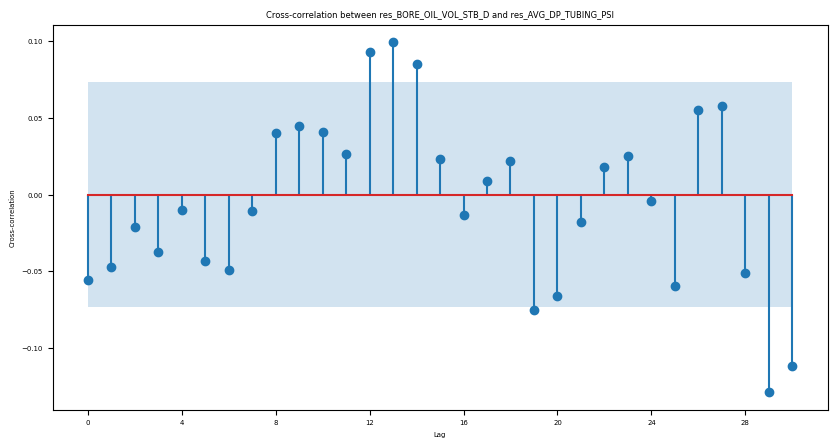

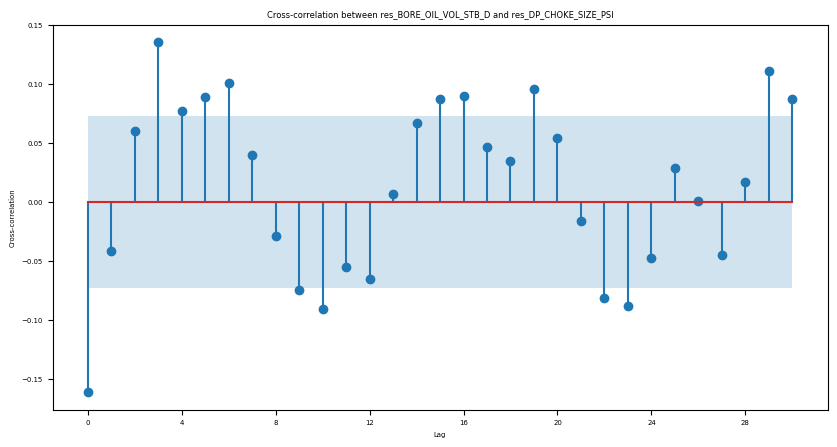

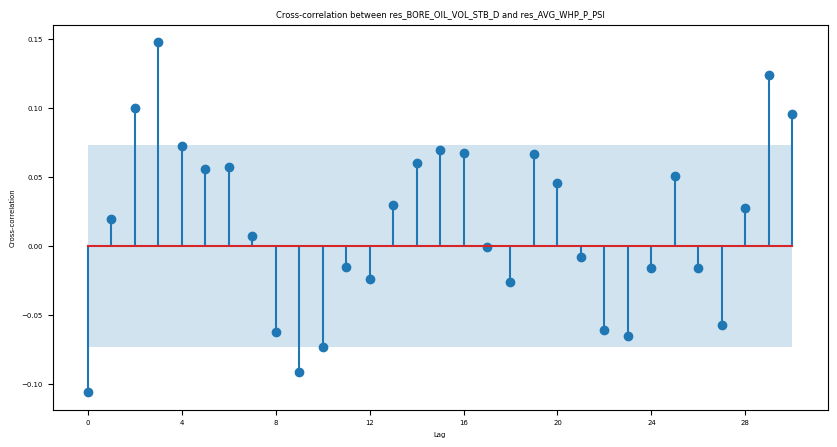

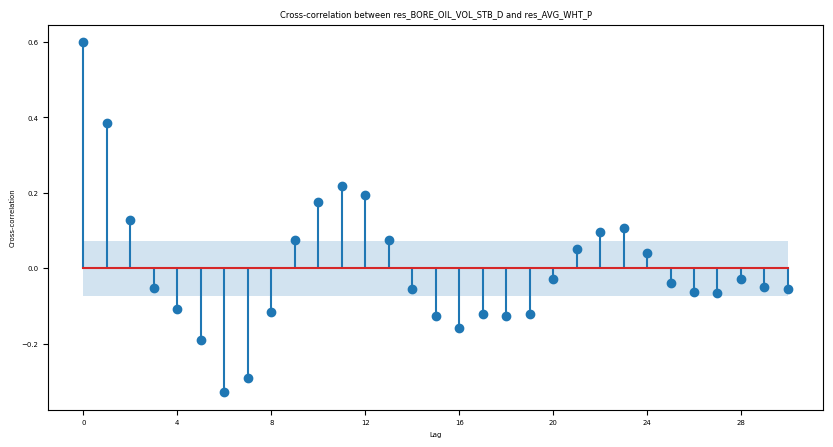

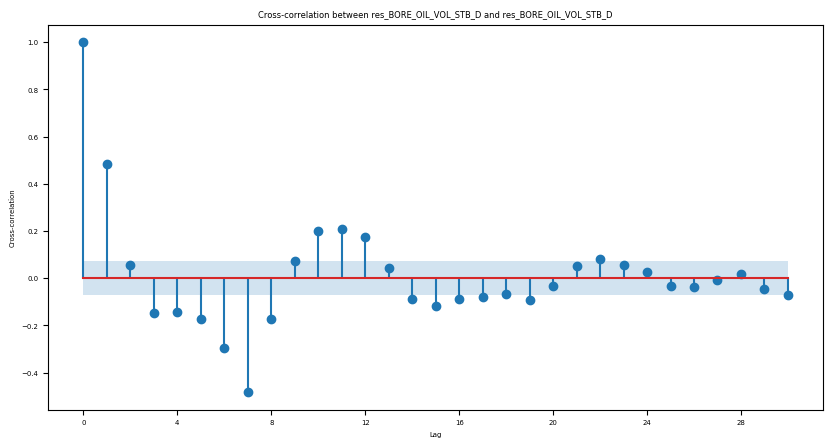

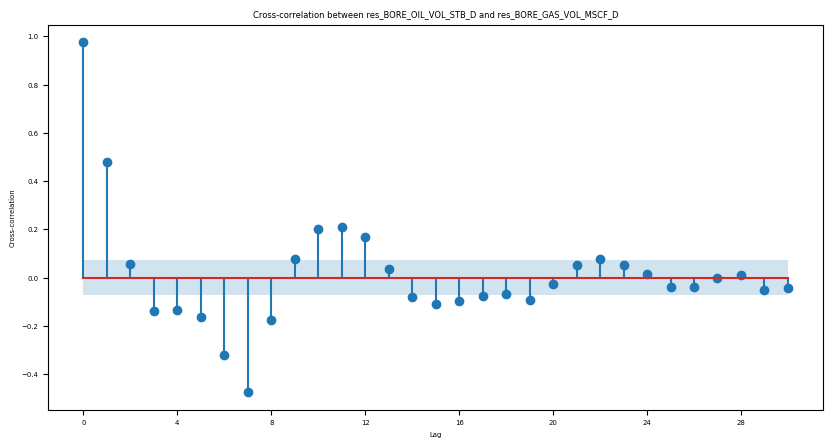

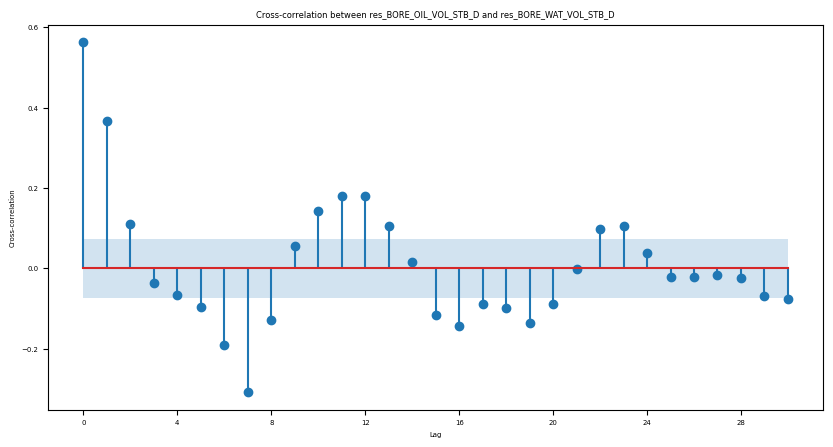

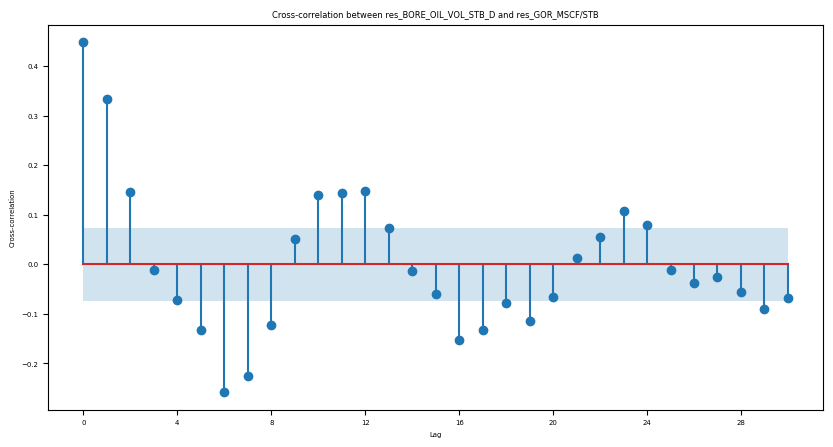

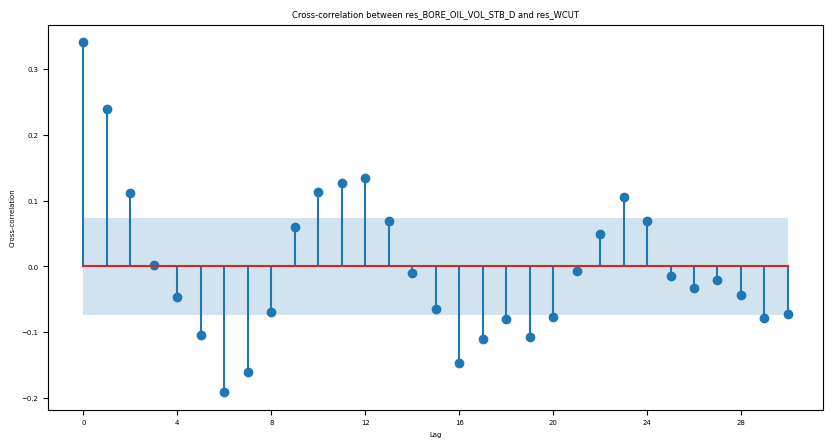

In [36]:
for key, res in stl_results.items():
    print(f"Analyzing components for: {key}")
    ax = plot_ccf(stl_results["res_BORE_OIL_VOL_STB_D"].resid, stl_results[key].resid, lags=30)
    ax.set_title(f"Cross-correlation between res_BORE_OIL_VOL_STB_D and {key}")
    ax.set_ylabel("Cross-correlation")
    ax.set_xlabel("Lag")

These are the features that can be used from the CCF plot
on_stream: 0,1
avg choke, 0,1
avg wht_P: 0,1
bore_oil_vol: 1
gas:1


### CCF for gas

In [ ]:
# target
res_gas = STL(df_ccf["BORE_GAS_VOL_MSCF_D"]).fit()

Analyzing components for: res_ON_STREAM_HRS
Analyzing components for: res_AVG_CHOKE_SIZE_P
Analyzing components for: res_AVG_DOWNHOLE_PRESSURE_PSI
Analyzing components for: res_AVG_DOWNHOLE_TEMPERATURE_F
Analyzing components for: res_AVG_DP_TUBING_PSI
Analyzing components for: res_DP_CHOKE_SIZE_PSI
Analyzing components for: res_AVG_WHP_P_PSI
Analyzing components for: res_AVG_WHT_P
Analyzing components for: res_BORE_OIL_VOL_STB_D
Analyzing components for: res_BORE_GAS_VOL_MSCF_D
Analyzing components for: res_BORE_WAT_VOL_STB_D
Analyzing components for: res_GOR_MSCF/STB
Analyzing components for: res_WCUT


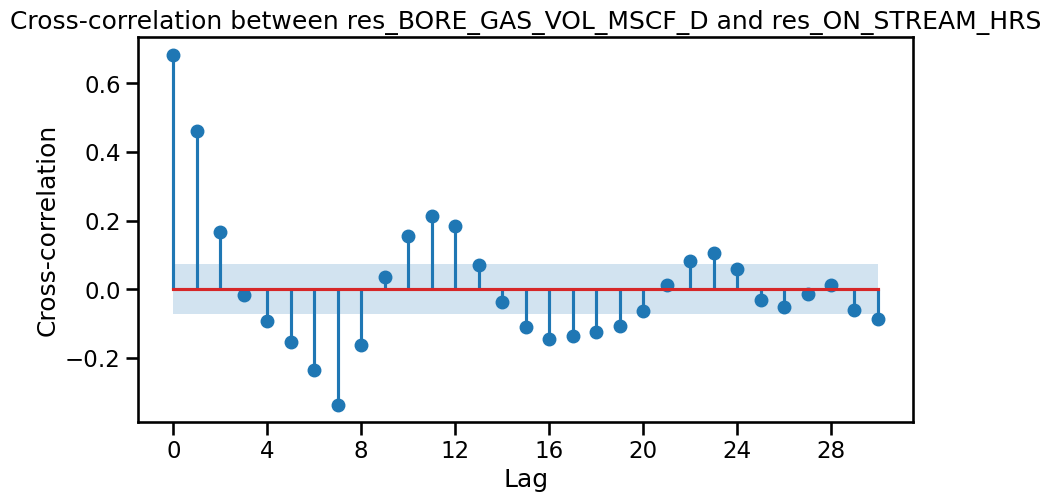

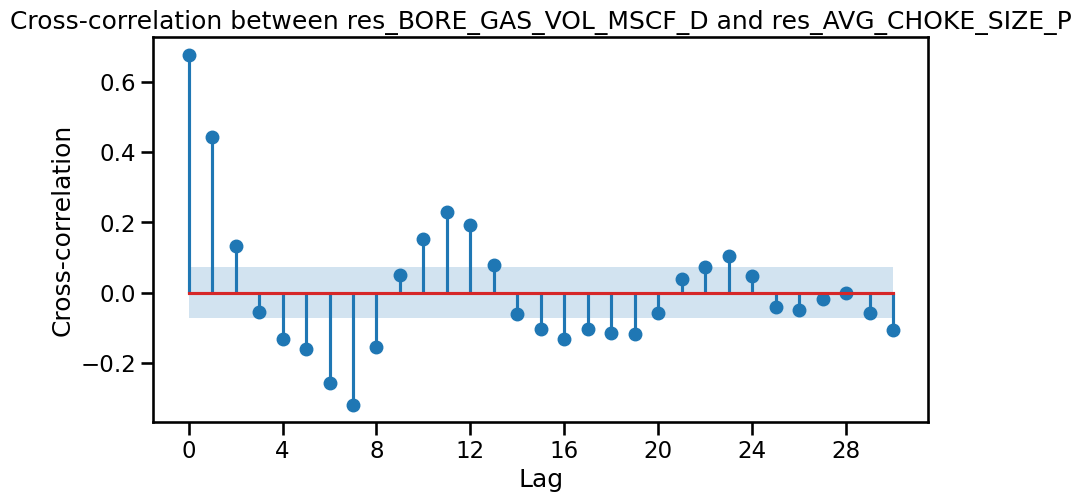

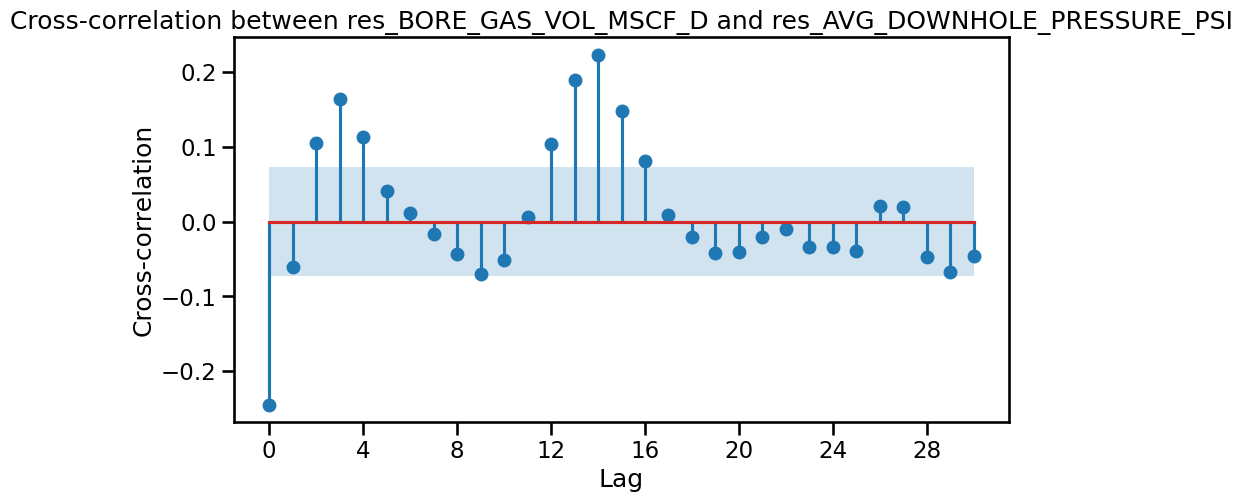

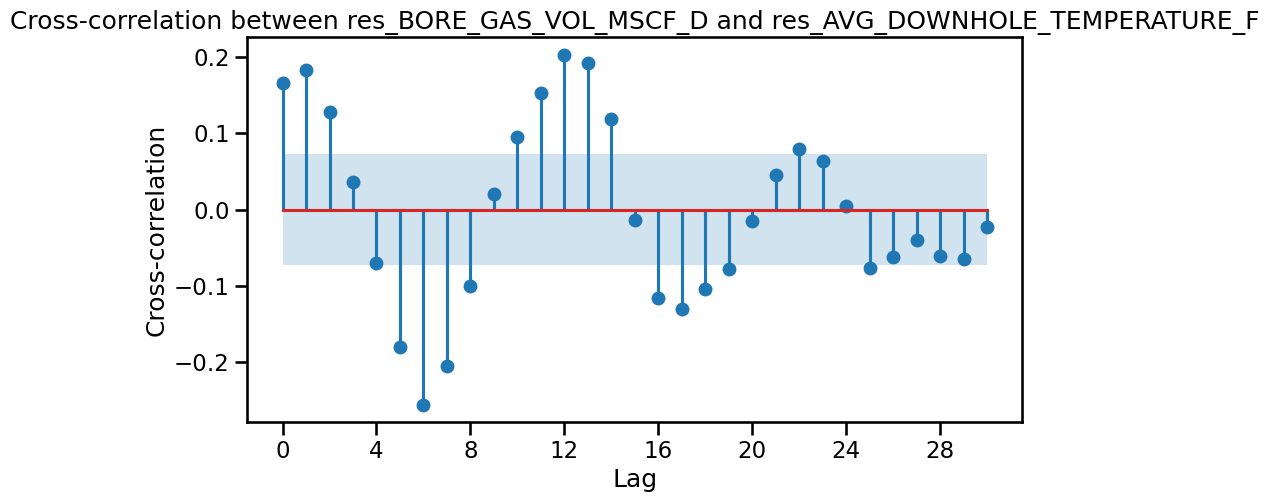

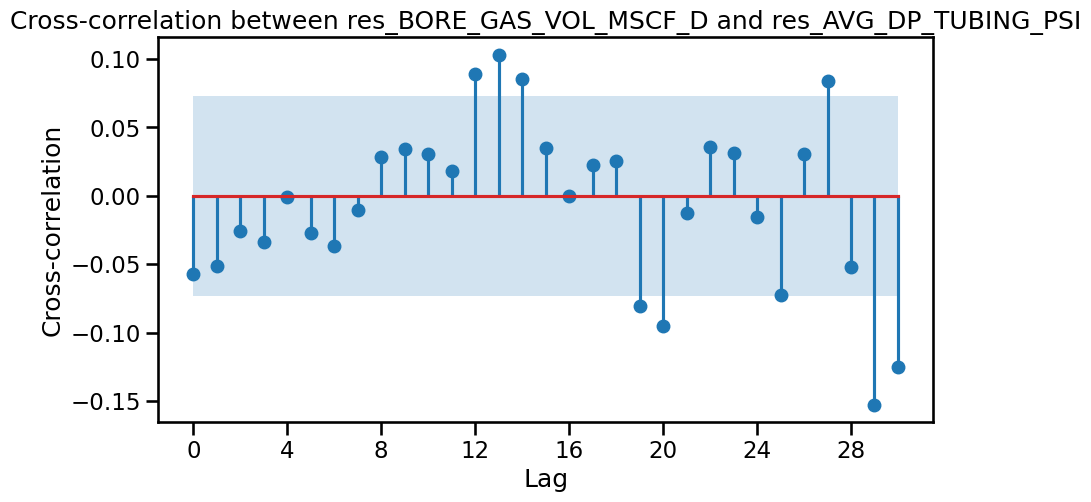

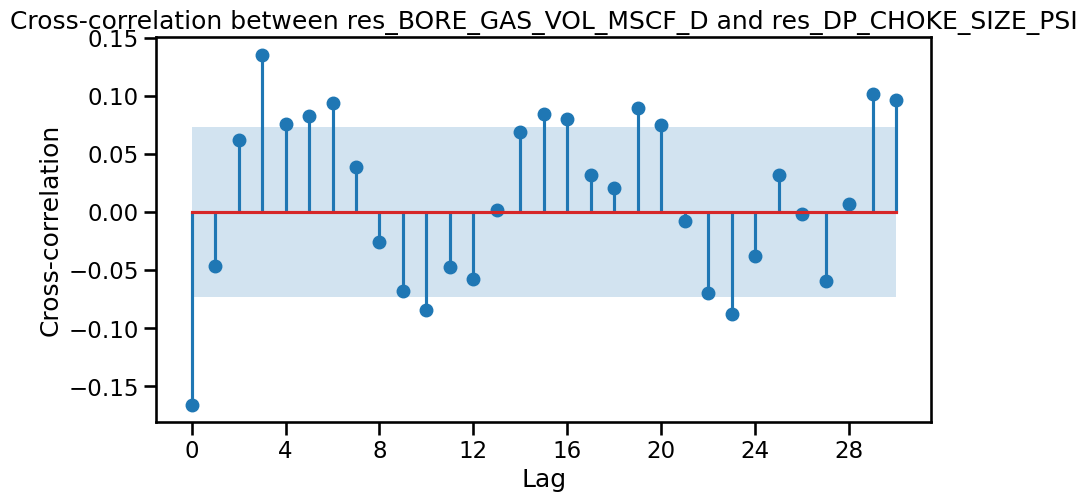

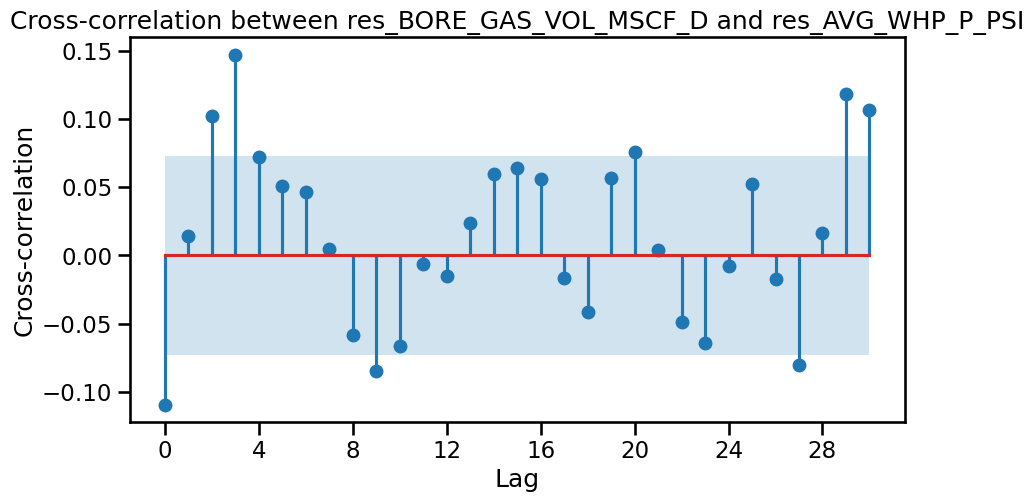

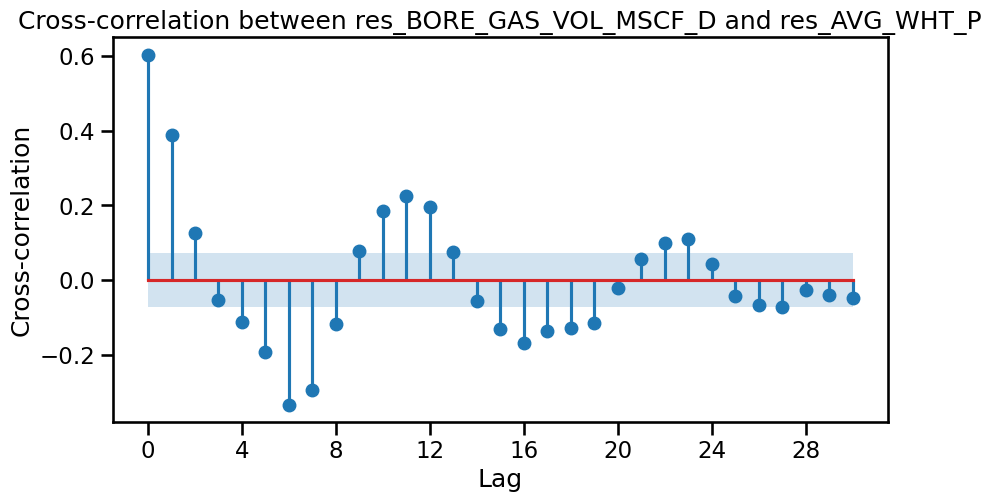

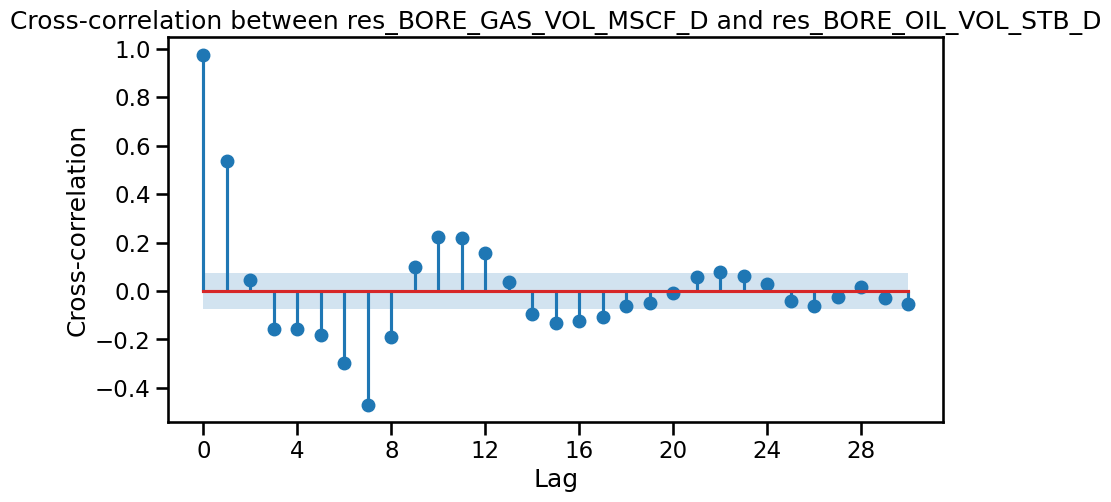

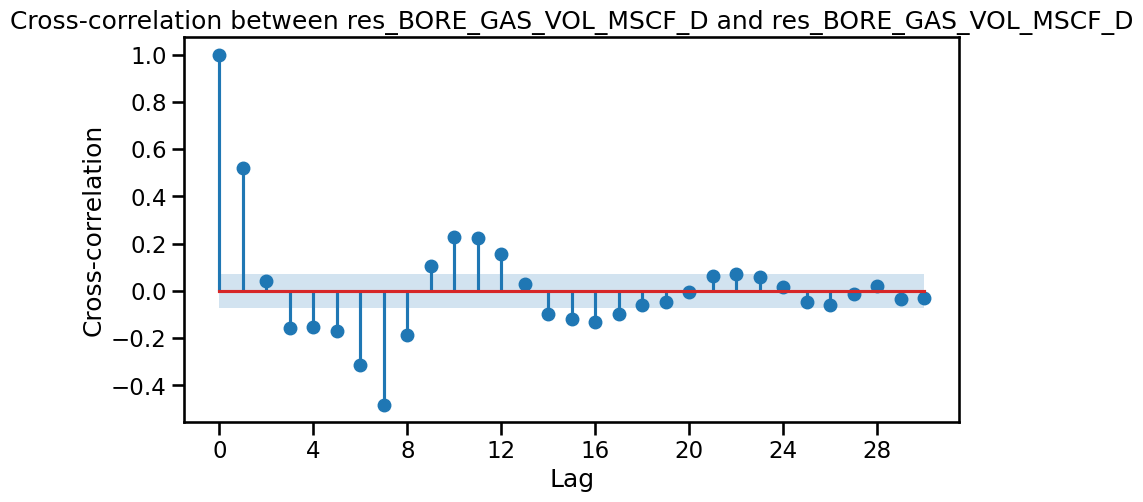

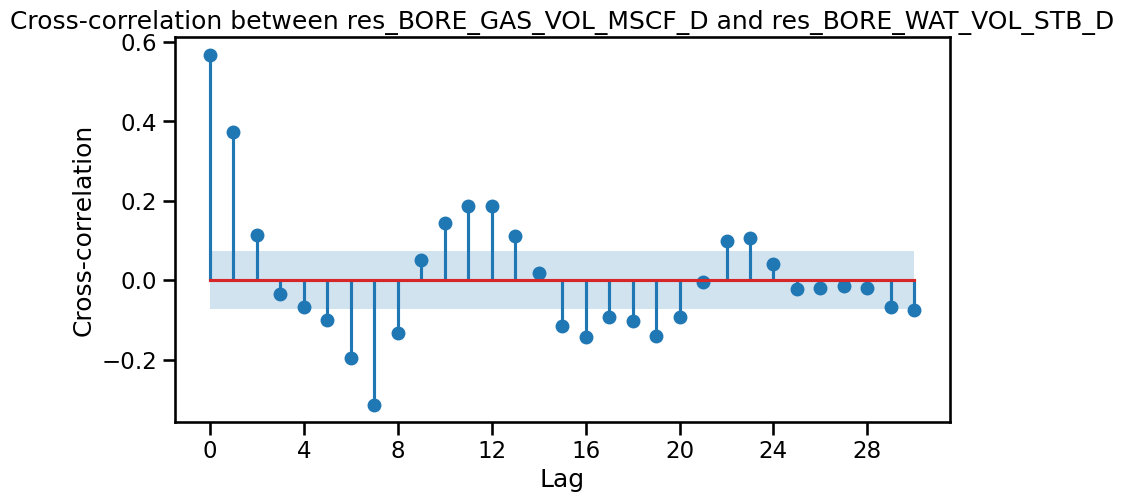

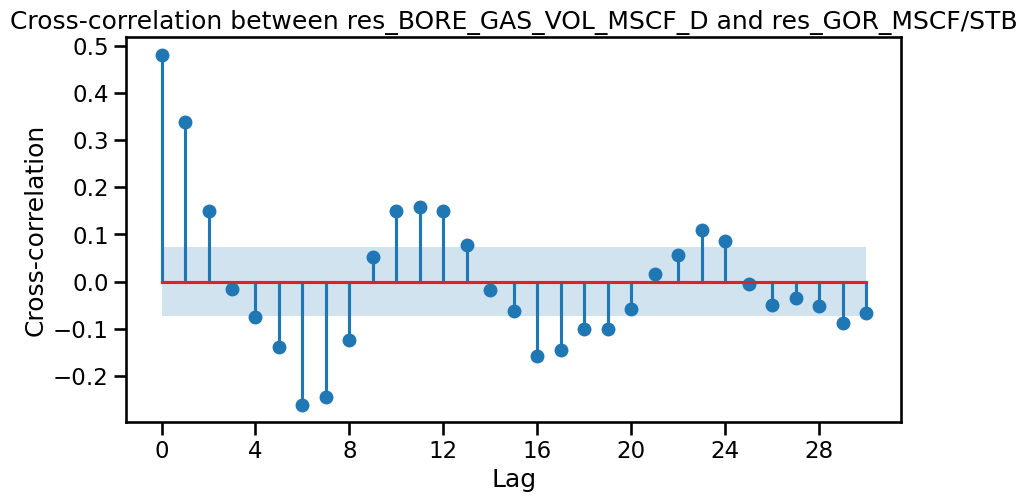

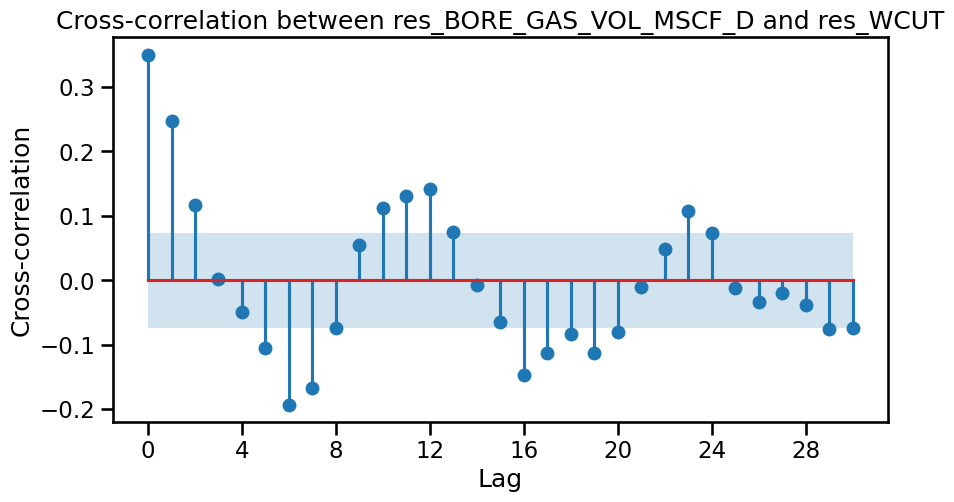

In [38]:
with sns.plotting_context("talk"):
    for key, res in stl_results.items():
        print(f"Analyzing components for: {key}")
        ax = plot_ccf(stl_results["res_BORE_GAS_VOL_MSCF_D"].resid, stl_results[key].resid, lags=30)
        ax.set_title(f"Cross-correlation between res_BORE_GAS_VOL_MSCF_D and {key}")
        ax.set_ylabel("Cross-correlation")
        ax.set_xlabel("Lag")

These are the features that can be used from the CCF plot 
on_stream: 0,1 
avg choke, 0,1 
avg wht_P: 0,1 
BORE_GAS_VOL_MSCF_D: 1 
oil:1

### CCF for water

## 2.4 Lasso for feature selection for Lags to use

### Lags for oil

In [37]:
oil_selected_lag_lasso_adder =LassoSelectedLagFeatureAdder(
    target_col="BORE_OIL_VOL_STB_D",
    variables=df.columns,
    max_lag_days=45,

    # These are removed from Lasso candidates and final forced lags
    targets_to_remove=["BORE_GAS_VOL_MSCF_D","BORE_WAT_VOL_STB_D",],

    # IMPORTANT!!!!! these are user specified lags that should be kept no matter what. gotten from the PACF or CCF
    force_keep_lag_map={
        "BORE_OIL_VOL_STB_D": [1, 2, 6, 7], # from pacf
        "AVG_CHOKE_SIZE_P": [0,1], # from ccf
        "AVG_WHT_P": [0,1],  # from cff
    },
    
    alphas=[ 0.1, 0.2, 0.3, 0.4, 0.5,0.6, 0.7, 0.8, 0.9, 1.0, 5, 10, 20, 50, 100,],
    n_splits=5,
    min_features=5,
    #drop_na=True,
    verbose=True,
)

In [38]:
oil_selected_lag_lasso_adder.fit_transform(df)

LassoSelectedLagFeatureAdder__Original columns after GOR/WCUT: 13
LassoSelectedLagFeatureAdder__All lag features created: 572
LassoSelectedLagFeatureAdder__Lag features removed from Lasso candidates: 88
LassoSelectedLagFeatureAdder__Candidate lag features used by Lasso: 484
LassoSelectedLagFeatureAdder__Rows used internally for Lasso fit: 702
LassoSelectedLagFeatureAdder__Best alpha: 100
LassoSelectedLagFeatureAdder__Lasso-selected lag features: 6
LassoSelectedLagFeatureAdder__Force-kept lag features: 6
LassoSelectedLagFeatureAdder__Final selected lag features: 11
LassoSelectedLagFeatureAdder__Final dataframe columns returned: 24
Missing force-keep lag features:
['AVG_CHOKE_SIZE_P_lag_0D', 'AVG_WHT_P_lag_0D']


,ON_STREAM_HRS,AVG_CHOKE_SIZE_P,AVG_DOWNHOLE_PRESSURE_PSI,AVG_DOWNHOLE_TEMPERATURE_F,AVG_DP_TUBING_PSI,DP_CHOKE_SIZE_PSI,AVG_WHP_P_PSI,AVG_WHT_P,BORE_OIL_VOL_STB_D,BORE_GAS_VOL_MSCF_D,...,BORE_OIL_VOL_STB_D_lag_2D,BORE_OIL_VOL_STB_D_lag_6D,BORE_OIL_VOL_STB_D_lag_7D,AVG_CHOKE_SIZE_P_lag_1D,AVG_WHT_P_lag_1D,GOR_MSCF/STB_lag_1D,WCUT_lag_16D,BORE_OIL_VOL_STB_D_lag_31D,ON_STREAM_HRS_lag_1D,WCUT_lag_19D
DATEPRD,,,,,,,,,,,,,,,,,,,,,
2014-04-07,0.0,0.000000,0.000000,32.000000,0.000000,0.000000,0.000000,32.000000,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-04-08,0.0,1.003059,1125.408365,75.594150,1005.397107,0.000000,0.000000,32.000000,0.0,0.0,...,NaN,NaN,NaN,0.000000,32.000000,0.0,NaN,NaN,0.0,NaN
2014-04-09,0.0,0.979008,2250.816730,119.188301,2010.794214,0.000000,0.000000,32.000000,0.0,0.0,...,0.0,NaN,NaN,1.003059,32.000000,0.0,NaN,NaN,0.0,NaN
2014-04-10,0.0,0.545759,3376.225094,162.782451,3016.191321,0.000000,0.000000,32.000000,0.0,0.0,...,0.0,NaN,NaN,0.979008,32.000000,0.0,NaN,NaN,0.0,NaN
2014-04-11,0.0,1.215987,4501.633459,206.376602,4021.588427,479.668948,480.045032,50.863856,0.0,0.0,...,0.0,NaN,NaN,0.545759,32.000000,0.0,NaN,NaN,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-04-17,0.0,0.000000,3919.920125,214.156526,3825.672402,38.366612,94.247723,49.644446,0.0,0.0,...,0.0,0.0,0.0,0.000000,50.141894,0.0,0.726166,316.377443,0.0,0.764337
2016-04-18,0.0,0.000000,4015.651877,214.215836,3816.747199,59.755656,198.904678,53.136032,0.0,0.0,...,0.0,0.0,0.0,0.000000,49.644446,0.0,0.729083,238.886984,0.0,0.739426
2016-04-19,0.0,0.265188,4091.600010,214.119572,3967.218467,27.068152,124.381543,50.214308,0.0,0.0,...,0.0,0.0,0.0,0.000000,53.136032,0.0,0.727572,400.220610,0.0,0.740710


### Lags for gas

In [26]:
gas_selected_lag_lasso_adder =LassoSelectedLagFeatureAdder(
    target_col="BORE_GAS_VOL_MSCF_D",
    variables=df.columns,
    max_lag_days=45,

    # These are removed from Lasso candidates and final forced lags. I don't want these to be used to predict the target
    targets_to_remove=["BORE_OIL_VOL_STB_D","BORE_WAT_VOL_STB_D",],

    # IMPORTANT!!!!! these are user specified lags that should be kept no matter what. gotten from the PACF or CCF
    force_keep_lag_map={
        "BORE_GAS_VOL_MSCF_D": [1, 2, 6, 7], # from pacf
        "AVG_CHOKE_SIZE_P": [0,1], # from ccf
        "AVG_WHT_P": [0,1],  # from cff
        "BORE_OIL_VOL_STB_D": [1],  # from cff
    },
    
    alphas=[ 0.1, 0.2, 0.3, 0.4, 0.5,0.6, 0.7, 0.8, 0.9, 1.0, 5, 10, 20, 50, 100,],
    n_splits=5,
    min_features=5,
    #drop_na=True,
    verbose=True,
)

In [27]:
gas_selected_lag_lasso_adder.fit_transform(df)

LassoSelectedLagFeatureAdder__Original columns after GOR/WCUT: 13
LassoSelectedLagFeatureAdder__All lag features created: 572
LassoSelectedLagFeatureAdder__Lag features removed from Lasso candidates: 88
LassoSelectedLagFeatureAdder__Candidate lag features used by Lasso: 484
LassoSelectedLagFeatureAdder__Rows used internally for Lasso fit: 702
LassoSelectedLagFeatureAdder__Best alpha: 100
LassoSelectedLagFeatureAdder__Lasso-selected lag features: 6
LassoSelectedLagFeatureAdder__Force-kept lag features: 6
LassoSelectedLagFeatureAdder__Final selected lag features: 11
LassoSelectedLagFeatureAdder__Final dataframe columns returned: 24
Missing force-keep lag features:
['AVG_CHOKE_SIZE_P_lag_0D', 'AVG_WHT_P_lag_0D', 'BORE_OIL_VOL_STB_D_lag_1D']


,ON_STREAM_HRS,AVG_CHOKE_SIZE_P,AVG_DOWNHOLE_PRESSURE_PSI,AVG_DOWNHOLE_TEMPERATURE_F,AVG_DP_TUBING_PSI,DP_CHOKE_SIZE_PSI,AVG_WHP_P_PSI,AVG_WHT_P,BORE_OIL_VOL_STB_D,BORE_GAS_VOL_MSCF_D,...,BORE_GAS_VOL_MSCF_D_lag_2D,BORE_GAS_VOL_MSCF_D_lag_6D,BORE_GAS_VOL_MSCF_D_lag_7D,AVG_CHOKE_SIZE_P_lag_1D,AVG_WHT_P_lag_1D,GOR_MSCF/STB_lag_1D,WCUT_lag_16D,ON_STREAM_HRS_lag_1D,BORE_GAS_VOL_MSCF_D_lag_31D,BORE_GAS_VOL_MSCF_D_lag_30D
DATEPRD,,,,,,,,,,,,,,,,,,,,,
2014-04-07,0.0,0.000000,0.000000,32.000000,0.000000,0.000000,0.000000,32.000000,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-04-08,0.0,1.003059,1125.408365,75.594150,1005.397107,0.000000,0.000000,32.000000,0.0,0.0,...,NaN,NaN,NaN,0.000000,32.000000,0.0,NaN,0.0,NaN,NaN
2014-04-09,0.0,0.979008,2250.816730,119.188301,2010.794214,0.000000,0.000000,32.000000,0.0,0.0,...,0.0,NaN,NaN,1.003059,32.000000,0.0,NaN,0.0,NaN,NaN
2014-04-10,0.0,0.545759,3376.225094,162.782451,3016.191321,0.000000,0.000000,32.000000,0.0,0.0,...,0.0,NaN,NaN,0.979008,32.000000,0.0,NaN,0.0,NaN,NaN
2014-04-11,0.0,1.215987,4501.633459,206.376602,4021.588427,479.668948,480.045032,50.863856,0.0,0.0,...,0.0,NaN,NaN,0.545759,32.000000,0.0,NaN,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-04-17,0.0,0.000000,3919.920125,214.156526,3825.672402,38.366612,94.247723,49.644446,0.0,0.0,...,0.0,0.0,0.0,0.000000,50.141894,0.0,0.726166,0.0,285.572322,219.071210
2016-04-18,0.0,0.000000,4015.651877,214.215836,3816.747199,59.755656,198.904678,53.136032,0.0,0.0,...,0.0,0.0,0.0,0.000000,49.644446,0.0,0.729083,0.0,219.071210,369.209891
2016-04-19,0.0,0.265188,4091.600010,214.119572,3967.218467,27.068152,124.381543,50.214308,0.0,0.0,...,0.0,0.0,0.0,0.000000,53.136032,0.0,0.727572,0.0,369.209891,468.379926


### Lags for water

# 3. Window Feature

In [28]:
df_win=df.copy()
df_win

,ON_STREAM_HRS,AVG_CHOKE_SIZE_P,AVG_DOWNHOLE_PRESSURE_PSI,AVG_DOWNHOLE_TEMPERATURE_F,AVG_DP_TUBING_PSI,DP_CHOKE_SIZE_PSI,AVG_WHP_P_PSI,AVG_WHT_P,BORE_OIL_VOL_STB_D,BORE_GAS_VOL_MSCF_D,BORE_WAT_VOL_STB_D,GOR_MSCF/STB,WCUT
DATEPRD,,,,,,,,,,,,,
2014-04-07,0.0,0.000000,0.000000,32.000000,0.000000,0.000000,0.000000,32.000000,0.0,0.0,0.0,0.0,0.0
2014-04-08,0.0,1.003059,1125.408365,75.594150,1005.397107,0.000000,0.000000,32.000000,0.0,0.0,0.0,0.0,0.0
2014-04-09,0.0,0.979008,2250.816730,119.188301,2010.794214,0.000000,0.000000,32.000000,0.0,0.0,0.0,0.0,0.0
2014-04-10,0.0,0.545759,3376.225094,162.782451,3016.191321,0.000000,0.000000,32.000000,0.0,0.0,0.0,0.0,0.0
2014-04-11,0.0,1.215987,4501.633459,206.376602,4021.588427,479.668948,480.045032,50.863856,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-04-17,0.0,0.000000,3919.920125,214.156526,3825.672402,38.366612,94.247723,49.644446,0.0,0.0,0.0,0.0,0.0
2016-04-18,0.0,0.000000,4015.651877,214.215836,3816.747199,59.755656,198.904678,53.136032,0.0,0.0,0.0,0.0,0.0
2016-04-19,0.0,0.265188,4091.600010,214.119572,3967.218467,27.068152,124.381543,50.214308,0.0,0.0,0.0,0.0,0.0


### oil

In [40]:
# rolling features
oil_rolling_feat = WindowFeatures(
    variables=["BORE_OIL_VOL_STB_D","GOR_MSCF/STB", "WCUT","AVG_WHT_P"],
    functions=["mean", "std"],
    window=[7],
    freq="1d",# Shift results back by 1 hour to avoid data leakage.
)

df_win = oil_rolling_feat.fit_transform(df_win)
df_win.head(10)

,ON_STREAM_HRS,AVG_CHOKE_SIZE_P,AVG_DOWNHOLE_PRESSURE_PSI,AVG_DOWNHOLE_TEMPERATURE_F,AVG_DP_TUBING_PSI,DP_CHOKE_SIZE_PSI,AVG_WHP_P_PSI,AVG_WHT_P,BORE_OIL_VOL_STB_D,BORE_GAS_VOL_MSCF_D,...,GOR_MSCF/STB,WCUT,BORE_OIL_VOL_STB_D_window_7_mean,BORE_OIL_VOL_STB_D_window_7_std,GOR_MSCF/STB_window_7_mean,GOR_MSCF/STB_window_7_std,WCUT_window_7_mean,WCUT_window_7_std,AVG_WHT_P_window_7_mean,AVG_WHT_P_window_7_std
DATEPRD,,,,,,,,,,,,,,,,,,,,,
2014-04-07,0.0,0.000000,0.000000,32.000000,0.000000,0.000000,0.000000,32.000000,0.0,0.0,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-04-08,0.0,1.003059,1125.408365,75.594150,1005.397107,0.000000,0.000000,32.000000,0.0,0.0,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-04-09,0.0,0.979008,2250.816730,119.188301,2010.794214,0.000000,0.000000,32.000000,0.0,0.0,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-04-10,0.0,0.545759,3376.225094,162.782451,3016.191321,0.000000,0.000000,32.000000,0.0,0.0,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-04-11,0.0,1.215987,4501.633459,206.376602,4021.588427,479.668948,480.045032,50.863856,0.0,0.0,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-04-12,0.0,3.087015,4401.914613,206.462102,4082.057380,319.857233,319.857233,47.667722,0.0,0.0,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-04-13,0.0,1.962365,4402.408177,206.525930,4003.512922,234.428690,398.895256,48.961670,0.0,0.0,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-04-14,0.0,0.000000,4405.997433,206.543714,4101.482610,300.767041,304.514823,46.636466,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39.356178,9.221599
2014-04-15,0.0,31.141856,4407.098706,206.638448,4205.241490,176.678475,201.857217,47.296994,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,41.447102,8.930405


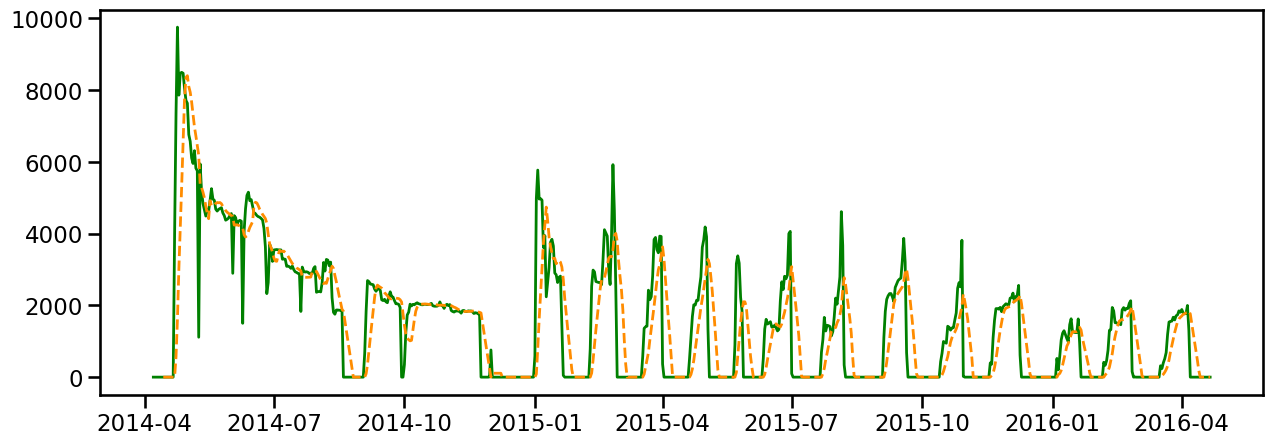

In [65]:
with sns.plotting_context("talk"): 
    plt.figure(figsize=(15, 5))
    plt.plot(df_win.index, df_win["BORE_OIL_VOL_STB_D"], label="BORE_OIL_VOL_STB_D", color="green", linewidth=2)
    plt.plot(df_win.index,df_win["BORE_OIL_VOL_STB_D_window_7_mean"],label="BORE_OIL_VOL_STB_D_window_7_mean",color="darkorange",linewidth=2,linestyle="--",)


In [31]:
# expanding window
expanding_feat = ExpandingWindowFeatures(
    variables=["BORE_OIL_VOL_STB_D","BORE_GAS_VOL_MSCF_D", "BORE_WAT_VOL_STB_D"], 
    functions=["sum"], 
    freq="1d" # Shift results back by 1 day to avoid data leakage.
)  

df_win = expanding_feat.fit_transform(df_win)
df_win.head(20)

,ON_STREAM_HRS,AVG_CHOKE_SIZE_P,AVG_DOWNHOLE_PRESSURE_PSI,AVG_DOWNHOLE_TEMPERATURE_F,AVG_DP_TUBING_PSI,DP_CHOKE_SIZE_PSI,AVG_WHP_P_PSI,AVG_WHT_P,BORE_OIL_VOL_STB_D,BORE_GAS_VOL_MSCF_D,...,BORE_GAS_VOL_MSCF_D_window_7_std,GOR_MSCF/STB_window_7_mean,GOR_MSCF/STB_window_7_std,WCUT_window_7_mean,WCUT_window_7_std,AVG_WHT_P_window_7_mean,AVG_WHT_P_window_7_std,BORE_OIL_VOL_STB_D_expanding_sum,BORE_GAS_VOL_MSCF_D_expanding_sum,BORE_WAT_VOL_STB_D_expanding_sum
DATEPRD,,,,,,,,,,,,,,,,,,,,,
2014-04-07,0.0,0.000000,0.000000,32.000000,0.000000,0.000000,0.000000,32.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-04-08,0.0,1.003059,1125.408365,75.594150,1005.397107,0.000000,0.000000,32.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.0
2014-04-09,0.0,0.979008,2250.816730,119.188301,2010.794214,0.000000,0.000000,32.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.0
2014-04-10,0.0,0.545759,3376.225094,162.782451,3016.191321,0.000000,0.000000,32.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.0
2014-04-11,0.0,1.215987,4501.633459,206.376602,4021.588427,479.668948,480.045032,50.863856,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.0
2014-04-12,0.0,3.087015,4401.914613,206.462102,4082.057380,319.857233,319.857233,47.667722,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.0
2014-04-13,0.0,1.962365,4402.408177,206.525930,4003.512922,234.428690,398.895256,48.961670,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.0
2014-04-14,0.0,0.000000,4405.997433,206.543714,4101.482610,300.767041,304.514823,46.636466,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,39.356178,9.221599,0.000000,0.000000,0.0
2014-04-15,0.0,31.141856,4407.098706,206.638448,4205.241490,176.678475,201.857217,47.296994,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,41.447102,8.930405,0.000000,0.000000,0.0


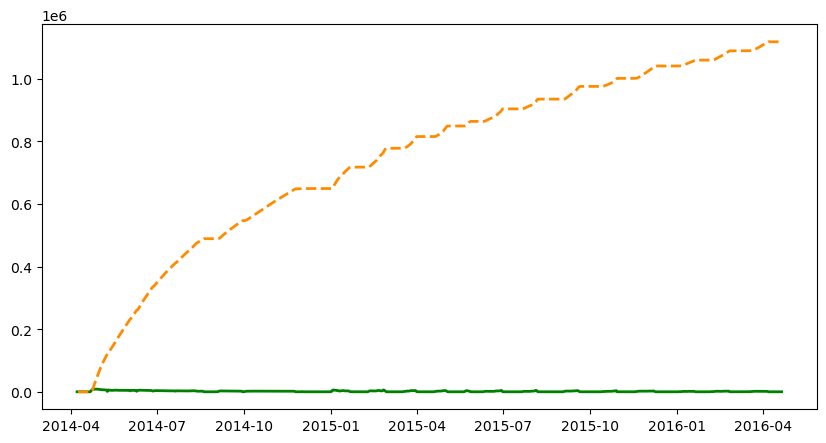

In [32]:
plt.figure(figsize=(10, 5))
plt.plot(df_win.index, df_win["BORE_OIL_VOL_STB_D"], label="BORE_OIL_VOL_STB_D", color="green", linewidth=2)
plt.plot(df_win.index,df_win["BORE_OIL_VOL_STB_D_expanding_sum"],label="BORE_OIL_VOL_STB_D_expanding_mean_y",color="darkorange",linewidth=2,linestyle="--",)


### gas

In [29]:
# rolling features
gas_rolling_feat = WindowFeatures(
    variables=["BORE_GAS_VOL_MSCF_D","GOR_MSCF/STB", "WCUT","AVG_WHT_P"],
    functions=["mean", "std"],
    window=[7],
    freq="1d",# Shift results back by 1 hour to avoid data leakage.
)

df_win = gas_rolling_feat.fit_transform(df_win)
df_win.head(10)

,ON_STREAM_HRS,AVG_CHOKE_SIZE_P,AVG_DOWNHOLE_PRESSURE_PSI,AVG_DOWNHOLE_TEMPERATURE_F,AVG_DP_TUBING_PSI,DP_CHOKE_SIZE_PSI,AVG_WHP_P_PSI,AVG_WHT_P,BORE_OIL_VOL_STB_D,BORE_GAS_VOL_MSCF_D,...,GOR_MSCF/STB,WCUT,BORE_GAS_VOL_MSCF_D_window_7_mean,BORE_GAS_VOL_MSCF_D_window_7_std,GOR_MSCF/STB_window_7_mean,GOR_MSCF/STB_window_7_std,WCUT_window_7_mean,WCUT_window_7_std,AVG_WHT_P_window_7_mean,AVG_WHT_P_window_7_std
DATEPRD,,,,,,,,,,,,,,,,,,,,,
2014-04-07,0.0,0.000000,0.000000,32.000000,0.000000,0.000000,0.000000,32.000000,0.0,0.0,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-04-08,0.0,1.003059,1125.408365,75.594150,1005.397107,0.000000,0.000000,32.000000,0.0,0.0,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-04-09,0.0,0.979008,2250.816730,119.188301,2010.794214,0.000000,0.000000,32.000000,0.0,0.0,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-04-10,0.0,0.545759,3376.225094,162.782451,3016.191321,0.000000,0.000000,32.000000,0.0,0.0,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-04-11,0.0,1.215987,4501.633459,206.376602,4021.588427,479.668948,480.045032,50.863856,0.0,0.0,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-04-12,0.0,3.087015,4401.914613,206.462102,4082.057380,319.857233,319.857233,47.667722,0.0,0.0,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-04-13,0.0,1.962365,4402.408177,206.525930,4003.512922,234.428690,398.895256,48.961670,0.0,0.0,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-04-14,0.0,0.000000,4405.997433,206.543714,4101.482610,300.767041,304.514823,46.636466,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39.356178,9.221599
2014-04-15,0.0,31.141856,4407.098706,206.638448,4205.241490,176.678475,201.857217,47.296994,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,41.447102,8.930405


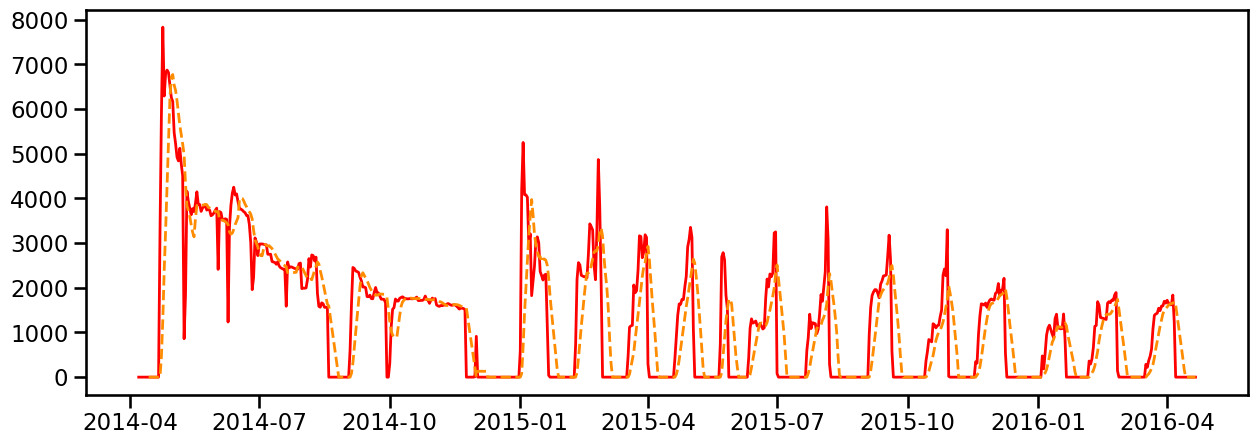

In [30]:
with sns.plotting_context("talk"): 
    plt.figure(figsize=(15, 5))
    plt.plot(df_win.index, df_win["BORE_GAS_VOL_MSCF_D"], label="BORE_GAS_VOL_MSCF_D", color="red", linewidth=2)
    plt.plot(df_win.index,df_win["BORE_GAS_VOL_MSCF_D_window_7_mean"],label="BORE_GAS_VOL_MSCF_D_window_7_mean",color="darkorange",linewidth=2,linestyle="--",)

### water

# 4. Trend feature

In [33]:
trend_adder = TrendFeatureAdder(
    freq="d",
    degree=2,
    include_bias=False,
    prefix="time_since",
    overwrite=True,
    verbose=True,
)

In [34]:
trend_adder.fit_transform(df)

Trend features added: ['time_since_d', 'time_since_d_power_2']


,ON_STREAM_HRS,AVG_CHOKE_SIZE_P,AVG_DOWNHOLE_PRESSURE_PSI,AVG_DOWNHOLE_TEMPERATURE_F,AVG_DP_TUBING_PSI,DP_CHOKE_SIZE_PSI,AVG_WHP_P_PSI,AVG_WHT_P,BORE_OIL_VOL_STB_D,BORE_GAS_VOL_MSCF_D,BORE_WAT_VOL_STB_D,GOR_MSCF/STB,WCUT,time_since_d,time_since_d_power_2
DATEPRD,,,,,,,,,,,,,,,
2014-04-07,0.0,0.000000,0.000000,32.000000,0.000000,0.000000,0.000000,32.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-04-08,0.0,1.003059,1125.408365,75.594150,1005.397107,0.000000,0.000000,32.000000,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2014-04-09,0.0,0.979008,2250.816730,119.188301,2010.794214,0.000000,0.000000,32.000000,0.0,0.0,0.0,0.0,0.0,2.0,4.0
2014-04-10,0.0,0.545759,3376.225094,162.782451,3016.191321,0.000000,0.000000,32.000000,0.0,0.0,0.0,0.0,0.0,3.0,9.0
2014-04-11,0.0,1.215987,4501.633459,206.376602,4021.588427,479.668948,480.045032,50.863856,0.0,0.0,0.0,0.0,0.0,4.0,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-04-17,0.0,0.000000,3919.920125,214.156526,3825.672402,38.366612,94.247723,49.644446,0.0,0.0,0.0,0.0,0.0,741.0,549081.0
2016-04-18,0.0,0.000000,4015.651877,214.215836,3816.747199,59.755656,198.904678,53.136032,0.0,0.0,0.0,0.0,0.0,742.0,550564.0
2016-04-19,0.0,0.265188,4091.600010,214.119572,3967.218467,27.068152,124.381543,50.214308,0.0,0.0,0.0,0.0,0.0,743.0,552049.0


# 5. Seasonality

There are 3 main main to model seasonality. I will take monthly seasonality as an example
1. Integer to represent the month [1,2,3...] This is good for tree based model, but not for linear models
2. Dummies to represent the month. This is good for linear models but not for tree based models because it is sparse.
3. Fourier series. good for linear models and give u less features.
4. Can just only use sine or consine transformation

In [35]:
df_season=df.copy()
df_season

,ON_STREAM_HRS,AVG_CHOKE_SIZE_P,AVG_DOWNHOLE_PRESSURE_PSI,AVG_DOWNHOLE_TEMPERATURE_F,AVG_DP_TUBING_PSI,DP_CHOKE_SIZE_PSI,AVG_WHP_P_PSI,AVG_WHT_P,BORE_OIL_VOL_STB_D,BORE_GAS_VOL_MSCF_D,BORE_WAT_VOL_STB_D,GOR_MSCF/STB,WCUT
DATEPRD,,,,,,,,,,,,,
2014-04-07,0.0,0.000000,0.000000,32.000000,0.000000,0.000000,0.000000,32.000000,0.0,0.0,0.0,0.0,0.0
2014-04-08,0.0,1.003059,1125.408365,75.594150,1005.397107,0.000000,0.000000,32.000000,0.0,0.0,0.0,0.0,0.0
2014-04-09,0.0,0.979008,2250.816730,119.188301,2010.794214,0.000000,0.000000,32.000000,0.0,0.0,0.0,0.0,0.0
2014-04-10,0.0,0.545759,3376.225094,162.782451,3016.191321,0.000000,0.000000,32.000000,0.0,0.0,0.0,0.0,0.0
2014-04-11,0.0,1.215987,4501.633459,206.376602,4021.588427,479.668948,480.045032,50.863856,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-04-17,0.0,0.000000,3919.920125,214.156526,3825.672402,38.366612,94.247723,49.644446,0.0,0.0,0.0,0.0,0.0
2016-04-18,0.0,0.000000,4015.651877,214.215836,3816.747199,59.755656,198.904678,53.136032,0.0,0.0,0.0,0.0,0.0
2016-04-19,0.0,0.265188,4091.600010,214.119572,3967.218467,27.068152,124.381543,50.214308,0.0,0.0,0.0,0.0,0.0


## Fourier series 

### Oil

In [44]:
fourier_alpha_grid = [0.001, 0.01, 0.1, 1.0, 10.0, 20, 30, 50, 100]

fourier_param_grid = [
    #{
        #"fourier__seasonality": ["daily"],
        #"fourier__K": [1, 2, 3, 4, 5, 6, 8, 10],
        #"model__alpha": fourier_alpha_grid,
   # },
    #{
        #"fourier__seasonality": ["weekly"],
        #"fourier__K": [1, 2, 3],
        #"model__alpha": fourier_alpha_grid,
    #},
    {
        "fourier__seasonality": ["monthly"],
        "fourier__K": [1, 2, 3, 4, 5, 6,7,8,9,10],
        "model__alpha": fourier_alpha_grid,
    },
    {
        "fourier__seasonality": ["quarterly"],
        "fourier__K": [1, 2,3],
        "model__alpha": fourier_alpha_grid,
    },
    {
        "fourier__seasonality": ["week_of_year"],
        "fourier__K": [1, 2, 3, 4, 5, 6, 8, 10],
        "model__alpha": fourier_alpha_grid,
    },
]

oil_calendar_fourier_selector = AddSelectedCalendarFourierFeatures(
    target_col="BORE_OIL_VOL_STB_D",
    param_grid=fourier_param_grid,
    date_col=None,
    keep_original=True,
    drop_date_col=False,
    min_features=1,
    n_splits=5,
    verbose=True,
)

In [45]:
oil_calendar_fourier_selector.fit_transform(df_season)

/home/d/miniforge3/envs/ML_dayo/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.918e+06, tolerance: 5.191e+03
  model = cd_fast.enet_coordinate_descent(
/home/d/miniforge3/envs/ML_dayo/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.918e+06, tolerance: 5.191e+03
  model = cd_fast.enet_coordinate_descent(
/home/d/miniforge3/envs/ML_dayo/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider incre

Best seasonality: monthly
Best K: 2
Best alpha: 100
Best CV score: -1811.8209082304468
Candidate Fourier features: 4
Selected Fourier features: 3
Final dataframe columns returned: 16


,ON_STREAM_HRS,AVG_CHOKE_SIZE_P,AVG_DOWNHOLE_PRESSURE_PSI,AVG_DOWNHOLE_TEMPERATURE_F,AVG_DP_TUBING_PSI,DP_CHOKE_SIZE_PSI,AVG_WHP_P_PSI,AVG_WHT_P,BORE_OIL_VOL_STB_D,BORE_GAS_VOL_MSCF_D,BORE_WAT_VOL_STB_D,GOR_MSCF/STB,WCUT,month_cos_1,month_cos_2,month_sin_2
DATEPRD,,,,,,,,,,,,,,,,
2014-04-07,0.0,0.000000,0.000000,32.000000,0.000000,0.000000,0.000000,32.000000,0.0,0.0,0.0,0.0,0.0,-0.5,-0.5,-0.866025
2014-04-08,0.0,1.003059,1125.408365,75.594150,1005.397107,0.000000,0.000000,32.000000,0.0,0.0,0.0,0.0,0.0,-0.5,-0.5,-0.866025
2014-04-09,0.0,0.979008,2250.816730,119.188301,2010.794214,0.000000,0.000000,32.000000,0.0,0.0,0.0,0.0,0.0,-0.5,-0.5,-0.866025
2014-04-10,0.0,0.545759,3376.225094,162.782451,3016.191321,0.000000,0.000000,32.000000,0.0,0.0,0.0,0.0,0.0,-0.5,-0.5,-0.866025
2014-04-11,0.0,1.215987,4501.633459,206.376602,4021.588427,479.668948,480.045032,50.863856,0.0,0.0,0.0,0.0,0.0,-0.5,-0.5,-0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-04-17,0.0,0.000000,3919.920125,214.156526,3825.672402,38.366612,94.247723,49.644446,0.0,0.0,0.0,0.0,0.0,-0.5,-0.5,-0.866025
2016-04-18,0.0,0.000000,4015.651877,214.215836,3816.747199,59.755656,198.904678,53.136032,0.0,0.0,0.0,0.0,0.0,-0.5,-0.5,-0.866025
2016-04-19,0.0,0.265188,4091.600010,214.119572,3967.218467,27.068152,124.381543,50.214308,0.0,0.0,0.0,0.0,0.0,-0.5,-0.5,-0.866025


### Gas

In [36]:
fourier_alpha_grid = [0.001, 0.01, 0.1, 1.0, 10.0, 20, 30, 50, 100]

fourier_param_grid = [
    #{
        #"fourier__seasonality": ["daily"],
        #"fourier__K": [1, 2, 3, 4, 5, 6, 8, 10],
        #"model__alpha": fourier_alpha_grid,
   # },
    #{
        #"fourier__seasonality": ["weekly"],
        #"fourier__K": [1, 2, 3],
        #"model__alpha": fourier_alpha_grid,
    #},
    {
        "fourier__seasonality": ["monthly"],
        "fourier__K": [1, 2, 3, 4, 5, 6,7,8,9,10],
        "model__alpha": fourier_alpha_grid,
    },
    {
        "fourier__seasonality": ["quarterly"],
        "fourier__K": [1, 2,3],
        "model__alpha": fourier_alpha_grid,
    },
    {
        "fourier__seasonality": ["week_of_year"],
        "fourier__K": [1, 2, 3, 4, 5, 6, 8, 10],
        "model__alpha": fourier_alpha_grid,
    },
]

gas_calendar_fourier_selector = AddSelectedCalendarFourierFeatures(
    target_col="BORE_GAS_VOL_MSCF_D",
    param_grid=fourier_param_grid,
    date_col=None,
    keep_original=True,
    drop_date_col=False,
    min_features=1,
    n_splits=5,
    verbose=True,
)

In [37]:
gas_calendar_fourier_selector.fit_transform(df_season)

/home/d/miniforge3/envs/ML_dayo/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.922e+06, tolerance: 3.331e+03
  model = cd_fast.enet_coordinate_descent(
/home/d/miniforge3/envs/ML_dayo/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.564e+05, tolerance: 6.239e+03
  model = cd_fast.enet_coordinate_descent(
/home/d/miniforge3/envs/ML_dayo/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider incre

Best seasonality: monthly
Best K: 2
Best alpha: 100
Best CV score: -1469.8932071154475
Candidate Fourier features: 4
Selected Fourier features: 2
Final dataframe columns returned: 15


/home/d/miniforge3/envs/ML_dayo/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.832e+04, tolerance: 3.331e+03
  model = cd_fast.enet_coordinate_descent(


,ON_STREAM_HRS,AVG_CHOKE_SIZE_P,AVG_DOWNHOLE_PRESSURE_PSI,AVG_DOWNHOLE_TEMPERATURE_F,AVG_DP_TUBING_PSI,DP_CHOKE_SIZE_PSI,AVG_WHP_P_PSI,AVG_WHT_P,BORE_OIL_VOL_STB_D,BORE_GAS_VOL_MSCF_D,BORE_WAT_VOL_STB_D,GOR_MSCF/STB,WCUT,month_cos_1,month_cos_2
DATEPRD,,,,,,,,,,,,,,,
2014-04-07,0.0,0.000000,0.000000,32.000000,0.000000,0.000000,0.000000,32.000000,0.0,0.0,0.0,0.0,0.0,-0.5,-0.5
2014-04-08,0.0,1.003059,1125.408365,75.594150,1005.397107,0.000000,0.000000,32.000000,0.0,0.0,0.0,0.0,0.0,-0.5,-0.5
2014-04-09,0.0,0.979008,2250.816730,119.188301,2010.794214,0.000000,0.000000,32.000000,0.0,0.0,0.0,0.0,0.0,-0.5,-0.5
2014-04-10,0.0,0.545759,3376.225094,162.782451,3016.191321,0.000000,0.000000,32.000000,0.0,0.0,0.0,0.0,0.0,-0.5,-0.5
2014-04-11,0.0,1.215987,4501.633459,206.376602,4021.588427,479.668948,480.045032,50.863856,0.0,0.0,0.0,0.0,0.0,-0.5,-0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-04-17,0.0,0.000000,3919.920125,214.156526,3825.672402,38.366612,94.247723,49.644446,0.0,0.0,0.0,0.0,0.0,-0.5,-0.5
2016-04-18,0.0,0.000000,4015.651877,214.215836,3816.747199,59.755656,198.904678,53.136032,0.0,0.0,0.0,0.0,0.0,-0.5,-0.5
2016-04-19,0.0,0.265188,4091.600010,214.119572,3967.218467,27.068152,124.381543,50.214308,0.0,0.0,0.0,0.0,0.0,-0.5,-0.5


### Water

## datetime from feature engine

In [34]:
# Interger for datetime

In [38]:
week_of_year_adder = DatetimeFeatures(
    variables="index",
    features_to_extract=["week"],
    drop_original=False
)

In [39]:
df_season = week_of_year_adder.fit_transform(df_season)

In [40]:
df_season

,ON_STREAM_HRS,AVG_CHOKE_SIZE_P,AVG_DOWNHOLE_PRESSURE_PSI,AVG_DOWNHOLE_TEMPERATURE_F,AVG_DP_TUBING_PSI,DP_CHOKE_SIZE_PSI,AVG_WHP_P_PSI,AVG_WHT_P,BORE_OIL_VOL_STB_D,BORE_GAS_VOL_MSCF_D,BORE_WAT_VOL_STB_D,GOR_MSCF/STB,WCUT,week
DATEPRD,,,,,,,,,,,,,,
2014-04-07,0.0,0.000000,0.000000,32.000000,0.000000,0.000000,0.000000,32.000000,0.0,0.0,0.0,0.0,0.0,15
2014-04-08,0.0,1.003059,1125.408365,75.594150,1005.397107,0.000000,0.000000,32.000000,0.0,0.0,0.0,0.0,0.0,15
2014-04-09,0.0,0.979008,2250.816730,119.188301,2010.794214,0.000000,0.000000,32.000000,0.0,0.0,0.0,0.0,0.0,15
2014-04-10,0.0,0.545759,3376.225094,162.782451,3016.191321,0.000000,0.000000,32.000000,0.0,0.0,0.0,0.0,0.0,15
2014-04-11,0.0,1.215987,4501.633459,206.376602,4021.588427,479.668948,480.045032,50.863856,0.0,0.0,0.0,0.0,0.0,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-04-17,0.0,0.000000,3919.920125,214.156526,3825.672402,38.366612,94.247723,49.644446,0.0,0.0,0.0,0.0,0.0,15
2016-04-18,0.0,0.000000,4015.651877,214.215836,3816.747199,59.755656,198.904678,53.136032,0.0,0.0,0.0,0.0,0.0,16
2016-04-19,0.0,0.265188,4091.600010,214.119572,3967.218467,27.068152,124.381543,50.214308,0.0,0.0,0.0,0.0,0.0,16


# 7. Create Final lags columns that I am interested in shifted by 1 day

In [41]:
df_create_1_day=df.copy()

In [42]:
#Based on my domain knowlege these are variables I know that will be strong predictors. So I want these variables to be there, to prevent data leakage, I have shifted by 1 day

specific_lag1_adder = AddSpecificLag1Features(
    variables=['ON_STREAM_HRS', 'BORE_OIL_VOL_STB_D','BORE_GAS_VOL_MSCF_D', 'BORE_WAT_VOL_STB_D', 'GOR_MSCF/STB', 'WCUT'],
    freq="1D",
    verbose=True,
)

In [44]:
df_create_1_day=specific_lag1_adder.fit_transform(df_create_1_day)
(df_create_1_day.columns, len(df_create_1_day.columns))

AddSpecificLag1Features__Requested variables: 6
AddSpecificLag1Features__Existing lag columns skipped: 6
AddSpecificLag1Features__New lag columns to add: 0
Skipped existing lag columns:
['ON_STREAM_HRS_lag_1D', 'BORE_OIL_VOL_STB_D_lag_1D', 'BORE_GAS_VOL_MSCF_D_lag_1D', 'BORE_WAT_VOL_STB_D_lag_1D', 'GOR_MSCF/STB_lag_1D', 'WCUT_lag_1D']


(Index(['ON_STREAM_HRS', 'AVG_CHOKE_SIZE_P', 'AVG_DOWNHOLE_PRESSURE_PSI',
        'AVG_DOWNHOLE_TEMPERATURE_F', 'AVG_DP_TUBING_PSI', 'DP_CHOKE_SIZE_PSI',
        'AVG_WHP_P_PSI', 'AVG_WHT_P', 'BORE_OIL_VOL_STB_D',
        'BORE_GAS_VOL_MSCF_D', 'BORE_WAT_VOL_STB_D', 'GOR_MSCF/STB', 'WCUT',
        'ON_STREAM_HRS_lag_1D', 'BORE_OIL_VOL_STB_D_lag_1D',
        'BORE_GAS_VOL_MSCF_D_lag_1D', 'BORE_WAT_VOL_STB_D_lag_1D',
        'GOR_MSCF/STB_lag_1D', 'WCUT_lag_1D'],
       dtype='object'),
 19)

In [45]:
df_create_1_day_use=df_create_1_day.copy()

# 7.Drop Features

I am going to use this to drop columns that will result in data leakage. I am not too sure about ON_STREAM_HRS for now, but I will remove it for now. For each phase, I will have to keep the target

## OIL

In [54]:
df_create_1_day_use=df_create_1_day.copy()

In [55]:
oil_column_dropper = DropFeatures(
    features_to_drop=[
        #"BORE_OIL_VOL_STB_D",
        "BORE_GAS_VOL_MSCF_D",
        "BORE_WAT_VOL_STB_D",
        "GOR_MSCF/STB",
        "WCUT",
        "ON_STREAM_HRS"
    ]
)

In [56]:
df_create_1_day_use=oil_column_dropper.fit_transform(df_create_1_day_use)
(df_create_1_day_use.columns, len(df_create_1_day_use.columns))

(Index(['AVG_CHOKE_SIZE_P', 'AVG_DOWNHOLE_PRESSURE_PSI',
        'AVG_DOWNHOLE_TEMPERATURE_F', 'AVG_DP_TUBING_PSI', 'DP_CHOKE_SIZE_PSI',
        'AVG_WHP_P_PSI', 'AVG_WHT_P', 'BORE_OIL_VOL_STB_D',
        'ON_STREAM_HRS_lag_1D', 'BORE_OIL_VOL_STB_D_lag_1D',
        'BORE_GAS_VOL_MSCF_D_lag_1D', 'BORE_WAT_VOL_STB_D_lag_1D',
        'GOR_MSCF/STB_lag_1D', 'WCUT_lag_1D'],
       dtype='object'),
 14)

## GAS

In [46]:
df_create_1_day_use=df_create_1_day.copy()

In [47]:
gas_column_dropper = DropFeatures(
    features_to_drop=[
        "BORE_OIL_VOL_STB_D",
        #"BORE_GAS_VOL_MSCF_D",
        "BORE_WAT_VOL_STB_D",
        "GOR_MSCF/STB",
        "WCUT",
        "ON_STREAM_HRS"
    ]
)

In [48]:
df_create_1_day_use=gas_column_dropper.fit_transform(df_create_1_day_use)
(df_create_1_day_use.columns, len(df_create_1_day_use.columns))

(Index(['AVG_CHOKE_SIZE_P', 'AVG_DOWNHOLE_PRESSURE_PSI',
        'AVG_DOWNHOLE_TEMPERATURE_F', 'AVG_DP_TUBING_PSI', 'DP_CHOKE_SIZE_PSI',
        'AVG_WHP_P_PSI', 'AVG_WHT_P', 'BORE_GAS_VOL_MSCF_D',
        'ON_STREAM_HRS_lag_1D', 'BORE_OIL_VOL_STB_D_lag_1D',
        'BORE_GAS_VOL_MSCF_D_lag_1D', 'BORE_WAT_VOL_STB_D_lag_1D',
        'GOR_MSCF/STB_lag_1D', 'WCUT_lag_1D'],
       dtype='object'),
 14)

## WATER

# BREAKER

In [ ]:
#------------------------------------------------------------------------------------#

# SPLIT DATA

In [49]:
from sarima_helper_functions import sarima_split_train_test_keep

train_data, val_data,test_data, keep_data=sarima_split_train_test_keep(df, 0.6,0.15,0.15)

start_of_val_date=val_data.index[0]
start_of_test_date=test_data.index[0]
start_of_keep_date=keep_data.index[0]
len(df)==len(train_data)+len(val_data)+len(test_data)+len(keep_data)

max_lookback = 45 # largest lag / rolling / expanding history needed
#val
shifted_start_val = pd.Timestamp(start_of_val_date) - pd.offsets.Day(max_lookback)
X_val_shift = df[(df.index >= shifted_start_val) & (df.index < start_of_test_date)]
#test
shifted_start_test = pd.Timestamp(start_of_test_date) - pd.offsets.Day(max_lookback)
X_test_shift = df[(df.index >= shifted_start_test) & (df.index < start_of_keep_date)]
#keep
shifted_start_keep = pd.Timestamp(start_of_keep_date) - pd.offsets.Day(max_lookback)
X_keep_shift = df[(df.index >= shifted_start_keep) ]

#display(train_data, X_val_shift, X_test_shift,X_keep_shift)

# PIPELINE FOR FEATURE ENGINEERING 

## Make Oil Pipeline 

In [86]:
#pipeline = clone(pipeline)

In [60]:
# feature engine transformer to drop all nan
final_nan_dropper = DropMissingData()

In [64]:
oil_feature_pipe = Pipeline(
    [
        ("Create_GOR_WCUT_features", GOR_WCUT_feat),
        ("added_oil_lag_features", oil_selected_lag_lasso_adder),
        ("added_rolling_window_features", oil_rolling_feat),
        ("added_expanding_window_features", oil_expanding_feat),
        ("added_Time_features", trend_adder),
        ("added_oil_calendar_fourier_selector", oil_calendar_fourier_selector),
        ("added_week_of_year_adder", week_of_year_adder),
        ("final_lagged_columns_by_1day", specific_lag1_adder),
        ("oil_final_column_dropper", oil_column_dropper),
        ("drop_missing_rows_once", final_nan_dropper),
    ]
)

### Train Oil Pipe Line

In [66]:
train_feat_oil= oil_feature_pipe.fit_transform(train_data)
# comments below are only from oil_selected_lag_lasso_adder

LassoSelectedLagFeatureAdder__Original columns after GOR/WCUT: 13
LassoSelectedLagFeatureAdder__All lag features created: 572
LassoSelectedLagFeatureAdder__Lag features removed from Lasso candidates: 88
LassoSelectedLagFeatureAdder__Candidate lag features used by Lasso: 484
LassoSelectedLagFeatureAdder__Rows used internally for Lasso fit: 404
LassoSelectedLagFeatureAdder__Best alpha: 100
LassoSelectedLagFeatureAdder__Lasso-selected lag features: 5
LassoSelectedLagFeatureAdder__Force-kept lag features: 6
LassoSelectedLagFeatureAdder__Final selected lag features: 10
LassoSelectedLagFeatureAdder__Final dataframe columns returned: 23
Missing force-keep lag features:
['AVG_CHOKE_SIZE_P_lag_0D', 'AVG_WHT_P_lag_0D']
Trend features added: ['time_since_d', 'time_since_d_power_2']
Best seasonality: monthly
Best K: 2
Best alpha: 100
Best CV score: -1876.2894595304883
Candidate Fourier features: 4
Selected Fourier features: 2
Final dataframe columns returned: 38
AddSpecificLag1Features__Requested 

In [67]:
train_feat_oil

,AVG_CHOKE_SIZE_P,AVG_DOWNHOLE_PRESSURE_PSI,AVG_DOWNHOLE_TEMPERATURE_F,AVG_DP_TUBING_PSI,DP_CHOKE_SIZE_PSI,AVG_WHP_P_PSI,AVG_WHT_P,BORE_OIL_VOL_STB_D,BORE_OIL_VOL_STB_D_lag_1D,BORE_OIL_VOL_STB_D_lag_2D,...,BORE_WAT_VOL_STB_D_expanding_sum,time_since_d,time_since_d_power_2,month_cos_1,month_cos_2,week,ON_STREAM_HRS_lag_1D,BORE_GAS_VOL_MSCF_D_lag_1D,BORE_WAT_VOL_STB_D_lag_1D,WCUT_lag_1D
DATEPRD,,,,,,,,,,,,,,,,,,,,,
2014-05-08,47.296948,3273.317990,226.077887,2250.147122,596.964645,1023.170867,135.780725,5748.005767,5820.024091,6307.610162,...,0.000000,31.0,961.0,-0.866025,0.5,19,24.00000,4767.492976,0.000000,0.000000
2014-05-09,29.133587,3303.934290,225.679019,2274.953186,605.464470,1028.981104,132.719544,1112.038408,5748.005767,5820.024091,...,0.000000,32.0,1024.0,-0.866025,0.5,19,24.00000,4504.902401,0.000000,0.000000
2014-05-10,48.134385,3278.742296,225.830642,2250.481713,607.775644,1028.260583,135.272801,5938.775704,1112.038408,5748.005767,...,0.000000,33.0,1089.0,-0.866025,0.5,19,13.83334,858.948854,0.000000,0.000000
2014-05-11,47.493887,3264.757306,226.105613,2250.433086,601.668236,1014.324220,136.443800,5179.092452,5938.775704,1112.038408,...,0.000000,34.0,1156.0,-0.866025,0.5,19,24.00000,1842.105864,0.000000,0.000000
2014-05-12,46.933590,3278.187931,225.989000,2259.641361,606.353764,1018.546569,134.393749,4836.926788,5179.092452,5938.775704,...,0.000000,35.0,1225.0,-0.866025,0.5,20,24.00000,4157.660372,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-06-24,56.584188,3320.924670,226.803437,2794.197366,125.110567,526.727304,166.484526,2655.683578,2123.691448,1329.099751,...,589596.033825,443.0,196249.0,-1.000000,1.0,26,24.00000,1763.882038,4690.562909,0.688346
2015-06-25,56.562100,3280.979710,226.705080,2776.178105,103.514989,504.801604,163.821664,2440.005993,2655.683578,2123.691448,...,594770.975002,444.0,197136.0,-1.000000,1.0,26,24.00000,2195.201304,5174.941177,0.660859
2015-06-26,58.214131,3251.842204,226.691844,2761.935340,86.426280,489.906864,162.178477,2809.154942,2440.005993,2655.683578,...,599241.205868,445.0,198025.0,-1.000000,1.0,26,24.00000,2017.348353,4470.230865,0.646900


In [68]:
train_feat_oil.columns

Index(['AVG_CHOKE_SIZE_P', 'AVG_DOWNHOLE_PRESSURE_PSI',
       'AVG_DOWNHOLE_TEMPERATURE_F', 'AVG_DP_TUBING_PSI', 'DP_CHOKE_SIZE_PSI',
       'AVG_WHP_P_PSI', 'AVG_WHT_P', 'BORE_OIL_VOL_STB_D',
       'BORE_OIL_VOL_STB_D_lag_1D', 'BORE_OIL_VOL_STB_D_lag_2D',
       'BORE_OIL_VOL_STB_D_lag_6D', 'BORE_OIL_VOL_STB_D_lag_7D',
       'AVG_CHOKE_SIZE_P_lag_1D', 'AVG_WHT_P_lag_1D', 'GOR_MSCF/STB_lag_1D',
       'WCUT_lag_13D', 'BORE_OIL_VOL_STB_D_lag_31D', 'WCUT_lag_18D',
       'BORE_OIL_VOL_STB_D_window_7_mean', 'BORE_OIL_VOL_STB_D_window_7_std',
       'GOR_MSCF/STB_window_7_mean', 'GOR_MSCF/STB_window_7_std',
       'WCUT_window_7_mean', 'WCUT_window_7_std', 'AVG_WHT_P_window_7_mean',
       'AVG_WHT_P_window_7_std', 'BORE_OIL_VOL_STB_D_expanding_sum',
       'BORE_GAS_VOL_MSCF_D_expanding_sum', 'BORE_WAT_VOL_STB_D_expanding_sum',
       'time_since_d', 'time_since_d_power_2', 'month_cos_1', 'month_cos_2',
       'week', 'ON_STREAM_HRS_lag_1D', 'BORE_GAS_VOL_MSCF_D_lag_1D',
       'BORE_W

In [70]:
# Transform validation with train context attached. I need to do all my pre processing with the shifted X and then unshift it back 
val_feat_with_context_oil=oil_feature_pipe.transform(X_val_shift)
# Remove context rows
val_feat_oil = val_feat_with_context_oil[val_feat_with_context_oil.index >= start_of_val_date]
val_feat_oil

Trend features added: ['time_since_d', 'time_since_d_power_2']
AddSpecificLag1Features__New lag columns added: ['ON_STREAM_HRS_lag_1D', 'BORE_GAS_VOL_MSCF_D_lag_1D', 'BORE_WAT_VOL_STB_D_lag_1D', 'WCUT_lag_1D']


,AVG_CHOKE_SIZE_P,AVG_DOWNHOLE_PRESSURE_PSI,AVG_DOWNHOLE_TEMPERATURE_F,AVG_DP_TUBING_PSI,DP_CHOKE_SIZE_PSI,AVG_WHP_P_PSI,AVG_WHT_P,BORE_OIL_VOL_STB_D,BORE_OIL_VOL_STB_D_lag_1D,BORE_OIL_VOL_STB_D_lag_2D,...,BORE_WAT_VOL_STB_D_expanding_sum,time_since_d,time_since_d_power_2,month_cos_1,month_cos_2,week,ON_STREAM_HRS_lag_1D,BORE_GAS_VOL_MSCF_D_lag_1D,BORE_WAT_VOL_STB_D_lag_1D,WCUT_lag_1D
DATEPRD,,,,,,,,,,,,,,,,,,,,,
2015-06-29,69.608817,3101.059152,226.916734,2637.796824,52.256276,463.262328,168.753620,3995.979191,2842.428037,2739.526746,...,105025.045947,448.0,200704.0,-1.000000,1.0,27,24.00000,2333.320274,4725.848744,0.624429
2015-06-30,73.330771,3005.462588,226.975864,2557.923503,45.302541,447.539085,170.831877,4058.814393,3995.979191,2842.428037,...,111150.503211,449.0,201601.0,-1.000000,1.0,27,24.00000,3224.779135,6125.457265,0.605196
2015-07-01,10.210002,3062.055307,225.528340,2660.506633,7.130528,401.548674,106.169924,97.680749,4058.814393,3995.979191,...,117130.980355,450.0,202500.0,-0.866025,0.5,27,24.00000,3249.193246,5980.477144,0.595707
2015-07-02,0.000000,3248.802322,218.497964,2548.121279,315.822856,700.681044,61.444004,0.000000,97.680749,4058.814393,...,117296.842645,451.0,203401.0,-0.866025,0.5,27,3.29167,81.128813,165.862290,0.629356
2015-07-03,0.000000,3333.885964,217.103540,2534.576325,400.867337,799.309639,60.376874,0.000000,0.000000,97.680749,...,117296.842645,452.0,204304.0,-0.866025,0.5,27,0.00000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-10-14,13.458974,4097.258201,222.079189,3304.098065,461.756856,793.160136,96.597031,430.537494,0.000000,0.000000,...,296739.083727,555.0,308025.0,0.500000,-0.5,42,0.00000,0.000000,0.000000,0.000000
2015-10-15,59.009922,3868.577592,226.226106,3479.210188,117.758023,389.367404,175.576736,664.329732,430.537494,0.000000,...,298192.092736,556.0,309136.0,0.500000,-0.5,42,6.10819,363.461718,1453.009008,0.771422
2015-10-16,55.379709,3739.880144,226.494666,3312.367024,156.009659,427.513120,176.104902,992.783610,664.329732,430.537494,...,308539.333370,557.0,310249.0,0.500000,-0.5,42,24.00000,570.225048,10347.240635,0.939670


In [72]:
# Transform validation with train context attached. I need to do all my pre processing with the shifted X and then unshift it back 
test_feat_with_context_oil=oil_feature_pipe.transform(X_test_shift)
# Remove context rows
test_feat_oil = test_feat_with_context_oil[test_feat_with_context_oil.index >= start_of_test_date]
test_feat_oil

Trend features added: ['time_since_d', 'time_since_d_power_2']
AddSpecificLag1Features__New lag columns added: ['ON_STREAM_HRS_lag_1D', 'BORE_GAS_VOL_MSCF_D_lag_1D', 'BORE_WAT_VOL_STB_D_lag_1D', 'WCUT_lag_1D']


,AVG_CHOKE_SIZE_P,AVG_DOWNHOLE_PRESSURE_PSI,AVG_DOWNHOLE_TEMPERATURE_F,AVG_DP_TUBING_PSI,DP_CHOKE_SIZE_PSI,AVG_WHP_P_PSI,AVG_WHT_P,BORE_OIL_VOL_STB_D,BORE_OIL_VOL_STB_D_lag_1D,BORE_OIL_VOL_STB_D_lag_2D,...,BORE_WAT_VOL_STB_D_expanding_sum,time_since_d,time_since_d_power_2,month_cos_1,month_cos_2,week,ON_STREAM_HRS_lag_1D,BORE_GAS_VOL_MSCF_D_lag_1D,BORE_WAT_VOL_STB_D_lag_1D,WCUT_lag_1D
DATEPRD,,,,,,,,,,,,,,,,,,,,,
2015-10-19,52.316167,3610.265993,226.566205,3124.998586,213.987104,485.267406,163.179353,1417.974766,944.792360,968.316250,...,122327.306887,560.0,313600.0,0.5,-0.5,43,24.000,789.438223,4494.383735,0.826299
2015-10-20,51.120816,3552.067891,226.557809,3062.234658,218.890229,489.833233,157.711614,1387.972373,1417.974766,944.792360,...,127743.839667,561.0,314721.0,0.5,-0.5,43,24.000,1195.208364,5416.532780,0.792527
2015-10-21,52.894196,3527.494386,226.455727,3050.769540,143.695707,476.724846,142.168522,1309.664238,1387.972373,1417.974766,...,132877.456792,562.0,315844.0,0.5,-0.5,43,24.000,1168.580727,5133.617126,0.787173
2015-10-22,55.400250,3486.613389,226.525560,3018.653102,89.360924,467.960288,147.780181,1370.486701,1309.664238,1387.972373,...,137290.701979,563.0,316969.0,0.5,-0.5,43,24.000,1102.693032,4413.245187,0.771154
2015-10-23,56.322305,3456.814121,226.501034,3003.357464,75.530895,453.456657,148.192082,1375.392753,1370.486701,1309.664238,...,141684.448754,564.0,318096.0,0.5,-0.5,43,24.000,1151.197066,4393.746775,0.762243
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-02-03,0.000000,4210.587155,213.694088,2516.840643,1468.390384,1693.746512,48.455564,0.000000,0.000000,0.000000,...,378998.602666,667.0,444889.0,0.5,-0.5,5,0.000,0.000000,0.000000,0.000000
2016-02-04,0.000000,4244.314147,213.587726,2526.253754,1489.841649,1718.060392,48.068978,0.000000,0.000000,0.000000,...,378998.602666,668.0,446224.0,0.5,-0.5,5,0.000,0.000000,0.000000,0.000000
2016-02-05,0.000000,4269.344660,213.486386,2532.273701,1492.316432,1737.070958,47.342030,0.000000,0.000000,0.000000,...,378998.602666,669.0,447561.0,0.5,-0.5,5,0.000,0.000000,0.000000,0.000000


In [73]:
# Transform validation with train context attached. I need to do all my pre processing with the shifted X and then unshift it back 
keep_feat_with_context_oil=oil_feature_pipe.transform(X_keep_shift)
# Remove context rows
keep_feat_oil = keep_feat_with_context_oil[keep_feat_with_context_oil.index >= start_of_keep_date]
keep_feat_oil

Trend features added: ['time_since_d', 'time_since_d_power_2']
AddSpecificLag1Features__New lag columns added: ['ON_STREAM_HRS_lag_1D', 'BORE_GAS_VOL_MSCF_D_lag_1D', 'BORE_WAT_VOL_STB_D_lag_1D', 'WCUT_lag_1D']


,AVG_CHOKE_SIZE_P,AVG_DOWNHOLE_PRESSURE_PSI,AVG_DOWNHOLE_TEMPERATURE_F,AVG_DP_TUBING_PSI,DP_CHOKE_SIZE_PSI,AVG_WHP_P_PSI,AVG_WHT_P,BORE_OIL_VOL_STB_D,BORE_OIL_VOL_STB_D_lag_1D,BORE_OIL_VOL_STB_D_lag_2D,...,BORE_WAT_VOL_STB_D_expanding_sum,time_since_d,time_since_d_power_2,month_cos_1,month_cos_2,week,ON_STREAM_HRS_lag_1D,BORE_GAS_VOL_MSCF_D_lag_1D,BORE_WAT_VOL_STB_D_lag_1D,WCUT_lag_1D
DATEPRD,,,,,,,,,,,,,,,,,,,,,
2016-02-08,54.219458,3845.507002,226.216888,3483.684413,133.619370,361.822588,154.699867,457.709474,328.642573,413.366313,...,95800.284804,672.0,451584.0,0.5,-0.5,6,24.0,292.691765,6235.151551,0.949931
2016-02-09,54.167314,3745.661649,226.500052,3337.654127,179.669312,408.007522,163.091560,746.663345,457.709474,328.642573,...,102480.880700,673.0,452929.0,0.5,-0.5,6,24.0,408.254530,6680.595895,0.935880
2016-02-10,54.142060,3646.995642,226.669064,3191.521144,226.916813,455.474498,172.956485,1303.940511,746.663345,457.709474,...,109127.763213,674.0,454276.0,0.5,-0.5,6,24.0,669.451939,6646.882514,0.899011
2016-02-11,54.170093,3562.936818,226.723519,3081.181969,252.792689,481.754849,171.094905,1322.306756,1303.940511,746.663345,...,116097.187184,675.0,455625.0,0.5,-0.5,6,24.0,1135.383850,6969.423970,0.842393
2016-02-12,53.736418,3496.572659,226.681410,3013.533844,250.729750,483.038816,166.077487,1940.091895,1322.306756,1303.940511,...,122932.952692,676.0,456976.0,0.5,-0.5,6,24.0,1156.036946,6835.765508,0.837914
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-04-17,0.000000,3919.920125,214.156526,3825.672402,38.366612,94.247723,49.644446,0.000000,0.000000,0.000000,...,300866.960234,741.0,549081.0,-0.5,-0.5,15,0.0,0.000000,0.000000,0.000000
2016-04-18,0.000000,4015.651877,214.215836,3816.747199,59.755656,198.904678,53.136032,0.000000,0.000000,0.000000,...,300866.960234,742.0,550564.0,-0.5,-0.5,16,0.0,0.000000,0.000000,0.000000
2016-04-19,0.265188,4091.600010,214.119572,3967.218467,27.068152,124.381543,50.214308,0.000000,0.000000,0.000000,...,300866.960234,743.0,552049.0,-0.5,-0.5,16,0.0,0.000000,0.000000,0.000000


In [76]:
target_col = "BORE_OIL_VOL_STB_D"

X_train_oil = train_feat_oil.drop(columns=[target_col])
y_train_oil = train_feat_oil[target_col]

X_val_oil = val_feat_oil.drop(columns=[target_col])
y_val_oil = val_feat_oil[target_col]

X_test_oil = test_feat_oil.drop(columns=[target_col])
y_test_oil = test_feat_oil[target_col]

X_keep_oil = keep_feat_oil.drop(columns=[target_col])
y_keep_oil = keep_feat_oil[target_col]

In [79]:
assert X_train.index.max() < X_val.index.min()
assert X_val.index.max() < X_test.index.min()
assert X_test.index.max() < X_keep.index.min()

# Models

## Lasso

### Oil

#### Oil Lasso Model

In [88]:
# -----------------------------
# Model pipeline
# -----------------------------
Oil_Lasso_model_pipe = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", Lasso(max_iter=500000, tol=1e-5)),
    ]
)

# -----------------------------
# Time series CV
# -----------------------------
ts_cv = TimeSeriesSplit(n_splits=5)

# -----------------------------
# Alpha grid
# -----------------------------
param_grid = {
    "model__alpha": np.logspace(-2, 3, 100)
}

# -----------------------------
# GridSearchCV on TRAIN ONLY
# -----------------------------
grid = GridSearchCV(
    estimator=Lasso_model_pipe,
    param_grid=param_grid,
    cv=ts_cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

grid.fit(X_train, y_train)

,estimator,Pipeline(step... tol=1e-05))])
,param_grid,{'model__alpha': array([1.0000...00000000e+03])}
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [89]:
print("Best alpha:", grid.best_params_["model__alpha"])
print("Best CV RMSE:", -grid.best_score_)

Best alpha: 443.06214575838777
Best CV RMSE: 819.1911417504649


In [90]:
# 1. Get the final fitted pipeline from grid search
best_pipeline = grid.best_estimator_

# 2. Extract the model step and the feature engineering step
# (Replace "model" with your actual pipeline step name if different)
lasso_model = best_pipeline.named_steps["model"]

# 3. Get the feature names directly from the final transformer step
# This automatically handles any features added by your custom transformers
feature_names = best_pipeline[:-1].get_feature_names_out()

# 4. Create a DataFrame matching features to their coefficients
coef_df = pd.DataFrame({"Feature": feature_names, "Coefficient": lasso_model.coef_})

# 5. Filter for non-zero features (the ones Lasso selected)
selected_features = coef_df[coef_df["Coefficient"] != 0].sort_values(
    by="Coefficient", key=abs, ascending=False
)

# 6. Print the results
print(f"Lasso selected {len(selected_features)} out of {len(feature_names)} features:\n")
print(selected_features.to_string(index=False))

Lasso selected 2 out of 37 features:

                  Feature  Coefficient
BORE_OIL_VOL_STB_D_lag_1D   938.118328
         AVG_CHOKE_SIZE_P   180.719884


#### Oil Lasso Model Prediction

In [91]:
best_lasso_model = grid.best_estimator_

val_pred = best_lasso_model.predict(X_val)


val_rmse = root_mean_squared_error(y_val, val_pred)
val_mae = mean_absolute_error(y_val, val_pred)
val_r2 = r2_score(y_val, val_pred)

print("Validation RMSE:", val_rmse)
print("Validation MAE:", val_mae)
print("Validation R2:", val_r2)

Validation RMSE: 672.8346894406582
Validation MAE: 548.3259555058694
Validation R2: 0.6716798624817557


In [186]:
# test and validation 
#X_train_val = pd.concat([X_train, X_val])
#y_train_val = pd.concat([y_train, y_val])

#final_lasso = clone(best_lasso_model)
#final_lasso.fit(X_train_val, y_train_val)

#test_pred = final_lasso.predict(X_test) 

#train_val_rmse = root_mean_squared_error(y_val, val_pred)
#train_val_mae = mean_absolute_error(y_val, val_pred)
#train_val_r2 = r2_score(y_val, val_pred)

#print("Validation RMSE:", val_rmse)
#print("Validation MAE:", val_mae)
#print("Validation R2:", val_r2)

# Test Model

In [21]:
# train another model when you use all lagged variables

In [ ]:
    2. Identifies remaining NaNs, creates a binary missing indicator, and applies linear interpolation.
    3. Identifies negative values in numeric columns, creates a negative indicator, and clips values to 0.